# SENDAs Agreement 1 Update 2010-2022 (Prediction, step 2.2, shap-informed models)

This notebook was converted automatically from `prediction22.qmd`.

Quarto-specific YAML/options were preserved in the first raw cell. I also inserted setup cells at the beginning for project-root detection, loading `pred21_ndp_2026_03_26.Rdata`, plot sizing, and optional `renv` repair.


In [1]:
# --- Setup: project root, data load, plot size/resolution, and renv activation ---

# adjust plot size and resolution for high-quality output

# --- Load pred21_ndp_2026_03_26.Rdata (simple, project-root aware, no functions) --- 
# 1) Locate the file anywhere under the project root (current WD with a trailing "/cons" trimmed)
project_root <- sub("(/)?cons/?$", "", normalizePath(getwd(), winslash = "/", mustWork = FALSE))
fname        <- "pred21_ndp_2026_03_26.Rdata"
hits <- list.files(project_root, pattern = paste0("^", fname, "$"),
                   recursive = TRUE, full.names = TRUE, ignore.case = TRUE)

# If not found and path contains "Documents\GitHub\", try the data folder
if (!length(hits) && grepl("Documents[/\\\\]GitHub", project_root)) {
  alt_data_dir <- file.path(Sys.getenv("USERPROFILE"), "Documents/GitHub/data")
  message("File not found in project root. Trying alternative data directory: ", alt_data_dir)
  hits <- list.files(alt_data_dir, pattern = paste0("^", fname, "$"),
                     recursive = TRUE, full.names = TRUE, ignore.case = TRUE)
}

if (!length(hits)) {
  stop("File not found: ", fname, 
       "\nSearched under: ", project_root,
       "\nAnd under: ", file.path(Sys.getenv("USERPROFILE"), "Documents/GitHub/data"))
}
path <- hits[1]  # take first match
message("Loading: ", path)

# 2) Load into a dedicated environment (keeps .GlobalEnv clean)
env_pred <- new.env(parent = emptyenv())
loaded_objects <- load(path, envir = env_pred)
message("Loaded ", length(loaded_objects), " object(s): ", paste(loaded_objects, collapse = ", "))

# 3) Quick sanity check for each loaded object
for (obj_name in loaded_objects) {
  obj <- get(obj_name, envir = env_pred)
  message("\n--- ", obj_name, " ---")
  if (is.data.frame(obj)) {
    message("Rows: ", nrow(obj), " | Cols: ", ncol(obj))
  } else {
    message("Class: ", paste(class(obj), collapse = ", "), " | Length/Size: ", length(obj))
  }
  # print(str(obj))
}

# 4) Extract all loaded objects to global environment
for (obj_name in loaded_objects) {
  assign(obj_name, get(obj_name, envir = env_pred), envir = .GlobalEnv)
}

# Clean up temporary environment
rm(env_pred)

options(jupyter.max_output_size = Inf)
options(repr.plot.width = 16 * 1.5, repr.plot.height = 12 * 1.5)
options(repr.plot.res = 300)

# --- renv activation with fallback ---
Sys.setenv(RENV_PROJECT = project_root)

# Try project_root renv first, then fallback to Documents/GitHub/renv
renv_activate <- file.path(project_root, "renv/activate.R")
if (!file.exists(renv_activate)) {
  # Fallback: construct path from USERPROFILE environment variable
  fallback_root <- file.path(Sys.getenv("USERPROFILE"), "Documents/GitHub")
  renv_activate <- file.path(fallback_root, "renv/activate.R")
  
  if (file.exists(renv_activate)) {
    message("Project renv not found. Using fallback renv at: ", renv_activate)
    Sys.setenv(RENV_PROJECT = fallback_root)
  } else {
    stop("renv/activate.R not found at project root nor at fallback location: ", file.path(Sys.getenv("USERPROFILE"), "Documents/GitHub/renv/activate.R"))
  }
}

source(renv_activate)

getwd()
Sys.getenv("RENV_PROJECT")
.libPaths()

Loading: G:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/pred21_ndp_2026_03_26.Rdata
Loaded 281 object(s): infectious_set, find_latest_file, cal_readmit2, mode_pick_int, cal_readmit3, python_columns, nm, cal_death_full_ici, collapse_first_sub_used_other, .cph_boot_extract_ibs, char_variables, secret_file_path, cols_to_exclude, total_cpus, decrypt_column, n1b_cases, api_key, plot_cloglog_comb, encrypt_column, renviron_path, .mi_cv_build_level_mapping, subkey_to_label, hits, missing_pct, target_cols, py_split, aicc_death_upd2, dummy_formula, apply_ordered_mappings, t_grid, cif_d_before, m4_cases, calibrate_cph_grouped, m3_runs, violations, ph_test_death, root, ci_first, cal_readmit, existing_lines, obj, .Random.seed, n_before, results_readmit2_ibs, formula_readmit_updated2, decrypt_chr, DUMMY_REFERENCE, .mi_cv_normalize_call_name, pairs, key_exists, encrypt_chr, sum_dates_polars, normalize_txt, find_python_rel, .mi_cv_collect_strata_term_labels, time_before_dedup2, numerical_vars2, l

[1] "G:/My Drive/Alvacast/SISTRAT 2023/renv/library/windows/R-4.4/x86_64-w64-mingw32"              
[2] "C:/Users/andre/AppData/Local/R/cache/R/renv/sandbox/windows/R-4.4/x86_64-w64-mingw32/e0da0d43"

In [2]:
# Function to handle renv environment loading based on working directory rules
load_custom_renv <- function() {
  # Get current working directory
  wd <- getwd()
  
  # Normalize to lowercase for case-insensitive matching
  wd_lower <- tolower(wd)
  
  # Rule 1: If path contains "mi unidad" or "my drive"
  if (grepl("mi unidad", wd_lower) || grepl("my drive", wd_lower)) {
    message("Rule 1: Path is inside Google Drive. Keeping current environment.")
    
  # Rule 2: If path contains "cons"
  } else if (grepl("cons", wd_lower)) {
    parent_dir <- dirname(wd)
    lockfile <- file.path(parent_dir, "renv.lock")
    
    # Rule 3: Check if renv.lock exists in parent directory
    if (file.exists(lockfile)) {
      message("Rule 3: Found renv.lock in parent directory. Restoring environment...")
      renv::restore(lockfile = lockfile, exclude= "polars")
    } else {
      message("Rule 3: No renv.lock found in parent directory. No restore performed.")
    }
    
  # Default case: Path does not match any rule
  } else {
    message("Default: Path does not match rules. Keeping current environment.")
  }
}

# Example usage:
load_custom_renv()


Rule 1: Path is inside Google Drive. Keeping current environment.


In [3]:
# --- Optional renv cleanup / repair ---
# Run this only if you actually need to repair the project library.

unlink("renv/staging", recursive = TRUE, force = TRUE)
unlink("renv/library/windows/R-4.4/x86_64-w64-mingw32/geepack", recursive = TRUE, force = TRUE)
unlink("renv/library/windows/R-4.4/x86_64-w64-mingw32/V8", recursive = TRUE, force = TRUE)

renv::status()
#renv::restore(exclude = c("polars"))

The following package(s) are in an inconsistent state:

 package installed recorded used
 munsell y         y        n   
 viridis y         y        n   

The following package(s) are out of sync [lockfile != library]:

# CRAN -----------------------------------------------------------------------
- Hmisc        [repo: RSPM != CRAN; ver: 5.2-3 != 5.2-5]
- lava         [repo: P3M != CRAN; ver: 1.8.1 != 1.9.0]
- lifecycle    [repo: P3M != CRAN; ver: 1.0.4 != 1.0.5]
- prodlim      [repo: RSPM != CRAN; ver: 2025.04.28 != 2026.03.11]
- Rcpp         [repo: P3M != CRAN; ver: 1.0.14 != 1.1.1]
- scales       [repo: P3M != CRAN; ver: 1.3.0 != 1.4.0]
- vctrs        [repo: P3M != CRAN; ver: 0.6.5 != 0.7.3]
- xfun         [repo: P3M != CRAN; ver: 0.51 != 0.57]

# P3M ------------------------------------------------------------------------
- ps           [1.9.0 != 1.9.3]
- rstudioapi   [0.17.1 != 0.19.0]

See `?renv::status` for advice on resolving these issues.


<style>
.scrollable-content {
  max-height: 350px;
  overflow-y: auto;
}
pre.scrollable-code {
  max-height: 350px;
  overflow-y: auto;
}
.superbigimage {
  overflow-x: scroll;
  white-space: nowrap;
}
.superbigimage img, 
.superbigimage svg {
  max-width: none;
  height: auto;
}
</style>
<br>

# Data Loading and Exploration

## Loading Packages and uniting databases

<div class="scrollable-content">


In [4]:
#| label: setup
#| results: "hold"
#renv falls back to copying rather than symlinking, which is evidently very slow in this configuration.
renv::settings$use.cache(FALSE)
#only use explicit dependencies (in DESCRIPTION)
renv::settings$snapshot.type("implicit")
#check if rstools is installed
if(Sys.info()["sysname"]=="Windows"){
try(installr::install.Rtools(check_r_update=F))
}

# Add to your setup/source cell — fixes ALL future-based parallel functions at once
options(
    parallelly.makeNodePSOCK.rscript_args = "--no-init-file",  # skip .Rprofile in workers
    parallelly.makeNodePSOCK.rscript_libs = .libPaths()        # forward renv library paths explicitly
)

check_quarto_version <- function(required = "1.7.29", comparator = c("ge","gt","le","lt","eq")) {
  comparator <- match.arg(comparator)
  current <- package_version(paste(unlist(quarto::quarto_version()), collapse = "."))
  req     <- package_version(required)
  ok <- switch(comparator,
               ge = current >= req,
               gt = current >  req,
               le = current <= req,
               lt = current <  req,
               eq = current == req)
  if (!ok) {
    stop(sprintf("Quarto version check failed: need %s %s (installed: %s).",
                 comparator, required, current), call. = FALSE)
  }
  invisible(TRUE)
}
check_quarto_version("1.7.29", "ge") 
#change repository to CL
local({
  r <- getOption("repos")
  r["CRAN"] <- "https://cran.dcc.uchile.cl/"
  options(repos=r)
})
if(!require(pacman)){install.packages("pacman");require(pacman)}
if(!require(pak)){install.packages("pak");require(pak)}
pacman::p_unlock(lib.loc = .libPaths()) #para no tener problemas reinstalando paquetes
if(Sys.info()["sysname"]=="Windows"){
if (getRversion() != "4.4.1") { stop("Requires R version 4.4.1; Actual: ", getRversion()) }
}
#check docker
check_docker_running <- function() {
  # Try running 'docker info' to check if Docker is running
  system("docker info", intern = TRUE, ignore.stderr = TRUE)
}
if(Sys.info()["sysname"]=="Windows"){
  install_docker <- function() {
    # Open the Docker Desktop download page in the browser for installation
    browseURL("https://www.docker.com/products/docker-desktop")
  }
  # Main logic
  if (inherits(try(check_docker_running(), silent = TRUE), "try-error")) {
    liftr::install_docker()
  } else {
    message("Docker is running.")
  }
}
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#PACKAGES#######################################################################
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
unlink("*_cache", recursive=T)
# pak::pak_sitrep()
# pak::sysreqs_check_installed(unique(unlist(paks)))
#pak::lockfile_create(unique(unlist(paks)),  "dependencies_duplicates24.lock", dependencies=T)
#pak::lockfile_install("dependencies_duplicates24.lock")
#https://rdrr.io/cran/pak/man/faq.html
#pak::cache_delete()
library(tidytable)
library(readr)
library(tableone)
library(survivalmodels)
#renv::install("patchwork@1.2.0")
library(rms)
library(survidm)
library(survival)
library(dplyr)
library(survex)
library(pec)
library(future)
library(future.apply)
library(parallel)
library(mice)
library(riskRegression)
library(tidyr)
library(doFuture)
library(vcd)
library(survAUC)
#library(ggplot2)

#flexsurv
#if(!require(compareCstat)){install.pacakges("compareCstat")}
# library(shapr)#https://norskregnesentral.github.io/shapr/
# library(SemiMarkov)#https://www.degruyterbrill.com/document/doi/10.1515/ijb-2020-0083/html?lang=en
# #https://www.jclinepi.com/article/S0895-4356(24)00142-2/fulltext
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
# 3. Activate polars code completion (safe to try even if it fails)
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
#try(polars_code_completion_activate())
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
# 4. BPMN from GitHub (not on CRAN, so install via devtools if missing)
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
if (!requireNamespace("bpmn", quietly = TRUE)) {
  devtools::install_github("bergant/bpmn")
}
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
# 5. PhantomJS Check (use webshot if PhantomJS is missing)
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
# if (!webshot::is_phantomjs_installed()) {
#   webshot::install_phantomjs()
# }
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#FUNCTIONS######################################################################
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
# NO MORE DEBUGS
options(error = NULL)        # si antes tenías options(error = recover) o browser)
options(browserNLdisabled = FALSE)
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
#NAs are replaced with "" in knitr kable
options(knitr.kable.NA = '')
pander::panderOptions('big.mark', ',')
pander::panderOptions('decimal.mark', '.')
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
#to format rows in bold
format_cells <- function(df, rows ,cols, value = c("italics", "bold", "strikethrough")){
  # select the correct markup
  # one * for italics, two ** for bold
  map <- setNames(c("*", "**", "~~"), c("italics", "bold", "strikethrough"))
  markup <- map[value]  
  for (r in rows){
    for(c in cols){
      # Make sure values are not factors
      df[[c]] <- as.character( df[[c]])
      # Update formatting
      df[r, c] <- ifelse(nchar(df[r, c])==0,"",paste0(markup, gsub(" ", "", df[r, c]), markup))
    }
  }
  return(df)
}
#To produce line breaks in messages and warnings
knitr::knit_hooks$set(
   error = function(x, options) {
     paste('\n\n<div class="alert alert-danger" style="font-size: small !important;">',
           gsub('##', '\n', gsub('^##\ Error', '**Error**', x)),
           '</div>', sep = '\n')
   },
   warning = function(x, options) {
     paste('\n\n<div class="alert alert-warning" style="font-size: small !important;">',
           gsub('##', '\n', gsub('^##\ Warning:', '**Warning**', x)),
           '</div>', sep = '\n')
   },
   message = function(x, options) {
     paste('<div class="message" style="font-size: small !important;">',
           gsub('##', '\n', x),
           '</div>', sep = '\n')
   }
)
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
sum_dates <- function(x){
  cbind.data.frame(
    min= as.Date(min(unclass(as.Date(x)), na.rm=T), origin = "1970-01-01"),
    p001= as.Date(quantile(unclass(as.Date(x)), .001, na.rm=T), origin = "1970-01-01"),
    p005= as.Date(quantile(unclass(as.Date(x)), .005, na.rm=T), origin = "1970-01-01"),
    p025= as.Date(quantile(unclass(as.Date(x)), .025, na.rm=T), origin = "1970-01-01"),
    p25= as.Date(quantile(unclass(as.Date(x)), .25, na.rm=T), origin = "1970-01-01"),
    p50= as.Date(quantile(unclass(as.Date(x)), .5, na.rm=T), origin = "1970-01-01"),
    p75= as.Date(quantile(unclass(as.Date(x)), .75, na.rm=T), origin = "1970-01-01"),
    p975= as.Date(quantile(unclass(as.Date(x)), .975, na.rm=T), origin = "1970-01-01"),
    p995= as.Date(quantile(unclass(as.Date(x)), .995, na.rm=T), origin = "1970-01-01"),
    p999= as.Date(quantile(unclass(as.Date(x)), .999, na.rm=T), origin = "1970-01-01"),
    max= as.Date(max(unclass(as.Date(x)), na.rm=T), origin = "1970-01-01")
  )
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
# Define the function adapted for Polars
sum_dates_polars <- function(df, date_col) {
  # Create the list of quantiles
  quantiles <- c(0.001, 0.005, 0.025, 0.25, 0.5, 0.75, 0.975, 0.995, 0.999)
  # Create expressions to calculate min and max
  expr_list <- list(
    pl$col(date_col)$min()$alias("min"),
    pl$col(date_col)$max()$alias("max")
  )
  # Add expressions for quantiles
  for (q in quantiles) {
    expr_list <- append(expr_list, pl$col(date_col)$quantile(q)$alias(paste0("p", sub("\\.", "", as.character(q)))))
  }
  # Apply the expressions and return a DataFrame with the results
  df$select(expr_list)
}
# Custom function for sampling with a seed
sample_n_with_seed <- function(data, size, seed) {
  set.seed(seed)
  dplyr::sample_n(data, size)
}
# Function to get the most frequent value 
most_frequent <- function(x) { 
  uniq_vals <- unique(x)
  freq_vals <- sapply(uniq_vals, function(val) sum(x == val))
  most_freq <- uniq_vals[which(freq_vals == max(freq_vals))]
  
  if (length(most_freq) == 1) {
    return(most_freq)
  } else {
    return(NA)
  }
}
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#CONFIG #######################################################################
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
options(scipen=2) #display numbers rather scientific number
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
# Define the function first
#joins these values with semicolons and optionally truncates the result if it exceeds a specified width.
toString2 <- function(x, width = NULL, ...) {
    string <- paste(x, collapse = "; ")
    if (missing(width) || is.null(width) || width == 0) 
        return(string)
    if (width < 0) 
        stop("'width' must be positive")
    if (nchar(string, type = "w") > width) {
        width <- max(6, width)
        string <- paste0(substr(string, 1, width - 3), "...")
    }
    string
}
normalize_txt <- function(x) {
  x|>
    stringi::stri_trans_general("Latin-ASCII")|>
    tolower()|>
    trimws()
}
pair_str <- function(main, sub) {
  main <- as.character(main)
  sub  <- as.character(sub)
  both_na <- is.na(main) & is.na(sub)
  out <- paste0(
    tidytable::coalesce(main, "NA"),
    "::",
    tidytable::coalesce(sub,  "NA")
  )
  out[both_na] <- NA_character_
  out
}
# ── Helpers ────────────────────────────────────────────────────────────
mode_pick_int <- function(x){
  x <- x[!is.na(x)]
  if(length(x)==0) return(NA_integer_)
  tx <- sort(table(x), decreasing = TRUE)
  as.integer(names(tx)[1L])
}
subkey_to_label <- function(x){
  y <- gsub("_"," ", tolower(x))
  y <- gsub("amphetamine type stimulants","amphetamine-type stimulants", y)
  y <- gsub("tranquilizers hypnotics","tranquilizers/hypnotics", y)
  y
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
# ── Encryption ────────────────────────────────────────────────────────
# Pack: [24-byte nonce][ciphertext] -> hex
encrypt_chr <- function(x, key) {
    vapply(x, function(v) {
        if (is.na(v)) return(NA_character_)
        ct <- sodium::data_encrypt(charToRaw(as.character(v)), key)
        nonce <- attr(ct, "nonce")                 # 24 bytes
        sodium::bin2hex(c(nonce, ct))              # pack nonce + ct
    }, FUN.VALUE = character(1))
}
# Unpack: hex -> [nonce|ciphertext], restore attr(nonce), then decrypt
decrypt_chr <- function(x, key) {
    vapply(x, function(v) {
        if (is.na(v)) return(NA_character_)
        buf <- sodium::hex2bin(v)
        if (length(buf) < 25L) stop("Ciphertext too short or corrupted.")
        nonce <- buf[1:24]
        ct    <- buf[-(1:24)]
        attr(ct, "nonce") <- nonce
        rawToChar(sodium::data_decrypt(ct, key))
    }, FUN.VALUE = character(1))
}
# Function to encrypt a character vector
encrypt_column <- function(x, key) {
  sapply(x, function(item) {
    if (is.na(item) || item == "") {
      return(NA_character_)
    }
    encrypted_raw <- sodium::data_encrypt(charToRaw(item), key)
    base64enc::base64encode(encrypted_raw)  # Convert to base64 for storage
  }, USE.NAMES = FALSE)
}
decrypt_column <- function(x, key) {
  sapply(x, function(item) {
    if (is.na(item)) return(NA_character_)
    encrypted_raw <- base64enc::base64decode(item)
    rawToChar(sodium::data_decrypt(encrypted_raw, key))
  }, USE.NAMES = FALSE)
}
is_stata_ok <- function(x) {
  nchar(x) <= 32 & grepl("^[A-Za-z][A-Za-z0-9_]*$", x)
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
# ── Tidy RMS ────────────────────────────────────────────────────────
tidy_cph <- function(model) {
  if (!inherits(model, "cph")) stop("Model must be an rms::cph object")
  
  # run summary
  s <- summary(model)
  df_s <- as.data.frame(unclass(s))
  df_s$rown <- rownames(s)
  
  # find rows that are "Hazard Ratio"
  hr_rows <- trimws(df_s$rown) == "Hazard Ratio"
  
  # build tidy tibble
  tibble::tibble(
    term     = trimws(rownames(s)[which(hr_rows) - 1L]), # previous row = variable name
    estimate = df_s$Effect[hr_rows],                     # Hazard Ratio
    conf.low = df_s$`Lower 0.95`[hr_rows],
    conf.high= df_s$`Upper 0.95`[hr_rows],
    p.value  = df_s$P[hr_rows]
  )
}

#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
find_latest_file <- function(project_root, prefix, extension = "csv") {
  # Construct the regex pattern using the provided extension.
  # We use \\. to match the literal dot before the extension.
  pattern <- paste0(prefix, "_\\d{8}_\\d{4}\\.", extension, "$")
  # List files matching the pattern recursively under the project root
  files <- list.files(
    path = project_root,
    pattern = pattern,
    full.names = TRUE,
    recursive = TRUE
  )
  if (length(files) == 0) {
    stop(paste("No files found matching pattern:", pattern, "under", project_root))
  }
  # Helper to extract timestamps from filenames (expected format: YYYYMMDD_HHMM)
  extract_timestamp <- function(filename) {
    matches <- regmatches(
      basename(filename),
      gregexpr("\\d{8}_\\d{4}", basename(filename))
    )
    if (length(matches[[1]]) == 0) {
      return(NA)
    }
    # Use the last match in case there are multiple date-like strings in the path
    return(matches[[1]][length(matches[[1]])])
  }
  # Compute timestamps for all found files
  timestamps <- sapply(files, extract_timestamp)
  # Remove any files where timestamp extraction failed
  valid_idx <- !is.na(timestamps)
  files <- files[valid_idx]
  timestamps <- timestamps[valid_idx]
  if (length(files) == 0) {
    stop("No valid timestamps found in the matching filenames.")
  }
    # Sort by timestamp (descending) and return the latest file path
  # Lexicographical sorting works correctly for YYYYMMDD_HHMM format
  latest_idx <- order(timestamps, decreasing = TRUE)[1]
  return(files[latest_idx])
}

Installing package into ‘G:/My Drive/Alvacast/SISTRAT 2023/renv/library/windows/R-4.4/x86_64-w64-mingw32’
(as ‘lib’ is unspecified)


trying URL 'https://packagemanager.posit.co/cran/latest/bin/windows/contrib/4.4/pkgbuild_1.4.8.zip'
Content type 'binary/octet-stream' length 211749 bytes (206 KB)
downloaded 206 KB



package ‘pkgbuild’ successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\andre\AppData\Local\Temp\RtmpeO1lnH\downloaded_packages
Loading required package: pkgbuild
No need to install Rtools - You've got the relevant version of Rtools installed
Loading required package: pacman
Loading required package: pak

No 00LOCK detected in:
 G:/My Drive/Alvacast/SISTRAT 2023/renv/library/windows/R-4.4/x86_64-w64-mingw32
No 00LOCK detected in:
 C:/Users/andre/AppData/Local/R/cache/R/renv/sandbox/windows/R-4.4/x86_64-w64-mingw32/e0da0d43
Docker is running.


Warning message:
In system("docker info", intern = TRUE, ignore.stderr = TRUE) :
  running command 'docker info' had status 1



Attaching package: ‘tidytable’

The following objects are masked from ‘package:stats’:

    dt, filter, lag

The following object is masked from ‘package:base’:

    %in%

Loading required package: Hmisc

Attaching package: ‘Hmisc’

The following object is masked from ‘package:tidytable’:

    summarize

The following objects are masked from ‘package:base’:

    format.pval, units



Warning message:
package ‘Hmisc’ was built under R version 4.4.3 



Attaching package: ‘dplyr’

The following objects are masked from ‘package:Hmisc’:

    src, summarize

The following objects are masked from ‘package:tidytable’:

    across, add_count, add_tally, anti_join, arrange, between, bind_cols, bind_rows, c_across, case_match, case_when, coalesce,
    consecutive_id, count, cross_join, cume_dist, cur_column, cur_data, cur_group_id, cur_group_rows, dense_rank, desc, distinct,
    filter, first, full_join, group_by, group_cols, group_split, group_vars, if_all, if_any, if_else, inner_join, is_grouped_df,
    lag, last, lead, left_join, min_rank, mutate, n, n_distinct, na_if, nest_by, nest_join, nth, percent_rank, pick, pull,
    recode, reframe, relocate, rename, rename_with, right_join, row_number, rowwise, select, semi_join, slice, slice_head,
    slice_max, slice_min, slice_sample, slice_tail, summarise, summarize, tally, top_n, transmute, tribble, ungroup

The following objects are masked from ‘package:stats’:

    filter, lag

The followin

Warning message:
package ‘prodlim’ was built under R version 4.4.3 



Attaching package: ‘future’

The following object is masked from ‘package:survival’:

    cluster


Attaching package: ‘mice’

The following objects are masked from ‘package:tidytable’:

    complete, filter

The following object is masked from ‘package:stats’:

    filter

The following objects are masked from ‘package:base’:

    cbind, rbind

Registered S3 method overwritten by 'riskRegression':
  method        from 
  nobs.multinom broom
riskRegression version 2026.02.13

Attaching package: ‘riskRegression’

The following objects are masked from ‘package:pec’:

    ipcw, selectCox


Attaching package: ‘tidyr’

The following objects are masked from ‘package:tidytable’:

    complete, crossing, drop_na, expand, expand_grid, extract, fill, nest, nesting, pivot_longer, pivot_wider, replace_na,
    separate, separate_longer_delim, separate_rows, separate_wider_delim, separate_wider_regex, tribble, uncount, unite, unnest,
    unnest_longer, unnest_wider

Loading required package: foreac

In [5]:

root <- here::here()

project_root <- gsub("/cons$", "", root) 

data_out <- file.path(project_root, "data", "20241015_out")
figs_out <- file.path(root, "_figs")


<br>

::: {.callout-note}
**Aims**
- To identify key prognostic and predictive factors associated with the risk of, and time to, the first readmission to treatment among patients aged 18-64 undergoing initial treatment for Substance Use Disorder (SUD) in Chile between 2010 and 2020.
- To identify key prognostic and predictive factors associated with the risk of, and time to, all-cause mortality among the same cohort of patients undergoing initial treatment for SUD in Chile.
- To predict the risk and timing of first treatment readmission and all-cause mortality simultaneously, treating these outcomes within a semi-competing risks framework. This will allow for the estimation of cumulative incidence for each event in the presence of the other for patients aged 18-64 who initiated SUD treatment in Chile between 2010 and 2020.
This study has three primary objectives. First, we aim to identify key prognostic and predictive factors associated with the risk and timing of two critical outcomes: (i) first readmission to treatment and (ii) all-cause mortality. Second, using a semi-competing risks framework, we will develop a model to simultaneously predict these two outcomes, accounting for the fact that death precludes the possibility of readmission. Finally, this model will be used to estimate the probability of various patient trajectories over time following initial treatment. The study population includes all patients aged 18-64 who began treatment for Substance Use Disorder (SUD) in Chile between 2010 and 2020.
:::
<br>



In [6]:
#| label: shap-criteria-setup

gc()

total_cpus <- parallel::detectCores()
cpus <- ifelse(total_cpus > 30, 16, 7)

predictor_tiers <- readxl::read_excel(
  file.path(project_root, "cons", "_out",
            "xgb9_dual_predictor_analysis_no_clinical_20260306_1821.xlsx"),
  sheet = "Predictors"
) |>
  dplyr::filter(!grepl("MINOR",importance_tier))


predictor_tiers |> knitr::kable(
  caption = "Predictor tiers based on SHAP importance from XGBoost models"
)




Table: Predictor tiers based on SHAP importance from XGBoost models

|outcome     |feature                                       | mean_abs_shap_log_hazard| rank| rel_to_max_pct|importance_tier       | mean_rank| cv_rank_pct| rank_ci2p5| rank_ci97p5| freq_in_top_45_pct|stable_freq_ge_90pct |direction_method     | delta_point| delta_ci_low| delta_ci_high| direction_n|direction_label |
|:-----------|:---------------------------------------------|------------------------:|----:|--------------:|:---------------------|---------:|-----------:|----------:|-----------:|------------------:|:--------------------|:--------------------|-----------:|------------:|-------------:|-----------:|:---------------|
|Readmission |primary_sub_mod_cocaine_paste                 |                0.0900146|    1|      100.00000|DOMINANT (>=50% max)  |     1.000|   0.0000000|      1.000|     1.00000|                100|TRUE                 |binary_x1_minus_x0   |   0.1847968|    0.1843984|     0.1851865|      

In [ ]:
#| label: shap-criteria-defining-formula-w-predictors

gc()

options(future.globals.maxSize = 8L * 1024^3)  # 8 GiB

# # Linear time interaction
# coxph(Surv(time, death) ~ var + var:time + other_covariates, data = df)
# # Log-time interaction
# coxph(Surv(time, death) ~ var + var:log(time) + other_covariates, data = df)
# # Step function at 1 year (365 days)
# df$late_period <- as.numeric(df$time > 365)
# coxph(Surv(time, death) ~ var + var:late_period + other_covariates, data = df)
# # Using splines (requires splines package)
# library(splines)
# coxph(Surv(time, death) ~ var + var:ns(time, df=3) + other_covariates, data = df)
vars_shap_r <- c(
  "primary_sub_mod_cocaine_paste",
  "adm_age_rec3",
  "porc_pobr",
  "sex_rec_woman",
  #"plan_type_corr_pg_pr", # Mantenido en el código como strata()
  #"plan_type_corr_m_pr",  # Mantenido en el código como strata()
  "ethnicity",
  "dit_m",
  #"eva_consumo",
  "eva_consumo_logro_intermedio",
  "eva_consumo_logro_minimo",
  #"ed_attainment_corr",
  "ed_attainment_corr_2_completed_high_school_or_less",
  "ed_attainment_corr_3_completed_primary_school_or_less",
  "sub_dep_icd10_status_drug_dependence",
  "occupation_condition_corr24_unemployed",
  "polysubstance_strict",
  "primary_sub_mod_cocaine_powder",
  #"evaluacindelprocesoteraputico",
  "evaluacindelprocesoteraputico_logro_intermedio",
  "evaluacindelprocesoteraputico_logro_minimo", 
  "dg_psiq_cie_10_dg",
  "tr_outcome_adm_discharge_rule_violation_undet",
  #"eva_sm",
  "eva_sm_logro_intermedio",
  "eva_sm_logro_minimo",   
  
  # --- NO LONGER IN TOP 20 MORTALITY (SHAP) ---
  #"adm_motive_justice_sector",
  #"tenure_status_household_others",
  #"tenure_status_household_renting",
  #"tenure_status_household_stays_temporarily_with_a_relative",
  #"tenure_status_household_illegal_settlement",
  #"tr_outcome_referral",
  #"eva_ocupacion_logro_intermedio",
  #"eva_ocupacion_logro_minimo",   
  #"eva_transgnorma_logro_intermedio",
  #"eva_transgnorma_logro_minimo",    
  
  #"prim_sub_freq_rec",
  "prim_sub_freq_rec_2_2_6_days_wk",
  "prim_sub_freq_rec_3_daily",  
  
  # --- NO LONGER IN TOP 20 MORTALITY  (SHAP) ---
  #"cohabitation_with_couple_children",
  
  "primary_sub_mod_alcohol"
  
  # --- NO LONGER IN TOP 20 MORTALITY (SHAP) ---
  #"eva_relinterp_logro_intermedio",
  #"eva_relinterp_logro_minimo",  
  #"tr_outcome_dropout",
  #"dx_f6_personality",
  #"any_phys_dx",
  #"any_violence_1_domestic_violence_sex_abuse",
  #"adm_motive_sanitary_sector",
  #"eva_fam_logro_intermedio",
  #"eva_fam_logro_minimo"
)

vars_shap_d <- c(
  "adm_age_rec3",
  "primary_sub_mod_cocaine_paste",
  #"prim_sub_freq_rec", 
  "prim_sub_freq_rec_2_2_6_days_wk",
  "prim_sub_freq_rec_3_daily",
  
  # --- NO LONGER IN TOP 20 MORTALITY (SHAP 18:22) ---
  #"primary_sub_mod_cocaine_powder",
  
  "occupation_condition_corr24_unemployed",
  "any_phys_dx",
  #"eva_ocupacion",
  "eva_ocupacion_logro_intermedio",
  "eva_ocupacion_logro_minimo",  
  "first_sub_used_alcohol",
  "sex_rec_woman",
  #"eva_fisica"
  "eva_fisica_logro_intermedio",
  "eva_fisica_logro_minimo"
)
formula_shap_readmit <- as.formula(
  paste("Surv(readmit_time_from_disch_m, readmit_event) ~", 
        paste(vars_shap_r, collapse = " + "), "+ strata(plan_type_strata)")
)
formula_shap_death <- as.formula(
  paste("Surv(death_time_from_disch_m, death_event) ~", 
        paste(vars_shap_d, collapse = " + "), "+ strata(plan_type_strata)")
)

cat("Removing collineal variable\n")
formula_shap_readmit_clean <- as.formula(
  paste(gsub("evaluacindelprocesoteraputico_logro_minimo \\+\\s*","",paste(deparse(formula_shap_readmit), collapse = " "))))
formula_shap_readmit_clean <- update(formula_shap_readmit,
                                     . ~ . - evaluacindelprocesoteraputico_logro_minimo)


Removing collineal variable


In [8]:
formula_shap_readmit_clean

Surv(readmit_time_from_disch_m, readmit_event) ~ primary_sub_mod_cocaine_paste + 
    adm_age_rec3 + porc_pobr + sex_rec_woman + ethnicity + dit_m + 
    eva_consumo_logro_intermedio + eva_consumo_logro_minimo + 
    ed_attainment_corr_2_completed_high_school_or_less + ed_attainment_corr_3_completed_primary_school_or_less + 
    sub_dep_icd10_status_drug_dependence + occupation_condition_corr24_unemployed + 
    polysubstance_strict + primary_sub_mod_cocaine_powder + evaluacindelprocesoteraputico_logro_intermedio + 
    dg_psiq_cie_10_dg + tr_outcome_adm_discharge_rule_violation_undet + 
    eva_sm_logro_intermedio + eva_sm_logro_minimo + prim_sub_freq_rec_2_2_6_days_wk + 
    prim_sub_freq_rec_3_daily + primary_sub_mod_alcohol + strata(plan_type_strata)

In [9]:
formula_shap_death

Surv(death_time_from_disch_m, death_event) ~ adm_age_rec3 + primary_sub_mod_cocaine_paste + 
    prim_sub_freq_rec_2_2_6_days_wk + prim_sub_freq_rec_3_daily + 
    occupation_condition_corr24_unemployed + any_phys_dx + eva_ocupacion_logro_intermedio + 
    eva_ocupacion_logro_minimo + first_sub_used_alcohol + sex_rec_woman + 
    eva_fisica_logro_intermedio + eva_fisica_logro_minimo + strata(plan_type_strata)

## Reproducible Selection of Predictors (Fixed Rule)

This section replaces the manual curation of `vars_shap_r` / `vars_shap_d` with a pre-specified rule (stability ≥90% → SHAP order → stopping by Uno's dual ΔC ≥0.01 and AICc → complete factors → GVIF/PH repairs), **using the same dual scorer** `evaluate_dual_cox_python_style` as `prediction225_converted.ipynb` (sourced in the previous cell)`(2026-06-08).

In [10]:
#| label: shap-criteria-source-python-style-dual-cox-eval

source(paste0(project_root,"/cons/_alt_scripts/evaluate_dual_cox_python_style_boot.R"))
cat("Sourced: evaluate_dual_cox_python_style\n")

Sourced: evaluate_dual_cox_python_style


In [11]:
#| label: shap-criteria-source-python-style-dual-cox-eval2
tnr <- "Times New Roman"
set1_colors <- RColorBrewer::brewer.pal(n = 3, name = "Set1") # Set1 has up to 9 colors, but you only need 2
set1_colors <- rev(set1_colors[1:2])

In [ ]:
#| label: shap-criteria-fixed-rule-selection
#| message: false

# === Reproducible selection of predictors: pre-specified rule) ===
# Replaces the manual curation of vars_shap_r / vars_shap_d with the documented rule
# in seleccion_predictores_regla_fija.md, using the SAME dual scorer from prediction225
# (evaluate_dual_cox_python_style, already sourced above) and compute_mi_aicc.

source(file.path(project_root, "cons/_alt_scripts/seleccion_predictores_regla_fija.R"))

sel_rule <- run_selection(
  # ---- data ----
  data            = py_corrected_datasets[[1]],   # one imputed data.frame: expands dummy families + GVIF/PH diagnostics
  imputed_list    = py_corrected_datasets,        # full list; ONLY used by the optional dual confirmation (NULL = skip)

  # ---- importance table (xgb9) ----
  predictor_table = file.path(project_root, "cons", "_out",
                    "xgb9_dual_predictor_analysis_no_clinical_20260306_1821.xlsx"),
  predictor_sheet = "Predictors",                 # one row per feature/outcome
  stability_col   = "stable_freq_ge_90pct",       # rule 1 (robustness): stable across resamples
  rel_col         = "rel_to_max_pct",             # importance as % of top predictor (method "rel")
  rank_ci_col     = "rank_ci97p5",                # upper 95% bootstrap rank CI  (method "rank")
  shap_col        = "mean_abs_shap_log_hazard",   # used only to order/print

  # ---- THE RULE: per-outcome importance cut, justified by distribution shape ----
  selection = list(
    readmit = list(by = "rank", top_k  = 20),     # FLAT importance  -> robust top-20 (rank_ci97p5 <= 20)
    death   = list(by = "rel",  rel_min = 10)      # CONCENTRATED     -> >= 10% of the top predictor
  ),

  # ---- strata ----
  strata_terms     = "strata(plan_type_strata)",  # plan_type enters ONLY as strata
  exclude_prefixes = c("plan_type"),              # ...and is removed from covariates
  extra_strata     = list(readmit = character(0), # add here any variable that violates PH, per outcome
                          death   = character(0)),

  # ---- diagnostics (report only; nothing is dropped) ----
  drop_collinear   = FALSE,                        # TRUE = iteratively drop GVIF > gvif_max
  gvif_max         = 10,                           # GVIF threshold (collinearity report/drop)
  ph_alpha         = 0.05,                         # Schoenfeld p-value threshold (PH report)

  # ---- optional final confirmation (reporting only) ----
  confirm          = TRUE,                         # FALSE = skip the slow dual CV (Uno's C + IBS)
  k_folds          = 5,                            # CV folds for that confirmation
  eval_times       = c(3, 6, 12, 36, 60)         # horizons (months) for the confirmation
)

formula_shap_readmit_rule <- sel_rule$readmit$formula   # Surv(...) ~ ...  readmission (top-20 robust)
formula_shap_death_rule   <- sel_rule$death$formula     # Surv(...) ~ ...  mortality   (>=10% of max)


=== readmit (Readmission) | strata: strata(plan_type_strata) ===
  [readmit] kept 20 features -> 28 model columns (stable & rank_ci97p5 <= 20)
  dropped (stable but off-criterion, not re-entered via family): eva_transgnorma, eva_ocupacion, adm_motive_justice_sector, cohabitation_with_couple_children, tenure_status_household, any_violence_1_domestic_violence_sex_abuse, eva_fam, dx_f6_personality, any_phys_dx, adm_motive_sanitary_sector, urbanicity_cat, eva_relinterp, first_sub_used_alcohol, cohabitation_others, cohabitation_family_of_origin, marital_status_rec_single, eva_fisica, dx_f3_mood, dg_psiq_cie_10_instudy, adm_motive_another_sud_facility_fonodrogas_senda_previene
[GVIF] 1 term(s) > 10 (KEPT; set drop_collinear=TRUE to remove):
evaluacindelprocesoteraputico_logro_minimo 
                                     11.31 

--- readmit formula (28 terms) ---
Surv(readmit_time_from_disch_m, readmit_event) ~ primary_sub_mod_cocaine_paste + 
    primary_sub_mod_cocaine_powder + primary_sub

In [13]:
#| label: shap-criteria-run-ev-mi-cv

# 2026-05-26= Corrected function name and added missing arguments. 
# caret was repalced with local functions (stratified folds)
# prevent double serialisation 
# future.globals = FALSE would break the helpers
source(paste0(getwd(), "/_alt_scripts/evaluate_mi_cv_safe_strata.R"))

cat(paste0("Added ", paste0(getwd(), "/_alt_scripts/evaluate_mi_cv_safe_strata.R"),
" to source the function definition for evaluate_mi_cv_safe_strata.\n"))

results_readmit_shap <- evaluate_mi_cv_safe_strata(
  formula = formula_shap_readmit_rule, 
  imputed_list = py_corrected_datasets, 
  time_col = "readmit_time_from_disch_m", 
  event_col = "readmit_event",
  k = 5,
  n_repeats = 20, 
  cpus = 8
)

results_death_shap <- evaluate_mi_cv_safe_strata(
  formula = formula_shap_death_rule, 
  imputed_list = py_corrected_datasets, 
  time_col = "death_time_from_disch_m", 
  event_col = "death_event",
  k = 5,
  n_repeats = 20,
  cpus = 8
)

Added g:/My Drive/Alvacast/SISTRAT 2023/cons/_alt_scripts/evaluate_mi_cv_safe_strata.R to source the function definition for evaluate_mi_cv_safe_strata.
Starting Evaluation: 5 Imputations x 5 Folds x 20 Repeats = 500 Total Models
------------------------------------------------------------
Global evaluation tau: 99.10 months | C-tau: 94.14 months
Booting up 8 CPU cores using future backend...

FINAL POOLED RESULTS (Cross-Validated + Multiply Imputed)
Global Evaluation Time (tau): 99.10 months
Pooled Uno's C-Index: 0.6064 (repeat-quantile interval 0.6061-0.6067)
Pooled UnoC (survAUC::UnoC): 0.6647 (repeat-quantile interval 0.6383-0.6970)
Pooled IBS: 0.1601 (repeat-quantile interval 0.1601-0.1601)
Pooled IBS (IPCW-train): 0.3479 (repeat-quantile interval 0.3477-0.3481)
RMST-based Uno C-index by horizon:
  t=12 m: C=0.6308 (repeat-quantile interval 0.6305-0.6312, valid repeats=20)
  t=36 m: C=0.6145 (repeat-quantile interval 0.6142-0.6148, valid repeats=20)
  t=60 m: C=0.6097 (repeat-quan

Warning messages:
1: package 'prodlim' was built under R version 4.4.3 
2: package 'prodlim' was built under R version 4.4.3 
3: package 'prodlim' was built under R version 4.4.3 
4: package 'prodlim' was built under R version 4.4.3 
5: package 'prodlim' was built under R version 4.4.3 
6: package 'prodlim' was built under R version 4.4.3 
7: package 'prodlim' was built under R version 4.4.3 
8: package 'prodlim' was built under R version 4.4.3 


Starting Evaluation: 5 Imputations x 5 Folds x 20 Repeats = 500 Total Models
------------------------------------------------------------
Global evaluation tau: 107.94 months | C-tau: 102.54 months
Booting up 8 CPU cores using future backend...

FINAL POOLED RESULTS (Cross-Validated + Multiply Imputed)
Global Evaluation Time (tau): 107.94 months
Pooled Uno's C-Index: 0.7428 (repeat-quantile interval 0.7423-0.7432)
Pooled UnoC (survAUC::UnoC): 0.7882 (repeat-quantile interval 0.6818-0.8667)
Pooled IBS: 0.0353 (repeat-quantile interval 0.0353-0.0353)
Pooled IBS (IPCW-train): 0.0893 (repeat-quantile interval 0.0891-0.0894)
RMST-based Uno C-index by horizon:
  t=12 m: C=0.7428 (repeat-quantile interval 0.7414-0.7445, valid repeats=20)
  t=36 m: C=0.7581 (repeat-quantile interval 0.7575-0.7589, valid repeats=20)
  t=60 m: C=0.7593 (repeat-quantile interval 0.7589-0.7597, valid repeats=20)

Total runtime: 393.18 sec (6.55 min)


Warning messages:
1: package 'prodlim' was built under R version 4.4.3 
2: package 'prodlim' was built under R version 4.4.3 
3: package 'prodlim' was built under R version 4.4.3 
4: package 'prodlim' was built under R version 4.4.3 
5: package 'prodlim' was built under R version 4.4.3 
6: package 'prodlim' was built under R version 4.4.3 
7: package 'prodlim' was built under R version 4.4.3 
8: package 'prodlim' was built under R version 4.4.3 


~15 minutes

In [14]:
#| label: shap-criteria-gvif-check

dplyr::bind_rows(
  rms::vif(survival::coxph(formula_shap_death, data = py_corrected_datasets[[1]])) |>
    as.data.frame() |>
    tibble::rownames_to_column("Variable") |>
    dplyr::rename(Gvif = 2) |>
    dplyr::arrange(dplyr::desc(dplyr::pick(2)[[1]])) |>
    dplyr::filter(Gvif > 10) |>
    dplyr::mutate(Outcome = "Death"),
  rms::vif(survival::coxph(formula_shap_readmit, data = py_corrected_datasets[[1]])) |>
    as.data.frame() |>
    tibble::rownames_to_column("Variable") |>
    dplyr::rename(Gvif = 2) |>
    dplyr::filter(Gvif > 10) |>
    dplyr::mutate(Outcome = "Readmission")
) |>
  knitr::kable("markdown", caption = "GVIF for SHAP-based Cox models, using one imputed dataset")




Table: GVIF for SHAP-based Cox models, using one imputed dataset

|Variable                                   |     Gvif|Outcome     |
|:------------------------------------------|--------:|:-----------|
|evaluacindelprocesoteraputico_logro_minimo | 10.64565|Readmission |

In [15]:
#| label: full-criteria-run-ev-mi-cv-python-style

results_py <- evaluate_dual_cox_python_style(
  formula_readmit = formula_readmit,
  formula_death = formula_death,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(3, 6, 12, 36, 60)
)


Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


In [16]:
#| label: full-criteria-run-ev-mi-cv-python-style-print

results_py$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary")



Table: Global C-index and IBS summary

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.1519546| 0.0090324| 0.1370399| 0.1660083| 25|
|Readmission |IBS           |12     | 0.2003691| 0.0092666| 0.1837207| 0.2136722| 25|
|Readmission |IBS           |36     | 0.2854153| 0.0087212| 0.2662975| 0.2976582| 25|
|Readmission |IBS           |60     | 0.3253073| 0.0081568| 0.3071592| 0.3356542| 25|
|Readmission |IBS           |Global | 0.3253073| 0.0081568| 0.3071592| 0.3356542| 25|
|Readmission |Uno's C-Index |6      | 0.6387528| 0.0076600| 0.6279513| 0.6502240| 25|
|Readmission |Uno's C-Index |12     | 0.6286369| 0.0056121| 0.6179003| 0.6373916| 25|
|Readmission |Uno's C-Index |36     | 0.6144891| 0.0040902| 0.6077019| 0.6211593| 25|
|Readmission |Uno's C-Index |60     | 0.6096573| 0.0041555| 0.6035531| 0.6175576| 25|
|Readmission 

In [17]:
#| label: full-criteria-upd-run-ev-mi-cv-python-style

results_upd_py <- evaluate_dual_cox_python_style(
  formula_readmit = formula_readmit_updated,
  formula_death = formula_death_updated,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(3, 6, 12, 36, 60)
)


Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


In [18]:
#| label: full-criteria-upd-run-ev-mi-cv-python-style-print

results_upd_py$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary")



Table: Global C-index and IBS summary

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.1519521| 0.0090317| 0.1370376| 0.1660101| 25|
|Readmission |IBS           |12     | 0.2003654| 0.0092655| 0.1837179| 0.2136667| 25|
|Readmission |IBS           |36     | 0.2854071| 0.0087159| 0.2662987| 0.2976492| 25|
|Readmission |IBS           |60     | 0.3252959| 0.0081484| 0.3071633| 0.3356612| 25|
|Readmission |IBS           |Global | 0.3252959| 0.0081484| 0.3071633| 0.3356612| 25|
|Readmission |Uno's C-Index |6      | 0.6388001| 0.0076951| 0.6279740| 0.6504659| 25|
|Readmission |Uno's C-Index |12     | 0.6286976| 0.0056091| 0.6179932| 0.6374001| 25|
|Readmission |Uno's C-Index |36     | 0.6145609| 0.0041140| 0.6077500| 0.6213650| 25|
|Readmission |Uno's C-Index |60     | 0.6097046| 0.0041880| 0.6035673| 0.6177471| 25|
|Readmission 

In [19]:
#| label: full-criteria-upd2-run-ev-mi-cv-python-style

results_upd2_py <- evaluate_dual_cox_python_style(
  formula_readmit = formula_readmit_updated2,
  formula_death = formula_death_updated2,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(3, 6, 12, 36, 60)
)

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


In [20]:
#| label: full-criteria-upd2-run-ev-mi-cv-python-style-print

results_upd2_py$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary")



Table: Global C-index and IBS summary

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.1519521| 0.0090317| 0.1370376| 0.1660101| 25|
|Readmission |IBS           |12     | 0.2003654| 0.0092655| 0.1837179| 0.2136667| 25|
|Readmission |IBS           |36     | 0.2854071| 0.0087159| 0.2662987| 0.2976492| 25|
|Readmission |IBS           |60     | 0.3252959| 0.0081484| 0.3071633| 0.3356612| 25|
|Readmission |IBS           |Global | 0.3252959| 0.0081484| 0.3071633| 0.3356612| 25|
|Readmission |Uno's C-Index |6      | 0.6388001| 0.0076951| 0.6279740| 0.6504659| 25|
|Readmission |Uno's C-Index |12     | 0.6286976| 0.0056091| 0.6179932| 0.6374001| 25|
|Readmission |Uno's C-Index |36     | 0.6145609| 0.0041140| 0.6077500| 0.6213650| 25|
|Readmission |Uno's C-Index |60     | 0.6097046| 0.0041880| 0.6035673| 0.6177471| 25|
|Readmission 

In [21]:
#| label: shap-criteria-run-ev-mi-cv-python-style

results_shap_xgb_py <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_rule,
  formula_death = formula_shap_death_rule,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(3, 6, 12, 36, 60)
)

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


In [22]:
#| label: shap-criteria-summ-ev-mi-cv-python-style

results_shap_xgb_py$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary")



Table: Global C-index and IBS summary

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.1519907| 0.0090353| 0.1371120| 0.1661864| 25|
|Readmission |IBS           |12     | 0.2004223| 0.0092655| 0.1839060| 0.2137536| 25|
|Readmission |IBS           |36     | 0.2855895| 0.0086896| 0.2666687| 0.2978794| 25|
|Readmission |IBS           |60     | 0.3255381| 0.0081165| 0.3076672| 0.3357730| 25|
|Readmission |IBS           |Global | 0.3255381| 0.0081165| 0.3076672| 0.3357730| 25|
|Readmission |Uno's C-Index |6      | 0.6415704| 0.0082531| 0.6294746| 0.6539243| 25|
|Readmission |Uno's C-Index |12     | 0.6308640| 0.0054226| 0.6215195| 0.6390615| 25|
|Readmission |Uno's C-Index |36     | 0.6145230| 0.0039914| 0.6074313| 0.6209098| 25|
|Readmission |Uno's C-Index |60     | 0.6097776| 0.0041692| 0.6037794| 0.6173374| 25|
|Readmission 

Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was generated. 
Warning messages:
1: Removed 2 rows containing missing values or values outside the scale range (`geom_line()`). 
2: Removed 2 rows containing missing values or values outside the scale range (`geom_point()`). 


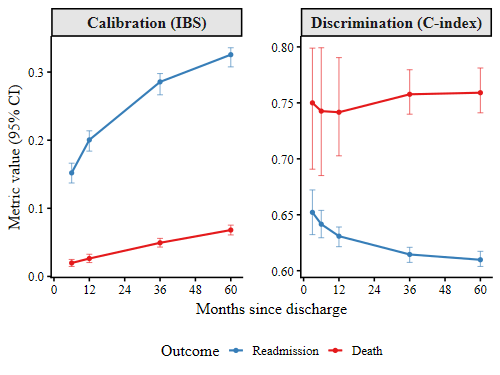

In [23]:
#| label: shap-criteria-dual-cox-plot-python-style-plot-by-time

# Prepare data (ensure proper extraction from results)
time_metrics <- results_shap_xgb_py$summary %>%
  filter(Time != "Global") %>%
  mutate(Time_num = as.numeric(as.character(Time)),
         # Ensure proper ordering of Risk factors
         Risk = factor(Risk, levels = c("Readmission", "Death")))

# Split by metric for separate panels or plots
cindex_data <- time_metrics %>% filter(Metric == "Uno's C-Index")
ibs_data <- time_metrics %>% filter(Metric == "IBS")


p_faceted <- time_metrics %>%
  mutate(Metric = ifelse(Metric == "Uno's C-Index", "Discrimination (C-index)", "Calibration (IBS)")) %>%
  ggplot2::ggplot(ggplot2::aes(x = Time_num, y = mean, color = Risk, fill = Risk)) +
  ggplot2::geom_line(linewidth = 1) +
  ggplot2::geom_point(size = 1.5) +
  ggplot2::geom_errorbar(ggplot2::aes(ymin = q025, ymax = q975), width = 2, alpha = 0.6, size = 0.5) +
  ggplot2::facet_wrap(~Metric, scales = "free_y", ncol = 2) +
  ggplot2::scale_color_manual(values = set1_colors) +
  ggplot2::scale_fill_manual(values = set1_colors) +
  ggplot2::scale_x_continuous(breaks = seq(0, 60, by = 12)) +
  ggplot2::labs(x = "Months since discharge",
       y = "Metric value (95% CI)",
       color = "Outcome",
       fill = "Outcome") +
  ggplot2::theme_classic(base_size = 16, base_family= tnr) +
  ggplot2::theme(legend.position = "bottom",
        strip.background = ggplot2::element_rect(fill = "grey90", color = "black"),
        strip.text = ggplot2::element_text(face = "bold", size = 16),
        panel.spacing = unit(2, "lines"))

p_faceted

In [24]:
#| label: source-cph-ev-boot-oob-mi-corrected

# Override cph_evaluate_boot_oob_mi_corrected with patched version (--no-init-file fix)
source(paste0(getwd(), "/_alt_scripts/cph_evaluate_boot_oob_mi_corrected.R"))
cat("Sourced: cph_evaluate_boot_oob_mi_corrected\n")

Sourced: cph_evaluate_boot_oob_mi_corrected


In [25]:
#| label: shap-criteria2

gc()
# future::plan(future::sequential)
# gc()
# future::plan(
#   future::multisession,
#   workers = 8,
#   maxSizeOfObjects = 10 * 1024^3
# )
# options(future.globals.maxSize = 10 * 1024^3)  # 10 GiB

results_readmit_shap_ibs <- cph_evaluate_boot_oob_mi_corrected(
    formula = formula_shap_readmit_rule,
    imputed_list = py_corrected_datasets, # List of data.frames
    time_col = "readmit_time_from_disch_m", 
    event_col = "readmit_event",
    tau = 99,                # Evaluate up to 60 months
    B = 500,
    cpus = 16,
    verbose = TRUE,
    min_strata_events = 1
)
results_death_shap_ibs <- cph_evaluate_boot_oob_mi_corrected(
    formula = formula_shap_death_rule,
    imputed_list = py_corrected_datasets, # List of data.frames
    time_col = "death_time_from_disch_m", 
    event_col = "death_event",
    tau = 107,                # Evaluate up to 60 months
    B = 500,
    cpus = 16,
    verbose = TRUE,
    min_strata_events = 1
)

aicc_readmit_shap <- compute_mi_aicc(formula_shap_readmit_rule, py_corrected_datasets)#282719.30
cat(sprintf("\nDifference in Mean AIC: %.2f\n", aicc_readmit_shap$mean_aic - aicc_readmit_upd2$mean_aic))
#Difference in Mean AIC: 10170.15
aicc_death_shap <- compute_mi_aicc(formula_shap_death_rule, py_corrected_datasets)
#54321.99
cat(sprintf("\nDifference in Mean AIC: %.2f\n", aicc_death_shap$mean_aic - aicc_death_upd2$mean_aic))
#Difference in Mean AIC: 2825.75
cat("Comparing readmission w/o collinear var and only one strata(plan)\n")
compare_mi_models_d1(formula_readmit_updated,formula_shap_readmit_rule, py_corrected_datasets)

compare_mi_models_d1(formula_death_updated,formula_shap_death_rule, py_corrected_datasets)

Strata: plan_type_strata
Bootstrap OOB + MI: B=500, M=5, tau=99.00, cores=16

Pooled OOB IBS: 0.3478 (95% CI: 0.3357 - 0.3608)
Valid replicates: 500 / 500


There were 50 or more warnings (use warnings() to see the first 50)


Strata: plan_type_strata
Bootstrap OOB + MI: B=500, M=5, tau=107.00, cores=16

Pooled OOB IBS: 0.0893 (95% CI: 0.0828 - 0.0962)
Valid replicates: 500 / 500


There were 32 warnings (use warnings() to see them)



AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  282709.16
Mean AICc: 282709.26
Correction added (Penalty): 0.106716
Parameters (k): 28 | Effective Sample Size (Events): 15247

Difference in Mean AIC: 10160.11

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  54090.66
Mean AICc: 54090.81
Correction added (Penalty): 0.158783
Parameters (k): 15 | Effective Sample Size (Events): 3039

Difference in Mean AIC: 2594.57
Comparing readmission w/o collinear var and only one strata(plan)
Fitting the FULL model on 5 imputations...
Fitting the REDUCED model on 5 imputations...
Executing the Wald Test (D1)...

MODEL COMPARISON RESULT (D1 Statistic)
   test statistic df1      df2 dfcom        p.value        riv
 1 ~~ 2  2.483028  37 10583.74 15183 0.000001569273 0.06765103
Fitting the FULL model on 5 imputations...
Fitting the REDUCED model on 5 imputations...
Executing the Wald Test (D1)...

MODEL COMPARISON RESULT (D1 Statistic)
   test statistic df1      df2 dfcom      p.value        riv
 1 

~36 minutes

In [26]:
#| label: call-functions-for-calibration

source(paste0(getwd(),"/_alt_scripts/calibrate_cscox_aj_grouped_corr.R"))
cat("Sourced: calibrate_cscox_aj_grouped_corr\n")
source(paste0(getwd(),"/_alt_scripts/calibrate_death_km_grouped.R"))
cat("Sourced: calibrate_death_km_grouped\n")

Sourced: calibrate_cscox_aj_grouped_corr
Sourced: calibrate_death_km_grouped


In [27]:
#| label: cal-print

.cal_print <- function(obj, label = "") {
  s <- obj$pooled_summary
  cat(if (nchar(label) > 0) paste0("\n── ", label, " ──\n") else "\n")
  print(
    data.frame(
      t_m   = s$time_months,
      ICI   = round(s$ici_mean, 4),
      ECE   = round(s$ece_mean, 4),
      `E/O` = round(s$eo_mean,  3),
      check.names = FALSE
    ),
    row.names = FALSE
  )
}

# .cal_print(cal_readmit_apparent,  "Readmit — apparent")
# .cal_print(cal_death_quick,        "Death  — CV 1-rep")

In [28]:
#| label: shap-criteria3
.t0 <- proc.time()
gc()

# --- Readmission: competing-risks calibration ---
cal_readmit_shap <- calibrate_cscox_aj_grouped_corr(
    formula_readmit      = formula_shap_readmit_rule,
    formula_death        = formula_shap_death_rule,
    data                 = py_corrected_datasets,
    times                = c(6, 12, 36, 60, 96),
    seed                 = 2125L,
    validation           = "cv",
    n_repeats            = 20L,
    compute_ici          = TRUE,
    ici_times            = 60,
    make_plots           = TRUE,
    parallel_cv          = TRUE,
    parallel_calibration = TRUE,
    future_scheduling    = 2,
    debug_fit            = TRUE
)
.cal_print(cal_readmit_shap)

# --- Death: KM-based calibration ---
cal_death_shap <- calibrate_death_km_grouped(
    formula     = formula_shap_death_rule,
    data        = py_corrected_datasets,
    times       = c(6, 12, 36, 60, 96),
    seed        = 2125L,
    validation  = "cv",
    n_repeats   = 20L,
    parallel_cv = TRUE,
    verbose     = TRUE
)
.cal_print(cal_death_shap)

.elapsed <- proc.time() - .t0
cat(sprintf("\nChunk total: %.1f sec  (%.1f min)\n", .elapsed["elapsed"], .elapsed["elapsed"] / 60))

Using 5 imputed dataset(s).
Validation: cv
Repetitions: 20 | same fold split across imputations within each repetition.
ICI: enabled at horizons 60.
Running CV predictions in parallel across 100 repetition x fold tasks... done
Calibrating 20 repetitions in parallel... done

 t_m    ICI    ECE   E/O
   6     NA 0.0018 0.992
  12     NA 0.0026 0.992
  36     NA 0.0047 0.989
  60 0.0097 0.0066 0.985
  96     NA 0.0060 0.978

calibrate_death_km_grouped: 20 repeats x 5 folds x 5 imputations = 500 fits (100 tasks)
  Pre-flight: running task 1 sequentially...
  Pre-flight OK: risk_mat dim=14105x5
  Pooling repetition 20/20

  Pooled calibration summary:
  time_months    ici_mean        ici_sd     ece_mean  eo_mean
1           6 0.001430433 0.00003548737 0.0006508314 1.007705
2          12 0.002377052 0.00005021242 0.0009050314 1.010035
3          36 0.006568652 0.00011864495 0.0025314138 1.015931
4          60 0.009345833 0.00014763439 0.0027295952 1.029106
5          96 0.012839277 0.0002323

~57 minutes

In [29]:
#| label: shap-criteria-nph

cox.zph(coxph(formula_shap_readmit_rule, data= py_corrected_datasets[[1]]))

                                                         chisq df       p
primary_sub_mod_cocaine_paste                           0.1012  1 0.75038
primary_sub_mod_cocaine_powder                          0.0569  1 0.81154
primary_sub_mod_alcohol                                 0.2409  1 0.62358
primary_sub_mod_others                                  3.6326  1 0.05666
adm_age_rec3                                            5.4793  1 0.01924
porc_pobr                                               0.4622  1 0.49659
sex_rec_woman                                           1.0721  1 0.30047
ethnicity                                               4.3548  1 0.03691
dit_m                                                  21.6215  1 3.3e-06
eva_consumo_logro_intermedio                            1.4606  1 0.22684
eva_consumo_logro_minimo                                6.1404  1 0.01321
ed_attainment_corr_2_completed_high_school_or_less      7.9749  1 0.00474
ed_attainment_corr_3_completed_primary

In [30]:
#| label: shap-criteria-nph2

cox.zph(coxph(formula_shap_death_rule, data= py_corrected_datasets[[1]]))

                                         chisq df      p
adm_age_rec3                            0.0502  1 0.8228
primary_sub_mod_cocaine_paste           0.5378  1 0.4634
primary_sub_mod_cocaine_powder          0.6273  1 0.4284
primary_sub_mod_alcohol                 0.6215  1 0.4305
primary_sub_mod_others                  0.0182  1 0.8926
prim_sub_freq_rec_2_2_6_days_wk         1.0215  1 0.3122
prim_sub_freq_rec_3_daily               1.9841  1 0.1590
occupation_condition_corr24_unemployed  1.5987  1 0.2061
occupation_condition_corr24_inactive    0.0134  1 0.9079
any_phys_dx                            15.1308  1 0.0001
eva_ocupacion_logro_intermedio          0.5028  1 0.4783
eva_ocupacion_logro_minimo              4.3807  1 0.0363
cohabitation_family_of_origin           4.2697  1 0.0388
cohabitation_with_couple_children       4.1335  1 0.0420
cohabitation_others                     2.0114  1 0.1561
GLOBAL                                 34.5286 15 0.0029

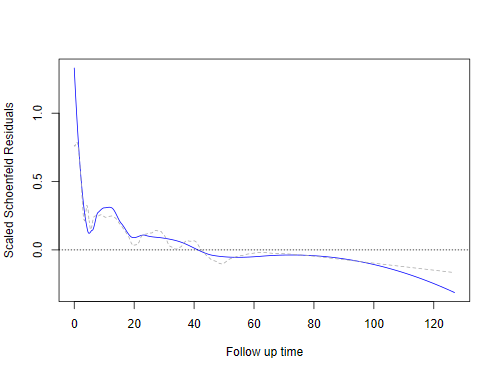

In [31]:
#| label: shap-criteria-nph4-plot-readm-additional-strata-resid-plot

res <- resid(coxph(formula_shap_readmit_rule, data = py_corrected_datasets[[1]]),
                "scaledsch")

time <- as.numeric(rownames(res))
y <- res[, "tr_outcome_adm_discharge_rule_violation_undet"]

z2 <- loess(y ~ time, span = 0.50)
ord <- order(time)

plot(time[ord], fitted(z2)[ord], type = "l", col = "blue",
     xlab = "Follow up time",
     ylab = "Scaled Schoenfeld Residuals")
abline(h = 0, lty = 3)

ss <- supsmu(time, y)
lines(ss$x, ss$y, lty = 2, col = "darkgray")


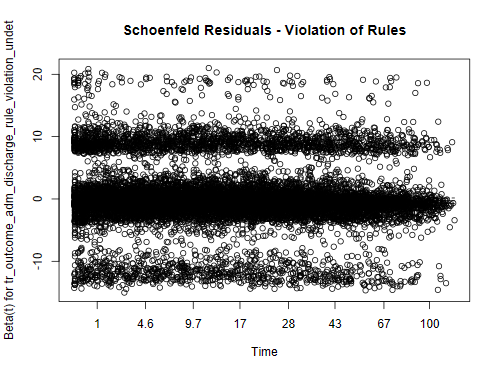

In [32]:
#| label: shap-criteria-nph5-plot-readm-additional-strata-resid-cox-zph

fit <- coxph(formula_shap_readmit_rule, data = py_corrected_datasets[[1]])
zph <- cox.zph(fit, transform = "km")  # or "rank", "identity"

# Plot with confidence bands
plot(zph, var = "tr_outcome_adm_discharge_rule_violation_undet", 
     main = "Schoenfeld Residuals - Violation of Rules")

In [33]:
#| label: shap-criteria-nph6-plot-readm-additional-strata-resid--formula-update

formula_shap_readmit_clean_updated <- update(
  formula_shap_readmit_rule,
  . ~ .
    - tr_outcome_adm_discharge_rule_violation_undet
    + strata(tr_outcome_adm_discharge_rule_violation_undet)
    - evaluacindelprocesoteraputico_logro_minimo
)
formula_shap_readmit_clean_updated


Surv(readmit_time_from_disch_m, readmit_event) ~ primary_sub_mod_cocaine_paste + 
    primary_sub_mod_cocaine_powder + primary_sub_mod_alcohol + 
    primary_sub_mod_others + adm_age_rec3 + porc_pobr + sex_rec_woman + 
    ethnicity + dit_m + eva_consumo_logro_intermedio + eva_consumo_logro_minimo + 
    ed_attainment_corr_2_completed_high_school_or_less + ed_attainment_corr_3_completed_primary_school_or_less + 
    occupation_condition_corr24_unemployed + occupation_condition_corr24_inactive + 
    dg_psiq_cie_10_dg + sub_dep_icd10_status_drug_dependence + 
    polysubstance_strict + eva_sm_logro_intermedio + eva_sm_logro_minimo + 
    evaluacindelprocesoteraputico_logro_intermedio + tr_outcome_referral + 
    tr_outcome_dropout + tr_outcome_adm_discharge_adm_reasons + 
    prim_sub_freq_rec_2_2_6_days_wk + prim_sub_freq_rec_3_daily + 
    strata(plan_type_strata) + strata(tr_outcome_adm_discharge_rule_violation_undet)
<environment: 0x0000020d20a8fcf0>

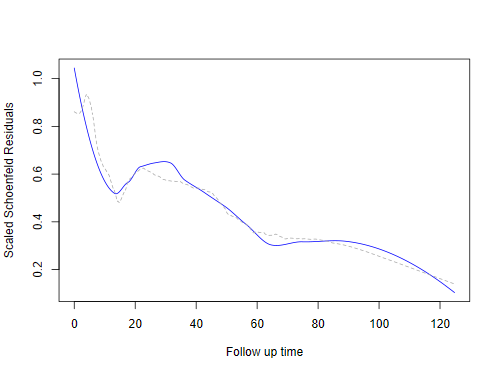

In [34]:
#| label: shap-criteria-nph7-plot-readm-additional-strata-resid-plot

res <- resid(coxph(formula_shap_death_rule , data = py_corrected_datasets[[1]]), "scaledsch")

time <- as.numeric(rownames(res))
y <- res[, "any_phys_dxTRUE"]

z2 <- loess(y ~ time, span = 0.50)
ord <- order(time)

plot(time[ord], fitted(z2)[ord], type = "l", col = "blue",
     xlab = "Follow up time",
     ylab = "Scaled Schoenfeld Residuals")
abline(h = 0, lty = 3)

ss <- supsmu(time, y)
lines(ss$x, ss$y, lty = 2, col = "darkgray")


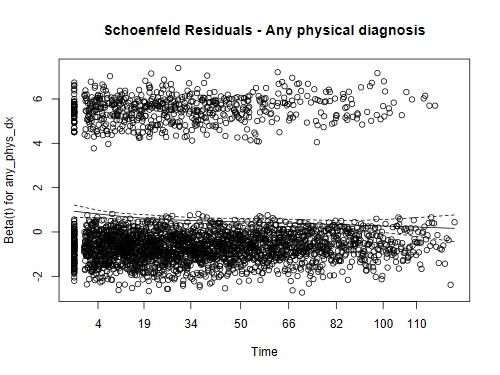

In [35]:
#| label: shap-criteria-nph8-plot-death-additional-strata-resid-cox-zph

fit <- coxph(formula_shap_death_rule, data = py_corrected_datasets[[1]])
zph <- cox.zph(fit, transform = "km")  # or "rank", "identity"

# Plot with confidence bands
plot(zph, var = "any_phys_dx", 
     main = "Schoenfeld Residuals - Any physical diagnosis")

In [36]:
#| label: shap-criteria-nph9-death-additional-strata-resid-formula-update

formula_shap_death_rule2 <- update(
  formula_shap_death_rule,
  . ~ . - any_phys_dx + strata(any_phys_dx)
)
formula_shap_death_rule2

Surv(death_time_from_disch_m, death_event) ~ adm_age_rec3 + primary_sub_mod_cocaine_paste + 
    primary_sub_mod_cocaine_powder + primary_sub_mod_alcohol + 
    primary_sub_mod_others + prim_sub_freq_rec_2_2_6_days_wk + 
    prim_sub_freq_rec_3_daily + occupation_condition_corr24_unemployed + 
    occupation_condition_corr24_inactive + eva_ocupacion_logro_intermedio + 
    eva_ocupacion_logro_minimo + cohabitation_family_of_origin + 
    cohabitation_with_couple_children + cohabitation_others + 
    strata(plan_type_strata) + strata(any_phys_dx)
<environment: 0x0000020d29dc9760>

### Additional strata to readmission

In [37]:
#| label: shap-criteria-additional-strata2

gc()

results_readmit_shap2 <- evaluate_mi_cv_safe_strata(
  formula = as.formula(
  gsub(
    "strat\\(",
    "strata(",
    paste(deparse(formula_shap_readmit_clean_updated), collapse = " ")
  )
), 
  imputed_list = py_corrected_datasets, 
  time_col = "readmit_time_from_disch_m", 
  event_col = "readmit_event",
  k = 5,
  n_repeats = 20, 
  cpus = 8
)

Starting Evaluation: 5 Imputations x 5 Folds x 20 Repeats = 500 Total Models
------------------------------------------------------------
Global evaluation tau: 99.10 months | C-tau: 94.14 months
Booting up 8 CPU cores using future backend...

FINAL POOLED RESULTS (Cross-Validated + Multiply Imputed)
Global Evaluation Time (tau): 99.10 months
Pooled Uno's C-Index: 0.6065 (repeat-quantile interval 0.6062-0.6068)
Pooled UnoC (survAUC::UnoC): 0.6645 (repeat-quantile interval 0.6375-0.6970)
Pooled IBS: 0.1601 (repeat-quantile interval 0.1601-0.1601)
Pooled IBS (IPCW-train): 0.3479 (repeat-quantile interval 0.3477-0.3481)
RMST-based Uno C-index by horizon:
  t=12 m: C=0.6308 (repeat-quantile interval 0.6306-0.6312, valid repeats=20)
  t=36 m: C=0.6145 (repeat-quantile interval 0.6143-0.6149, valid repeats=20)
  t=60 m: C=0.6097 (repeat-quantile interval 0.6095-0.6100, valid repeats=20)

Total runtime: 504.61 sec (8.41 min)


Warning messages:
1: package 'prodlim' was built under R version 4.4.3 
2: package 'prodlim' was built under R version 4.4.3 
3: package 'prodlim' was built under R version 4.4.3 
4: package 'prodlim' was built under R version 4.4.3 
5: package 'prodlim' was built under R version 4.4.3 
6: package 'prodlim' was built under R version 4.4.3 
7: package 'prodlim' was built under R version 4.4.3 
8: package 'prodlim' was built under R version 4.4.3 


In [38]:
#| label: shap-criteria-additional-strata22

results_readmit_shap_ibs <- cph_evaluate_boot_oob_mi_corrected(
  formula = as.formula(gsub("strat\\(", "strata(", deparse(formula_shap_readmit_clean_updated))),
  imputed_list = py_corrected_datasets, # List of data.frames
  time_col = "readmit_time_from_disch_m", 
  event_col = "readmit_event",
  tau = 99,                # Evaluate up to 60 months
  B = 500,
  cpus = cpus,
  verbose = TRUE,
  min_strata_events = 1
)

aicc_readmit_shap <- compute_mi_aicc(as.formula(gsub("strat\\(", "strata(", deparse(formula_shap_readmit_clean_updated))), py_corrected_datasets)
cat(sprintf("\nDifference in Mean AIC: %.2f\n", aicc_readmit_shap$mean_aic - aicc_readmit_upd2$mean_aic))

Strata: plan_type_strata, tr_outcome_adm_discharge_rule_violation_undet
Bootstrap OOB + MI: B=500, M=5, tau=99.00, cores=16

Pooled OOB IBS: 0.3477 (95% CI: 0.3355 - 0.3606)
Valid replicates: 500 / 500


There were 36 warnings (use warnings() to see them)



AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272575.93
Mean AICc: 272576.02
Correction added (Penalty): 0.092247
Parameters (k): 26 | Effective Sample Size (Events): 15247


Warning message:
In formula.character(object, env = baseenv()) :
  Using formula(x) is deprecated when x is a character vector of length > 1.
  Consider formula(paste(x, collapse = " ")) instead.



Difference in Mean AIC: 26.87


~ 17 minutes

In [39]:
compare_mi_models_d1(formula_shap_readmit_clean_updated,formula_shap_readmit_clean, py_corrected_datasets)

Fitting the FULL model on 5 imputations...
Fitting the REDUCED model on 5 imputations...
Executing the Wald Test (D1)...

MODEL COMPARISON RESULT (D1 Statistic)
   test statistic df1   df2 dfcom      p.value           riv
 1 ~~ 2    4.5271   5 15219 15221 0.0003987985 0.00001679698


In [40]:
#| label: shap-criteria-additional-strata23

.t0 <- proc.time()

cal_readmit_shap2 <- calibrate_cscox_aj_grouped_corr(
    formula_readmit      = as.formula(gsub("strat\\(", "strata(", deparse(formula_shap_readmit_clean_updated))),
    formula_death        = formula_shap_death_rule,
    data                 = py_corrected_datasets,
    times                = c(6, 12, 36, 60, 96),
    seed                 = 2125L,
    validation           = "cv",
    n_repeats            = 20L,
    compute_ici          = TRUE,
    ici_times            = 60,
    make_plots           = TRUE,
    parallel_cv          = TRUE,
    parallel_calibration = TRUE,
    future_scheduling    = 2,
    debug_fit            = TRUE
)
.cal_print(cal_readmit_shap2)

.elapsed <- proc.time() - .t0
cat(sprintf("\nChunk total: %.1f sec  (%.1f min)\n",
            .elapsed["elapsed"], .elapsed["elapsed"] / 60))

Using 5 imputed dataset(s).
Validation: cv
Repetitions: 20 | same fold split across imputations within each repetition.
ICI: enabled at horizons 60.
Running CV predictions in parallel across 100 repetition x fold tasks... done
Calibrating 20 repetitions in parallel... done


Warning message:
In formula.character(object, env = baseenv()) :
  Using formula(x) is deprecated when x is a character vector of length > 1.
  Consider formula(paste(x, collapse = " ")) instead.



 t_m    ICI    ECE   E/O
   6     NA 0.0024 0.991
  12     NA 0.0029 0.991
  36     NA 0.0050 0.989
  60 0.0095 0.0065 0.986
  96     NA 0.0062 0.979

Chunk total: 1688.8 sec  (28.1 min)


~35  minutes

In [41]:
#| label: shap-criteria2-additional-strata-run-ev-mi-cv-python-style

results_shap_add_strata_xgb_py <- evaluate_dual_cox_python_style(
  formula_readmit = as.formula(gsub("strat\\(", "strata(", deparse(formula_shap_readmit_clean_updated))),  # Original formula with months variable,
  formula_death = formula_shap_death_rule,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(3, 6, 12, 36, 60)
)

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


Warning message:
In formula.character(object, env = baseenv()) :
  Using formula(x) is deprecated when x is a character vector of length > 1.
  Consider formula(paste(x, collapse = " ")) instead.


In [42]:
#| label: shap-criteria2-additional-strata-summ-python-style

results_shap_add_strata_xgb_py$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, updated formula of readmission with additional strata")



Table: Global C-index and IBS summary, updated formula of readmission with additional strata

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.1519894| 0.0090352| 0.1371104| 0.1661871| 25|
|Readmission |IBS           |12     | 0.2004196| 0.0092656| 0.1839001| 0.2137479| 25|
|Readmission |IBS           |36     | 0.2855828| 0.0086868| 0.2666649| 0.2978708| 25|
|Readmission |IBS           |60     | 0.3255283| 0.0081110| 0.3076652| 0.3357784| 25|
|Readmission |IBS           |Global | 0.3255283| 0.0081110| 0.3076652| 0.3357784| 25|
|Readmission |Uno's C-Index |6      | 0.6416147| 0.0083088| 0.6294710| 0.6540764| 25|
|Readmission |Uno's C-Index |12     | 0.6309038| 0.0054332| 0.6215066| 0.6391181| 25|
|Readmission |Uno's C-Index |36     | 0.6145790| 0.0040165| 0.6074619| 0.6209743| 25|
|Readmission |Uno's C-Index |60     | 0.6098

### Additional strata to death

In [43]:
#| label: shap-criteria-additional-strata22-death

results_death_shap_ibs_strata <- cph_evaluate_boot_oob_mi_corrected(
    formula = formula_shap_death_rule2,
    imputed_list = py_corrected_datasets, # List of data.frames
    time_col = "death_time_from_disch_m", 
    event_col = "death_event",
    tau = 107,                # Evaluate up to 60 months
    B = 500,
    cpus = 16,
    verbose = TRUE,
    min_strata_events = 1
)

aicc_death_shap_strata <- compute_mi_aicc(as.formula(gsub("strat\\(", "strata(", deparse(formula_shap_death_rule2))), py_corrected_datasets)
aicc_death_shap_strata

Strata: plan_type_strata, any_phys_dx
Bootstrap OOB + MI: B=500, M=5, tau=107.00, cores=16

Pooled OOB IBS: 0.0893 (95% CI: 0.0828 - 0.0963)
Valid replicates: 500 / 500


There were 32 warnings (use warnings() to see them)



AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51078.02
Mean AICc: 51078.15
Correction added (Penalty): 0.138889
Parameters (k): 14 | Effective Sample Size (Events): 3039


Warning message:
In formula.character(object, env = baseenv()) :
  Using formula(x) is deprecated when x is a character vector of length > 1.
  Consider formula(paste(x, collapse = " ")) instead.


$mean_aicc
[1] 51078.15

$full_results
       aic correction     aicc  k n_events
1 51073.81  0.1388889 51073.95 14     3039
2 51080.71  0.1388889 51080.85 14     3039
3 51080.12  0.1388889 51080.25 14     3039
4 51077.06  0.1388889 51077.20 14     3039
5 51078.38  0.1388889 51078.52 14     3039


~ 18 minutes

In [44]:
#| label: shap-criteria-additional-strata23-death

.t0 <- proc.time()
gc()
# --- Death: KM-based calibration ---
cal_death_shap_strat <- calibrate_death_km_grouped(
    formula     = formula_shap_death_rule2,
    data        = py_corrected_datasets,
    times       = c(6, 12, 36, 60, 96),
    seed        = 2125L,
    validation  = "cv",
    n_repeats   = 20L,
    parallel_cv = TRUE,
    verbose     = TRUE
)
.cal_print(cal_death_shap_strat)

.elapsed <- proc.time() - .t0
cat(sprintf("\nChunk total: %.1f sec  (%.1f min)\n", .elapsed["elapsed"], .elapsed["elapsed"] / 60))


calibrate_death_km_grouped: 20 repeats x 5 folds x 5 imputations = 500 fits (100 tasks)
  Pre-flight: running task 1 sequentially...
  Pre-flight OK: risk_mat dim=14105x5
  Pooling repetition 20/20

  Pooled calibration summary:
  time_months    ici_mean        ici_sd     ece_mean  eo_mean
1           6 0.001743025 0.00004640676 0.0007349031 1.007274
2          12 0.002662979 0.00006240918 0.0009948436 1.009225
3          36 0.006666098 0.00009469888 0.0024230131 1.015131
4          60 0.009356557 0.00013499035 0.0026229806 1.027704
5          96 0.012509127 0.00023328715 0.0033949117 1.068485

 t_m    ICI    ECE   E/O
   6 0.0017 0.0007 1.007
  12 0.0027 0.0010 1.009
  36 0.0067 0.0024 1.015
  60 0.0094 0.0026 1.028
  96 0.0125 0.0034 1.068

Chunk total: 1660.1 sec  (27.7 min)


~ 22 minutes

In [45]:
#| label: shap-criteria2-additional-strata-run-ev-mi-cv-python-style-for-both

results_shap_add_strata_xgb_py2 <- evaluate_dual_cox_python_style(
  formula_readmit = as.formula(gsub("strat\\(", "strata(", deparse(formula_shap_readmit_clean_updated))),  # Original formula with months variable,
  formula_death = formula_shap_death_rule2,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(3, 6, 9, 12, 24, 36, 48, 60, 72, 84, 96, 108)
)

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


Warning message:
In formula.character(object, env = baseenv()) :
  Using formula(x) is deprecated when x is a character vector of length > 1.
  Consider formula(paste(x, collapse = " ")) instead.


In [46]:
#| label: shap-criteria2-additional-strata-summ-python-style-for-both

results_shap_add_strata_xgb_py2$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, updated formula of readmission with additional strata (both outcomes)")



Table: Global C-index and IBS summary, updated formula of readmission with additional strata (both outcomes)

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.1519894| 0.0090352| 0.1371104| 0.1661871| 25|
|Readmission |IBS           |12     | 0.2026001| 0.0094978| 0.1854457| 0.2158393| 25|
|Readmission |IBS           |36     | 0.2939660| 0.0089106| 0.2745717| 0.3064834| 25|
|Readmission |IBS           |60     | 0.3310933| 0.0082726| 0.3134331| 0.3415470| 25|
|Readmission |IBS           |Global | 0.3582713| 0.0078195| 0.3427319| 0.3687689| 25|
|Readmission |Uno's C-Index |6      | 0.6416147| 0.0083088| 0.6294710| 0.6540764| 25|
|Readmission |Uno's C-Index |12     | 0.6309038| 0.0054332| 0.6215066| 0.6391181| 25|
|Readmission |Uno's C-Index |36     | 0.6145790| 0.0040165| 0.6074619| 0.6209743| 25|
|Readmission |Uno's C-Index 

In [47]:
#| label: shap-criteria2-additional-strata-run-ev-mi-cv-python-style-for-both2
res_rule2 <- evaluate_dual_cox_python_style(
  formula_readmit = as.formula(gsub("strat\\(","strata(", deparse(formula_shap_readmit_clean_updated))),
  formula_death   = formula_shap_death_rule2,     # <- el de strata, no el viejo
  imputed_list = py_corrected_datasets,
  k_folds = 5, eval_times = c(3,6,12,36,60))    # MISMA grilla que usaste para rule


Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


Warning message:
In formula.character(object, env = baseenv()) :
  Using formula(x) is deprecated when x is a character vector of length > 1.
  Consider formula(paste(x, collapse = " ")) instead.


In [48]:
#| label: shap-criteria2-additional-strata-summ-python-style-for-both2

res_rule2$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, updated formula of readmission with additional strata (both outcomes)")



Table: Global C-index and IBS summary, updated formula of readmission with additional strata (both outcomes)

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.1519894| 0.0090352| 0.1371104| 0.1661871| 25|
|Readmission |IBS           |12     | 0.2004196| 0.0092656| 0.1839001| 0.2137479| 25|
|Readmission |IBS           |36     | 0.2855828| 0.0086868| 0.2666649| 0.2978708| 25|
|Readmission |IBS           |60     | 0.3255283| 0.0081110| 0.3076652| 0.3357784| 25|
|Readmission |IBS           |Global | 0.3255283| 0.0081110| 0.3076652| 0.3357784| 25|
|Readmission |Uno's C-Index |6      | 0.6416147| 0.0083088| 0.6294710| 0.6540764| 25|
|Readmission |Uno's C-Index |12     | 0.6309038| 0.0054332| 0.6215066| 0.6391181| 25|
|Readmission |Uno's C-Index |36     | 0.6145790| 0.0040165| 0.6074619| 0.6209743| 25|
|Readmission |Uno's C-Index 


With stratification, individuals in different strata have different baseline hazards, and therefore different predicted survival probabilities. This creates some discrimination purely from the stratum membership.

For the Wald test (𝐷1) to be valid, the ‘Reduced’ model must be a perfect subset of the ‘Full’ model. You cannot change the underlying structure (strata).

In [49]:
cox.zph(coxph(formula_shap_death_rule2, data = py_corrected_datasets[[1]]))


                                        chisq df     p
adm_age_rec3                            0.213  1 0.645
primary_sub_mod_cocaine_paste           0.203  1 0.652
primary_sub_mod_cocaine_powder          0.970  1 0.325
primary_sub_mod_alcohol                 0.215  1 0.643
primary_sub_mod_others                  0.188  1 0.665
prim_sub_freq_rec_2_2_6_days_wk         0.456  1 0.499
prim_sub_freq_rec_3_daily               1.076  1 0.300
occupation_condition_corr24_unemployed  1.698  1 0.193
occupation_condition_corr24_inactive    0.308  1 0.579
eva_ocupacion_logro_intermedio          0.509  1 0.476
eva_ocupacion_logro_minimo              4.429  1 0.035
cohabitation_family_of_origin           4.790  1 0.029
cohabitation_with_couple_children       3.971  1 0.046
cohabitation_others                     1.846  1 0.174
GLOBAL                                 19.073 14 0.162

## Interactions

The hierarchical specification of interaction models was informed by the strong-hierarchy principle discussed by Lim and Hastie (2015), although interaction discovery and prioritization in the present study were based on SHAP-derived XGBoost interaction screening rather than hierarchical group-lasso estimation.

For interaction seleciton and specification source: Michael Lim & Trevor Hastie (2015) Learning Interactions via Hierarchical Group-Lasso Regularization, Journal of Computational and Graphical Statistics, 24:3, 627-654, DOI: 10.1080/10618600.2014.938812

In [50]:
#| label: shap-criteria-int-final

# 1. Load data
global_core <- read_csv(
  find_latest_file(
    file.path(project_root, "cons", "_out"),
    "xgb11_dual_interactions_global_top_enriched"),
  show_col_types = FALSE
)

time_dep_u <- read_csv(
  find_latest_file(
    file.path(project_root, "cons", "_out"), 
    "xgb11_dual_interactions_time_dependent"),
  show_col_types = FALSE
)

# 2. Family classifier (refined for eva_* subtypes)
get_family <- function(x) {
  dplyr::case_when(
    stringr::str_detect(x, "^plan_type_corr_")       ~ "plan_type",
    stringr::str_detect(x, "^adm_motive_")           ~ "adm_motive",
    stringr::str_detect(x, "^tr_outcome_")           ~ "tr_outcome",
    stringr::str_detect(x, "^primary_sub_mod_")      ~ "primary_sub_mod",
    stringr::str_detect(x, "^first_sub_used_")       ~ "first_sub_used",
    stringr::str_detect(x, "^marital_status_")       ~ "marital_status",
    stringr::str_detect(x, "^occupation_condition_") ~ "occupation_condition",
    stringr::str_detect(x, "^cohabitation_")         ~ "cohabitation",
    stringr::str_detect(x, "^tipo_de_vivienda_")     ~ "tipo_vivienda",
    stringr::str_detect(x, "^dx_")                   ~ "dx_psiq",
    stringr::str_detect(x, "^dg_psiq_")              ~ "dg_psiq",
    stringr::str_detect(x, "^eva_consumo")           ~ "eva_consumo",
    stringr::str_detect(x, "^eva_sm")                ~ "eva_sm",
    stringr::str_detect(x, "^eva_fam")               ~ "eva_fam",
    stringr::str_detect(x, "^eva_ocupacion")         ~ "eva_ocupacion",
    stringr::str_detect(x, "^eva_relinterp")         ~ "eva_relinterp",
    stringr::str_detect(x, "^eva_transgnorma")       ~ "eva_transgnorma",
    stringr::str_detect(x, "^sub_dep_icd10_")        ~ "sub_dep",
    stringr::str_detect(x, "^prim_sub_freq")         ~ "prim_sub_freq",
    stringr::str_detect(x, "^ed_attainment")         ~ "education",
    stringr::str_detect(x, "^tenure_status")         ~ "tenure",
    stringr::str_detect(x, "^sex_rec_")              ~ "sex",
    stringr::str_detect(x, "^adm_age")               ~ "age",
    stringr::str_detect(x, "^dit_m$")                ~ "dit_m",
    stringr::str_detect(x, "^ethnicity$")            ~ "ethnicity",
    stringr::str_detect(x, "^polysubstance")         ~ "polysubstance",
    stringr::str_detect(x, "^any_phys_dx$")          ~ "any_phys_dx",
    stringr::str_detect(x, "^evaluacindelproceso")   ~ "evaluacindelproceso",
    TRUE                                             ~ x
  )
}

# 3. Stability join (using your actual column names)
stable_core <- global_core %>%
  dplyr::left_join(
    time_dep_u %>%
      dplyr::select(
        outcome, main_feature, interactor,
        rank_range, abs_corr_delta, direction_flip_flag, time_dependent_flag
      ),
    by = c("outcome", "main_feature", "interactor")
  ) %>%
  dplyr::filter(
    #is.na(direction_flip_flag) | direction_flip_flag == FALSE,
    is.na(rank_range) | rank_range <= 8,
    is.na(abs_corr_delta) | abs_corr_delta <= 0.05,
    #is.na(time_dependent_flag) | time_dependent_flag == FALSE
  )

# 4. Effect-Size & Stability Rule + family exclusions
cox_discriminative_interactions <- stable_core %>%
  dplyr::mutate(
    fam_main = get_family(main_feature),
    fam_int  = get_family(interactor),
    score    = abs_corr * abs(smd_binarized)
  ) %>%
  dplyr::filter(
    abs_corr >= 0.10,
    !is.na(smd_binarized) & abs(smd_binarized) >= 0.15,
    fam_main != "plan_type",
    fam_int  != "plan_type",
    fam_main != fam_int
  ) %>%
  dplyr::select(
    outcome, main_feature, interactor, 
    abs_corr, smd_binarized, direction_q4_q1
  ) %>%
  dplyr::arrange(outcome, desc(abs_corr))

# 5. Results
cat("Candidates after family + stability filtering:", nrow(cox_discriminative_interactions), "\n")
knitr::kable(
  cox_discriminative_interactions,
  "markdown",
  caption = "Highly discriminative interactions for Cox models based on Effect-Size & Stability Rule"
)

Candidates after family + stability filtering: 13 




Table: Highly discriminative interactions for Cox models based on Effect-Size & Stability Rule

|outcome     |main_feature                           |interactor                    |  abs_corr| smd_binarized|direction_q4_q1 |
|:-----------|:--------------------------------------|:-----------------------------|---------:|-------------:|:---------------|
|Death       |any_phys_dx                            |primary_sub_mod_alcohol       | 0.1516792|    -0.3239456|Negative        |
|Death       |primary_sub_mod_alcohol                |adm_age_rec3                  | 0.1455185|    -0.2719126|Negative        |
|Death       |cohabitation_with_couple_children      |adm_age_rec3                  | 0.1273963|     0.2131233|Positive        |
|Death       |first_sub_used_alcohol                 |primary_sub_mod_alcohol       | 0.1188216|    -0.2526242|Negative        |
|Death       |primary_sub_mod_cocaine_paste          |polysubstance_strict          | 0.1151229|    -0.2614787|Negative        |

For Cox implementation, SHAP-selected interactions were specified according to the encoding granularity of the screened features. Interactions involving aggregate or ordinal predictors in the XGBoost table, such as eva_consumo or eva_sm, were expanded to the corresponding Cox indicator family. In contrast, interactions involving one-hot encoded predictors, such as first_sub_used_alcohol, primary_sub_mod_others, or tr_outcome_referral, were retained only at the selected dummy level. This rule preserved hierarchy while avoiding the addition of unscreened degrees of freedom.

In [ ]:
#| label: shap-criteria-int2-formula

# Interactions come from the Effect-Size & Stability Rule table, with strong
# hierarchy (Lim & Hastie, 2015). Variables involved in stratification are NOT
# eligible for interactions (same a-priori rule applied to plan_type); tr_outcome
# is used in strata, so the rule-table's eva_consumo:tr_outcome_referral is dropped.

# ---------------------------------------------------------------------------
# READMISSION  (2 interactions retained)
#   sex_rec_woman:primary_sub_mod_others  -- ambos efectos principales ya en la base.
#   eva_consumo:tr_outcome_referral  -- eva_consumo expandida a sus niveles;
#     tr_outcome_referral entra como efecto principal y en la interaccion.
#   (solo tr_outcome rule_violation esta en estrato; referral permanece como covariable.)
# ---------------------------------------------------------------------------

#corrected 2026-06-17: interaction
# complete family version (excluding the stratified level)
formula_shap_readmit_interact <- update(
  formula_shap_readmit_clean_updated,
  . ~ .
    + eva_consumo_logro_intermedio:tr_outcome_referral   # eva_consumo expandida a sus dos niveles; tr_outcome solo en el nivel referral.
    + eva_consumo_logro_minimo:tr_outcome_referral
    + sex_rec_woman:primary_sub_mod_others               # solo el nivel marcado
)

# ---------------------------------------------------------------------------
# DEATH (9 interactions retained de 11; las 2 de any_phys_dx se excluyen
#   porque any_phys_dx esta en estrato por desviacion de PH)

#   Add main effects needed for hierarchy (not in the rule base):
#   first_sub_used_alcohol, polysubstance_strict, dit_m,
#   evaluacindelprocesoteraputico_logro_intermedio, eva_sm_logro_*.
#   Conventions: primary_sub_mod & first_sub_used interactions use ONLY alcohol;
#   evaluacin _minimo omitted (collinear).
# ---------------------------------------------------------------------------
formula_shap_death_interact <- stats::update(
  formula_shap_death_rule2,
  . ~ . +
    first_sub_used_alcohol +
    polysubstance_strict +
    dit_m +
    evaluacindelprocesoteraputico_logro_intermedio +
    eva_sm_logro_intermedio + eva_sm_logro_minimo +
    adm_age_rec3:primary_sub_mod_alcohol +                      # 2
    adm_age_rec3:cohabitation_with_couple_children +            # 3
    first_sub_used_alcohol:primary_sub_mod_alcohol +            # 4
    primary_sub_mod_cocaine_paste:polysubstance_strict +       # 5
    dit_m:evaluacindelprocesoteraputico_logro_intermedio +     # 6
    adm_age_rec3:first_sub_used_alcohol +                       # 7
    polysubstance_strict:first_sub_used_alcohol +              # 8
    adm_age_rec3:occupation_condition_corr24_unemployed +      # 9
    dit_m:(eva_sm_logro_intermedio + eva_sm_logro_minimo)    # 10
)

# Normalize strat( -> strata( and collapse to a single line
formula_shap_readmit_interact <- as.formula(
  gsub("strat\\(", "strata(",
       paste(deparse(formula_shap_readmit_interact), collapse = " ")))
formula_shap_death_interact <- as.formula(
  gsub("strat\\(", "strata(",
       paste(deparse(formula_shap_death_interact), collapse = " ")))

In [89]:
formula_shap_readmit_interact

Surv(readmit_time_from_disch_m, readmit_event) ~ primary_sub_mod_cocaine_paste + 
    primary_sub_mod_cocaine_powder + primary_sub_mod_alcohol + 
    primary_sub_mod_others + adm_age_rec3 + porc_pobr + sex_rec_woman + 
    ethnicity + dit_m + eva_consumo_logro_intermedio + eva_consumo_logro_minimo + 
    ed_attainment_corr_2_completed_high_school_or_less + ed_attainment_corr_3_completed_primary_school_or_less + 
    occupation_condition_corr24_unemployed + occupation_condition_corr24_inactive + 
    dg_psiq_cie_10_dg + sub_dep_icd10_status_drug_dependence + 
    polysubstance_strict + eva_sm_logro_intermedio + eva_sm_logro_minimo + 
    evaluacindelprocesoteraputico_logro_intermedio + tr_outcome_referral + 
    tr_outcome_dropout + tr_outcome_adm_discharge_adm_reasons + 
    prim_sub_freq_rec_2_2_6_days_wk + prim_sub_freq_rec_3_daily + 
    strata(plan_type_strata) + strata(tr_outcome_adm_discharge_rule_violation_undet) + 
    eva_consumo_logro_intermedio:tr_outcome_referral + eva_cons

In [90]:
formula_shap_death_interact

Surv(death_time_from_disch_m, death_event) ~ adm_age_rec3 + primary_sub_mod_cocaine_paste + 
    primary_sub_mod_cocaine_powder + primary_sub_mod_alcohol + 
    primary_sub_mod_others + prim_sub_freq_rec_2_2_6_days_wk + 
    prim_sub_freq_rec_3_daily + occupation_condition_corr24_unemployed + 
    occupation_condition_corr24_inactive + eva_ocupacion_logro_intermedio + 
    eva_ocupacion_logro_minimo + cohabitation_family_of_origin + 
    cohabitation_with_couple_children + cohabitation_others + 
    strata(plan_type_strata) + strata(any_phys_dx) + first_sub_used_alcohol + 
    polysubstance_strict + dit_m + evaluacindelprocesoteraputico_logro_intermedio + 
    eva_sm_logro_intermedio + eva_sm_logro_minimo + adm_age_rec3:primary_sub_mod_alcohol + 
    adm_age_rec3:cohabitation_with_couple_children + primary_sub_mod_alcohol:first_sub_used_alcohol + 
    primary_sub_mod_cocaine_paste:polysubstance_strict + dit_m:evaluacindelprocesoteraputico_logro_intermedio + 
    adm_age_rec3:first_sub_

In [91]:
#| label: shap-criteria-int3-cox-zph-interactions

# Fit Cox model with the interaction formula
cox_shap_death_interact <- coxph(
  formula = formula_shap_death_interact,
  data = py_corrected_datasets[[1]],   # replace with your actual death dataset
  ties = "efron",
  x = TRUE
)

# Proportional hazards test
zph_shap_death_interact <- cox.zph(
  cox_shap_death_interact,
  transform = "km",
  terms = TRUE,
  global = TRUE
)

# Optional: table format
zph_death_interact_table <- as.data.frame(zph_shap_death_interact$table)
zph_death_interact_table$term <- rownames(zph_death_interact_table)

zph_death_interact_table <- zph_death_interact_table[, c("term", "chisq", "df", "p")]
zph_death_interact_table |> 
  dplyr::arrange(desc(chisq)) |>
  knitr::kable("markdown", caption = "Proportional Hazards Test for Cox Model with Interactions - Death Outcome")




Table: Proportional Hazards Test for Cox Model with Interactions - Death Outcome

|                                                     |term                                                 |      chisq| df|         p|
|:----------------------------------------------------|:----------------------------------------------------|----------:|--:|---------:|
|GLOBAL                                               |GLOBAL                                               | 36.1523170| 30| 0.2031327|
|eva_sm_logro_minimo                                  |eva_sm_logro_minimo                                  |  6.8679825|  1| 0.0087754|
|dit_m:eva_sm_logro_minimo                            |dit_m:eva_sm_logro_minimo                            |  4.7393677|  1| 0.0294799|
|cohabitation_family_of_origin                        |cohabitation_family_of_origin                        |  4.5433822|  1| 0.0330462|
|eva_ocupacion_logro_minimo                           |eva_ocupacion_logro_minimo             

In [92]:
#| label: shap-criteria-int2-ev-mi-cv

results_readmit_int_shap <- evaluate_mi_cv_safe_strata(
    formula = formula_shap_readmit_interact, 
    imputed_list = py_corrected_datasets, 
    time_col = "readmit_time_from_disch_m", 
    event_col = "readmit_event",
    k = 5,
    n_repeats = 20
)
results_death_int_shap <- evaluate_mi_cv_safe_strata(
    formula = formula_shap_death_interact, 
    imputed_list = py_corrected_datasets, 
    time_col = "death_time_from_disch_m", 
    event_col = "death_event",
    k = 5,
    n_repeats = 20
)

Starting Evaluation: 5 Imputations x 5 Folds x 20 Repeats = 500 Total Models
------------------------------------------------------------
Global evaluation tau: 99.10 months | C-tau: 94.14 months
Booting up 16 CPU cores using future backend...

FINAL POOLED RESULTS (Cross-Validated + Multiply Imputed)
Global Evaluation Time (tau): 99.10 months
Pooled Uno's C-Index: 0.6068 (repeat-quantile interval 0.6066-0.6070)
Pooled UnoC (survAUC::UnoC): 0.6745 (repeat-quantile interval 0.6426-0.7051)
Pooled IBS: 0.1601 (repeat-quantile interval 0.1601-0.1601)
Pooled IBS (IPCW-train): 0.3477 (repeat-quantile interval 0.3475-0.3479)
RMST-based Uno C-index by horizon:
  t=12 m: C=0.6314 (repeat-quantile interval 0.6311-0.6317, valid repeats=20)
  t=36 m: C=0.6148 (repeat-quantile interval 0.6145-0.6151, valid repeats=20)
  t=60 m: C=0.6100 (repeat-quantile interval 0.6098-0.6103, valid repeats=20)

Total runtime: 302.78 sec (5.05 min)


There were 16 warnings (use warnings() to see them)


Starting Evaluation: 5 Imputations x 5 Folds x 20 Repeats = 500 Total Models
------------------------------------------------------------
Global evaluation tau: 107.94 months | C-tau: 102.54 months
Booting up 16 CPU cores using future backend...

FINAL POOLED RESULTS (Cross-Validated + Multiply Imputed)
Global Evaluation Time (tau): 107.94 months
Pooled Uno's C-Index: 0.7443 (repeat-quantile interval 0.7437-0.7449)
Pooled UnoC (survAUC::UnoC): 0.7951 (repeat-quantile interval 0.6766-0.8783)
Pooled IBS: 0.0351 (repeat-quantile interval 0.0351-0.0351)
Pooled IBS (IPCW-train): 0.0889 (repeat-quantile interval 0.0887-0.0890)
RMST-based Uno C-index by horizon:
  t=12 m: C=0.7445 (repeat-quantile interval 0.7431-0.7461, valid repeats=20)
  t=36 m: C=0.7598 (repeat-quantile interval 0.7591-0.7605, valid repeats=20)
  t=60 m: C=0.7609 (repeat-quantile interval 0.7604-0.7614, valid repeats=20)

Total runtime: 310.93 sec (5.18 min)


There were 16 warnings (use warnings() to see them)


In [93]:
#| label: shap-criteria-int2-oob-ibs

results_readmit_shap_int_ibs <- cph_evaluate_boot_oob_mi_corrected(
    formula = formula_shap_readmit_interact,
    imputed_list = py_corrected_datasets, # List of data.frames
    time_col = "readmit_time_from_disch_m", 
    event_col = "readmit_event",
    tau = 99,                # Evaluate up to 60 months
    B = 500,
    cpus = cpus,
    verbose = TRUE,
    min_strata_events = 1
)
results_death_shap_int_ibs <- cph_evaluate_boot_oob_mi_corrected(
    formula = formula_shap_death_interact,
    imputed_list = py_corrected_datasets, # List of data.frames
    time_col = "death_time_from_disch_m", 
    event_col = "death_event",
    tau = 107,                # Evaluate up to 60 months
    B = 500,
    cpus = cpus,
    verbose = TRUE,
    min_strata_events = 1
)
# ====
aicc_readmit_shap_int <- compute_mi_aicc(formula_shap_readmit_interact, py_corrected_datasets)
aicc_readmit_shap_int
aicc_death_shap_int <- compute_mi_aicc(formula_shap_death_interact, py_corrected_datasets)
aicc_death_shap_int

Strata: plan_type_strata, tr_outcome_adm_discharge_rule_violation_undet
Bootstrap OOB + MI: B=500, M=5, tau=99.00, cores=16

Pooled OOB IBS: 0.3476 (95% CI: 0.3354 - 0.3604)
Valid replicates: 500 / 500


There were 36 warnings (use warnings() to see them)


Strata: plan_type_strata, any_phys_dx
Bootstrap OOB + MI: B=500, M=5, tau=107.00, cores=16

Pooled OOB IBS: 0.0889 (95% CI: 0.0823 - 0.0960)
Valid replicates: 500 / 500


There were 32 warnings (use warnings() to see them)



AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272562.12
Mean AICc: 272562.23
Correction added (Penalty): 0.114346
Parameters (k): 29 | Effective Sample Size (Events): 15247

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51021.65
Mean AICc: 51022.27
Correction added (Penalty): 0.618351
Parameters (k): 30 | Effective Sample Size (Events): 3039


$mean_aicc
[1] 51022.27

$full_results
       aic correction     aicc  k n_events
1 51017.49  0.6183511 51018.11 30     3039
2 51026.56  0.6183511 51027.18 30     3039
3 51025.14  0.6183511 51025.76 30     3039
4 51017.94  0.6183511 51018.55 30     3039
5 51021.12  0.6183511 51021.74 30     3039


In [94]:
compare_mi_models_d1(formula_shap_readmit_interact, formula_shap_readmit_clean_updated, py_corrected_datasets)
compare_mi_models_d1(formula_shap_death_interact, formula_shap_death, py_corrected_datasets)

Fitting the FULL model on 5 imputations...
Fitting the REDUCED model on 5 imputations...
Executing the Wald Test (D1)...

MODEL COMPARISON RESULT (D1 Statistic)
   test statistic df1      df2 dfcom      p.value          riv
 1 ~~ 2  6.621167   3 15213.94 15218 0.0001822313 0.0002224617
Fitting the FULL model on 5 imputations...
Fitting the REDUCED model on 5 imputations...
Executing the Wald Test (D1)...

MODEL COMPARISON RESULT (D1 Statistic)
   test statistic df1      df2 dfcom      p.value        riv
 1 ~~ 2  16.06794  22 2873.472  3009 1.142955e-57 0.03646657


In [95]:
#| label: shap-criteria-int2-cal

.t0 <- Sys.time()

cal_readmit_shap_int <- calibrate_cscox_aj_grouped_corr(
    formula_readmit = formula_shap_readmit_interact,
    data            = py_corrected_datasets,
    times           = c(6, 12, 36, 60, 96),
    seed            = 2125L,
    validation      = "cv",
    n_repeats       = 20L,
    compute_ici     = TRUE,
    ici_times       = 60,
    make_plots      = TRUE,
    parallel_cv     = TRUE
)
.cal_print(cal_readmit_shap_int)

cal_death_shap_int <- calibrate_death_km_grouped(
    formula     = formula_shap_death_interact,
    data        = py_corrected_datasets,
    times       = c(6, 12, 36, 60, 96),
    n_repeats   = 20L,
    seed        = 2125L,
    parallel_cv = TRUE
)
.cal_print(cal_death_shap_int)

cat(sprintf("\nTotal time: %.1f min\n", 
as.numeric(difftime(Sys.time(), .t0, units = "mins"))))

Using 5 imputed dataset(s).
Validation: cv
Repetitions: 20 | same fold split across imputations within each repetition.
ICI: enabled at horizons 60.
Running CV predictions in parallel across 100 repetition x fold tasks... done
Calibrating 20 repetitions in parallel... done

 t_m    ICI    ECE   E/O
   6     NA 0.0023 0.991
  12     NA 0.0027 0.991
  36     NA 0.0046 0.989
  60 0.0098 0.0066 0.986
  96     NA 0.0063 0.979

calibrate_death_km_grouped: 20 repeats x 5 folds x 5 imputations = 500 fits (100 tasks)
  Pre-flight: running task 1 sequentially...
  Pre-flight OK: risk_mat dim=14105x5
  Pooling repetition 20/20

  Pooled calibration summary:
  time_months    ici_mean        ici_sd     ece_mean  eo_mean
1           6 0.001758636 0.00004196146 0.0008719043 1.006915
2          12 0.002726574 0.00006838940 0.0012800166 1.008627
3          36 0.006766796 0.00012757881 0.0027627560 1.014650
4          60 0.009144232 0.00017336724 0.0028984991 1.028367
5          96 0.013014388 0.0002127

~ 54 minutes

In [96]:
#| label: shap-interaction-dual-python-style2

results_shap_xgb_py_upd_int2 <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_interact,
  formula_death = formula_shap_death_interact,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(3,6,12,36,60)
)

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


In [97]:
#| label: shap-criteria-int2-dual-cox-python-style2

results_shap_xgb_py_upd_int2$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, updated formulas with interactions, stratified and with interactions")



Table: Global C-index and IBS summary, updated formulas with interactions, stratified and with interactions

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.1519607| 0.0090360| 0.1370731| 0.1661647| 25|
|Readmission |IBS           |12     | 0.2003472| 0.0092733| 0.1837847| 0.2136904| 25|
|Readmission |IBS           |36     | 0.2854423| 0.0087087| 0.2664518| 0.2978274| 25|
|Readmission |IBS           |60     | 0.3253573| 0.0081377| 0.3074047| 0.3357099| 25|
|Readmission |IBS           |Global | 0.3253573| 0.0081377| 0.3074047| 0.3357099| 25|
|Readmission |Uno's C-Index |6      | 0.6421598| 0.0085710| 0.6285261| 0.6552212| 25|
|Readmission |Uno's C-Index |12     | 0.6314773| 0.0054598| 0.6218633| 0.6403436| 25|
|Readmission |Uno's C-Index |36     | 0.6148571| 0.0040821| 0.6077579| 0.6220885| 25|
|Readmission |Uno's C-Index |

In [98]:
gc()

             used    (Mb) gc trigger    (Mb)   max used    (Mb)
Ncells    7379437   394.2   11294255   603.2   11294255   603.2
Vcells 1467460754 11195.9 2158001928 16464.3 2144297270 16359.7

## Functional forms

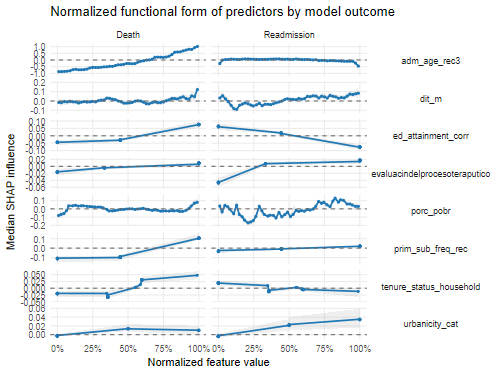

In [99]:
#| label: shap-criteria-func-form-get-shap-values

global_xgb_func_form <- readr::read_csv(
  find_latest_file(
    file.path(project_root, "cons", "_out"),
    "XGB12_corr_Functional_Forms_Dual_Aggregated"),
  show_col_types = FALSE
)
shap_norm <- global_xgb_func_form %>%
  filter(
    is.finite(Feature_Value),
    is.finite(SHAP_Impact)
  ) %>%
  group_by(Predictor) %>%
  mutate(
    n_unique = n_distinct(Feature_Value),
    Feature_Value_norm = dplyr::case_when(
      n_unique <= 1 ~ 0.5,
      n_unique <= 10 ~ (dense_rank(Feature_Value) - 1) / (n_unique - 1),
      TRUE ~ percent_rank(Feature_Value)
    )
  ) %>%
  ungroup()
shap_curve_norm <- shap_norm %>%
  group_by(Outcome, Predictor) %>%
  mutate(value_bin = dplyr::ntile(Feature_Value_norm, 50)) %>%
  group_by(Outcome, Predictor, value_bin) %>%
  summarise(
    x_norm = median(Feature_Value_norm, na.rm = TRUE),
    x_raw_median = median(Feature_Value, na.rm = TRUE),
    shap_median = median(SHAP_Impact, na.rm = TRUE),
    shap_q25 = quantile(SHAP_Impact, 0.25, na.rm = TRUE),
    shap_q75 = quantile(SHAP_Impact, 0.75, na.rm = TRUE),
    .groups = "drop"
  )

ggplot2::ggplot(filter(shap_curve_norm, !grepl("eva_",Predictor)), ggplot2::aes(x = x_norm, y = shap_median)) +
  ggplot2::geom_ribbon(ggplot2::aes(ymin = shap_q25, ymax = shap_q75), alpha = 0.2, fill = "grey70") +
  ggplot2::geom_line(linewidth = 0.8, colour = "#1f77b4") +
  ggplot2::geom_point(size = 0.8, colour = "#1f77b4") +
  ggplot2::geom_hline(yintercept = 0, linetype = "dashed", colour = "grey40") +
  ggplot2::facet_grid(Predictor ~ Outcome, scales = "free_y") +
  ggplot2::scale_x_continuous(
    labels = scales::percent_format(),
    limits = c(0, 1)
  ) +
  ggplot2::labs(
    x = "Normalized feature value",
    y = "Median SHAP influence",
    title = "Normalized functional form of predictors by model outcome"
  ) +
  ggplot2::theme_minimal(base_size = 11) +
  ggplot2::theme(
    strip.text.y = ggplot2::element_text(angle = 0),
    panel.grid.minor = ggplot2::element_blank()
  )

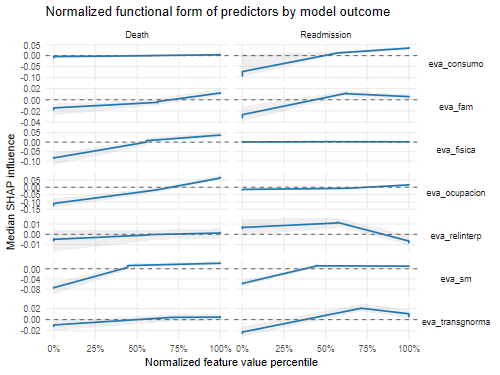

In [100]:
#| label: shap-criteria-func-form-get-shap-values2

ggplot2::ggplot(filter(shap_curve_norm, grepl("eva_",Predictor)), ggplot2::aes(x = x_norm, y = shap_median)) +
  ggplot2::geom_ribbon(
    ggplot2::aes(ymin = shap_q25, ymax = shap_q75),
    alpha = 0.2,
    fill = "grey70"
  ) +
  ggplot2::geom_line(linewidth = 0.8, colour = "#1f77b4") +
  ggplot2::geom_hline(yintercept = 0, linetype = "dashed", colour = "grey40") +
  ggplot2::facet_grid(Predictor ~ Outcome, scales = "free_y") +
  ggplot2::scale_x_continuous(
    labels = scales::percent_format(),
    limits = c(0, 1)
  ) +
  ggplot2::labs(
    x = "Normalized feature value percentile",
    y = "Median SHAP influence",
    title = "Normalized functional form of predictors by model outcome"
  ) +
  ggplot2::theme_minimal(base_size = 11) +
  ggplot2::theme(
    strip.text.y = ggplot2::element_text(angle = 0),
    panel.grid.minor = ggplot2::element_blank()
  )

For readmission model, very short treatment durations (e.g., 0.47 days) have a positive SHAP value (increasing readmission risk). The risk drops to negative values for medium durations (e.g., 2.38 to 3.87 days), and then rises steeply back to positive values for longer durations (e.g., >11 days).

For poverty percentage, theres a threshold / step-function, where lower poverty percentages (8%-9%) are associated with strong negative SHAP values (~ -0.11 to -14). However, once the percentage crosses a threshold (around 13% to 18%) the SHAP impact sharply jumps to strong positive values (~ 0.14).

For admission age, we observe an exponential acceleration (for Death) vs. inverted U-shape (for Readmission). Mortality risk typically follows the Gompertz law (exponential increase with age). Readmission is highly dependent on behavioral factors more prevalent in younger cohorts in this specific dataset.

For evaluation of the therapeutic process, the SHAP values bounce non-linearly across the integer codes. The suggested transformation is one-hot encoding.

In [101]:
#| label: shap-criteria-func-form-linear-terms-and-scores

# helper: create 3-level score for interaction terms based on main effect and interactor presence
make_3level_score <- function(intermedio, minimo) {
  dplyr::case_when(
    minimo == 1 ~ 2,
    intermedio == 1 ~ 1,
    TRUE ~ 0
  )
}
add_boot_linear_terms <- function(df) {
df <- df %>%
  dplyr::mutate(
    # Constructing linear scores (0 = Ref, 1 = Intermedio, 2 = Minimo) # Categorical variables for readmission
    eva_consumo_score   = eva_consumo_logro_intermedio * 1 + eva_consumo_logro_minimo * 2,
    eva_ocupacion_score = eva_ocupacion_logro_intermedio * 1 + eva_ocupacion_logro_minimo * 2,
    eva_fisica_score    = eva_fisica_logro_intermedio * 1 + eva_fisica_logro_minimo * 2,
    eva_relinterp_score = eva_relinterp_logro_intermedio * 1 + eva_relinterp_logro_minimo * 2,
    # Linear score for Death only, remains dummy for Readmission
    eva_sm_score        = eva_sm_logro_intermedio * 1 + eva_sm_logro_minimo * 2,
    # Constructing others (0 = Ref, 1 = Level 2, 2 = Level 3) # Categorical variables for readmission
    ed_attainment_score = ed_attainment_corr_2_completed_high_school_or_less * 1 + 
                          ed_attainment_corr_3_completed_primary_school_or_less * 2,
    # Categorical variables for readmission                        
    prim_sub_freq_score = prim_sub_freq_rec_2_2_6_days_wk * 1 + prim_sub_freq_rec_3_daily * 2
  )
}
py_corrected_datasets_boot <- lapply(py_corrected_datasets, add_boot_linear_terms)

In [102]:
formula_shap_readmit_clean_updated

Surv(readmit_time_from_disch_m, readmit_event) ~ primary_sub_mod_cocaine_paste + 
    primary_sub_mod_cocaine_powder + primary_sub_mod_alcohol + 
    primary_sub_mod_others + adm_age_rec3 + porc_pobr + sex_rec_woman + 
    ethnicity + dit_m + eva_consumo_logro_intermedio + eva_consumo_logro_minimo + 
    ed_attainment_corr_2_completed_high_school_or_less + ed_attainment_corr_3_completed_primary_school_or_less + 
    occupation_condition_corr24_unemployed + occupation_condition_corr24_inactive + 
    dg_psiq_cie_10_dg + sub_dep_icd10_status_drug_dependence + 
    polysubstance_strict + eva_sm_logro_intermedio + eva_sm_logro_minimo + 
    evaluacindelprocesoteraputico_logro_intermedio + tr_outcome_referral + 
    tr_outcome_dropout + tr_outcome_adm_discharge_adm_reasons + 
    prim_sub_freq_rec_2_2_6_days_wk + prim_sub_freq_rec_3_daily + 
    strata(plan_type_strata) + strata(tr_outcome_adm_discharge_rule_violation_undet)
<environment: 0x0000020d20a8fcf0>

In [103]:
#| label: shap-criteria-func-form-rcs

# ============================================================
# Functional-form sensitivity models based on actual predictors
# ============================================================

# Requirements:
# 1. Create dit_m_cap36 before fitting readmission models.
# 2. Use fixed knots across imputations/folds, preferably estimated
#    from the development/training data only.
# 3. Do not add variables to the death model that are not already in
#    formula_shap_death_interact unless this is an intentional
#    predictor-set expansion.

add_nonlinear_transf <- function(df) {
  # Capar dit_m en 36
  df <- df %>%
    dplyr::mutate(
      dit_m_cap36 = pmin(dit_m, 36, na.rm = TRUE),
      # Transformaciones spline usando knots fijos
      dit_m_ns1 = splines::ns(dit_m, knots = c(1.1, 3.9, 7.9, 19.3))[,1],
      dit_m_ns2 = splines::ns(dit_m, knots = c(1.1, 3.9, 7.9, 19.3))[,2],
      dit_m_ns3 = splines::ns(dit_m, knots = c(1.1, 3.9, 7.9, 19.3))[,3],
      #
      porc_pobr_ns1 = splines::ns(porc_pobr, knots = c(0.053, 0.105, 0.146, 0.261))[,1],
      porc_pobr_ns2 = splines::ns(porc_pobr, knots = c(0.053, 0.105, 0.146, 0.261))[,2],
      porc_pobr_ns3 = splines::ns(porc_pobr, knots = c(0.053, 0.105, 0.146, 0.261))[,3],  
      age_ns1 = splines::ns(adm_age_rec3,
                   knots = quantile(df$adm_age_rec3,
                                    probs = c(0.05, 0.35, 0.65, 0.95),
                                    na.rm = TRUE))[,1],
      age_ns2 = splines::ns(adm_age_rec3,
                   knots = quantile(df$adm_age_rec3,
                                    probs = c(0.05, 0.35, 0.65, 0.95),
                                    na.rm = TRUE))[,2],
      age_ns3 = splines::ns(adm_age_rec3,
                   knots = quantile(df$adm_age_rec3,
                                    probs = c(0.05, 0.35, 0.65, 0.95),
                                    na.rm = TRUE))[,3]
    )
  return(df)
}  # If you do not want to calculate them manually, use rcs(age, 4).

py_corrected_datasets_boot <- lapply(py_corrected_datasets_boot, add_nonlinear_transf)

In [104]:
#| label: shap-criteria-func-form-precomputed-ns-readm

# ============================================================
# READMISSION: baseline linear model
# ============================================================
form_readmit_xgb_linear <- formula_shap_readmit_clean_updated
# ============================================================
# READMISSION: age natural spline
# ============================================================
form_readmit_xgb_age_ns3 <- update(
  formula_shap_readmit_clean_updated,
  . ~ .
    - adm_age_rec3
    + age_ns1 + age_ns2 + age_ns3
)
# ============================================================
# READMISSION: dit_m capped natural spline
# ============================================================
# Replaces raw dit_m with the precomputed spline basis based on dit_m_cap36.
form_readmit_xgb_dit_ns3 <- update(
  formula_shap_readmit_clean_updated,
  . ~ .
    - dit_m
    + dit_m_ns1 + dit_m_ns2 + dit_m_ns3
)
form_readmit_xgb_dit_hinge5 <- update(
  formula_shap_readmit_clean_updated,
  . ~ . - dit_m + dit_m_hinge5
)
# Optional sensitivity: quadratic capped dit_m
form_readmit_xgb_dit_quad_sens <- update(
  formula_shap_readmit_clean_updated,
  . ~ .
    - dit_m
    + dit_m_cap36 + I(dit_m_cap36^2)
)
# Optional sensitivity: log capped dit_m
form_readmit_xgb_dit_log_sens <- update(
  formula_shap_readmit_clean_updated,
  . ~ .
    - dit_m
    + log1p(dit_m_cap36)
)

# ============================================================
# READMISSION: poverty natural spline
# ============================================================
form_readmit_xgb_pobr_ns3 <- update(
  formula_shap_readmit_clean_updated,
  . ~ .
    - porc_pobr
    + porc_pobr_ns1 + porc_pobr_ns2 + porc_pobr_ns3
)
form_readmit_xgb_porc_pobr_hinge015 <- update(
  formula_shap_readmit_clean_updated,
  . ~ .
    - porc_pobr
    + porc_pobr_hinge015
)
form_readmit_xgb_eva_sm_any <- update(
  formula_shap_readmit_clean_updated,
  . ~ . -
    eva_sm_logro_intermedio -
    eva_sm_logro_minimo +
    eva_sm_any
)
form_readmit_xgb_eva_consumo_any <- update(
  formula_shap_readmit_clean_updated,
  . ~ . -
    eva_consumo_logro_intermedio -
    eva_consumo_logro_minimo +
    eva_consumo_any
)

In [105]:
formula_shap_death_rule2

Surv(death_time_from_disch_m, death_event) ~ adm_age_rec3 + primary_sub_mod_cocaine_paste + 
    primary_sub_mod_cocaine_powder + primary_sub_mod_alcohol + 
    primary_sub_mod_others + prim_sub_freq_rec_2_2_6_days_wk + 
    prim_sub_freq_rec_3_daily + occupation_condition_corr24_unemployed + 
    occupation_condition_corr24_inactive + eva_ocupacion_logro_intermedio + 
    eva_ocupacion_logro_minimo + cohabitation_family_of_origin + 
    cohabitation_with_couple_children + cohabitation_others + 
    strata(plan_type_strata) + strata(any_phys_dx)
<environment: 0x0000020d29dc9760>

In [106]:
#| label: shap-criteria-func-form-death-nonlinear-transformations

add_nonlinear_transf2 <- function(df) {
  df <- df %>%
    dplyr::mutate(
      # Continuous variables available as-is
      dit_m_cap36 = dplyr::if_else(
        is.na(dit_m),
        NA_real_,
        pmin(dit_m, 36)
      ),
      dit_m_hinge9 = dplyr::if_else(
        is.na(dit_m_cap36),
        NA_real_,
        pmax(0, dit_m_cap36 - 9)
      ),
      dit_m_hinge5 = dplyr::if_else(
        is.na(dit_m_cap36),
        NA_real_,
        pmax(0, dit_m_cap36 - 5)
      ),
      porc_pobr_hinge022 = dplyr::if_else(
        is.na(porc_pobr),
        NA_real_,
        pmax(0, porc_pobr - 0.22)
      ),
      porc_pobr_hinge015 = dplyr::if_else(
        is.na(porc_pobr),
        NA_real_,
        pmax(0, porc_pobr - 0.15)
      ),
      adm_age_rec3_c = adm_age_rec3 - mean(adm_age_rec3, na.rm = TRUE),
      # From dummy variables already in the model
      prim_sub_freq_high = prim_sub_freq_rec_3_daily,
      eva_fisica_any = dplyr::if_else(
        is.na(eva_fisica_logro_intermedio) & is.na(eva_fisica_logro_minimo),
        NA_integer_,
        as.integer(
          dplyr::coalesce(eva_fisica_logro_intermedio, 0) == 1 |
            dplyr::coalesce(eva_fisica_logro_minimo, 0) == 1
        )
      ),
      eva_sm_any = dplyr::if_else(
        is.na(eva_sm_logro_intermedio) & is.na(eva_sm_logro_minimo),
        NA_integer_,
        as.integer(
          dplyr::coalesce(eva_sm_logro_intermedio, 0) == 1 |
            dplyr::coalesce(eva_sm_logro_minimo, 0) == 1
        )
      ),
      eva_consumo_any = dplyr::if_else(
        is.na(eva_consumo_logro_intermedio) & is.na(eva_consumo_logro_minimo),
        NA_integer_,
        as.integer(
          dplyr::coalesce(eva_consumo_logro_intermedio, 0) == 1 |
            dplyr::coalesce(eva_consumo_logro_minimo, 0) == 1
        )
      ),
      ed_attainment_high = ed_attainment_corr_3_completed_primary_school_or_less,
      tenure_hinge1 = pmax(
        0,
        dplyr::coalesce(tenure_status_household_others, 0) * 1 +
          dplyr::coalesce(tenure_status_household_renting, 0) * 2 +
          dplyr::coalesce(tenure_status_household_stays_temporarily_with_a_relative, 0) * 3 +
          dplyr::coalesce(tenure_status_household_illegal_settlement, 0) * 4 -
          1
      )
    )
  return(df)
}

py_corrected_datasets_boot <- lapply(py_corrected_datasets_boot, add_nonlinear_transf2)

In [107]:
#| label: shap-criteria-func-form-precomputed-ns-death

# # ============================================================
# # DEATH: baseline linear model
# # ============================================================
# form_death_xgb_linear <- formula_death_updated2

# # ============================================================
# # DEATH: preferred model
# # ============================================================
# # Keep linear age as preferred unless the spline sensitivity clearly improves
# # AICc/IBS without hurting discrimination.
# form_death_xgb_preferred <- formula_death_updated2

# # ============================================================
# # DEATH: age natural spline sensitivity
# # ============================================================
# form_death_xgb_age_ns3_sens <- update(
#   formula_death_updated2,
#   . ~ .
#     - adm_age_rec3
#     # - adm_age_rec3:primary_sub_mod_alcohol
#     # - adm_age_rec3:cohabitation_family_of_origin
#     # - adm_age_rec3:cohabitation_with_couple_children
#     # - adm_age_rec3:first_sub_used_alcohol
#     # - adm_age_rec3:occupation_condition_corr24_unemployed
#     # - adm_age_rec3:occupation_condition_corr24_inactive

#     + age_ns1 + age_ns2 + age_ns3

#     # + age_ns1:primary_sub_mod_alcohol
#     # + age_ns2:primary_sub_mod_alcohol
#     # + age_ns3:primary_sub_mod_alcohol

#     # + age_ns1:cohabitation_family_of_origin
#     # + age_ns2:cohabitation_family_of_origin
#     # + age_ns3:cohabitation_family_of_origin

#     # + age_ns1:cohabitation_with_couple_children
#     # + age_ns2:cohabitation_with_couple_children
#     # + age_ns3:cohabitation_with_couple_children

#     # + age_ns1:first_sub_used_alcohol
#     # + age_ns2:first_sub_used_alcohol
#     # + age_ns3:first_sub_used_alcohol

#     # + age_ns1:occupation_condition_corr24_unemployed
#     # + age_ns2:occupation_condition_corr24_unemployed
#     # + age_ns3:occupation_condition_corr24_unemployed

#     # + age_ns1:occupation_condition_corr24_inactive
#     # + age_ns2:occupation_condition_corr24_inactive
#     # + age_ns3:occupation_condition_corr24_inactive
# )

# # Optional simpler sensitivity: quadratic age
# form_death_xgb_age_quad_sens <- update(
#   formula_death_updated2,
#   . ~ .
#     # - adm_age_rec3
#     # - adm_age_rec3:primary_sub_mod_alcohol
#     # - adm_age_rec3:cohabitation_family_of_origin
#     # - adm_age_rec3:cohabitation_with_couple_children
#     # - adm_age_rec3:first_sub_used_alcohol
#     # - adm_age_rec3:occupation_condition_corr24_unemployed
#     # - adm_age_rec3:occupation_condition_corr24_inactive

#     + adm_age_rec3 + I(adm_age_rec3^2)

#     # + adm_age_rec3:primary_sub_mod_alcohol
#     # + I(adm_age_rec3^2):primary_sub_mod_alcohol

#     # + adm_age_rec3:cohabitation_family_of_origin
#     # + I(adm_age_rec3^2):cohabitation_family_of_origin

#     # + adm_age_rec3:cohabitation_with_couple_children
#     # + I(adm_age_rec3^2):cohabitation_with_couple_children

#     # + adm_age_rec3:first_sub_used_alcohol
#     # + I(adm_age_rec3^2):first_sub_used_alcohol

#     # + adm_age_rec3:occupation_condition_corr24_unemployed
#     # + I(adm_age_rec3^2):occupation_condition_corr24_unemployed

#     # + adm_age_rec3:occupation_condition_corr24_inactive
#     # + I(adm_age_rec3^2):occupation_condition_corr24_inactive
# )

In [108]:
#| label: shap-criteria-func-form-nonlin-formula-death

# 1) Replace dit_m with dit_m tail hinge only
form_death_xgb_dit_hinge9 <- update(
  formula_death_updated2,
  . ~ . - dit_m + dit_m_hinge9
)
# 2) Replace porc_pobr with poverty tail hinge only
form_death_xgb_pobr_hinge022 <- update(
  formula_death_updated2,
  . ~ . - porc_pobr + porc_pobr_hinge022
)
# 3) Replace tenure dummies with tenure hinge only
form_death_xgb_tenure_hinge1 <- update(
  formula_death_updated2,
  . ~ . -
    tenure_status_household_renting -
    tenure_status_household_others -
    tenure_status_household_stays_temporarily_with_a_relative -
    tenure_status_household_illegal_settlement +
    tenure_hinge1
)
# 4) Replace primary substance frequency dummies with high indicator only
form_death_xgb_prim_sub_freq_high <- update(
  formula_death_updated2,
  . ~ . -
    prim_sub_freq_rec_2_2_6_days_wk -
    prim_sub_freq_rec_3_daily +
    prim_sub_freq_high
)
# 5) Replace physical evaluation dummies with any-problem indicator only
form_death_xgb_eva_fisica_any <- update(
  formula_death_updated2,
  . ~ . -
    eva_fisica_logro_intermedio -
    eva_fisica_logro_minimo +
    eva_fisica_any
)
# 6) Replace mental health evaluation dummies with any-problem indicator only
form_death_xgb_eva_sm_any <- update(
  formula_death_updated2,
  . ~ . -
    eva_sm_logro_intermedio -
    eva_sm_logro_minimo +
    eva_sm_any
)
# 7) Replace education dummies with high-risk education indicator only
form_death_xgb_ed_attainment_high <- update(
  formula_death_updated2,
  . ~ . -
    ed_attainment_corr_2_completed_high_school_or_less -
    ed_attainment_corr_3_completed_primary_school_or_less +
    ed_attainment_high
)
form_death_xgb_eva_consumo_any <- update(
  formula_death_updated2,
  . ~ . -
    eva_consumo_logro_intermedio -
    eva_consumo_logro_minimo +
    eva_consumo_any
)


# ============================================================
# DEATH (full PH): age natural spline df=3
# ============================================================
form_death_xgb_age_ns3 <- update(
  formula_death_updated2,
  . ~ .
    - adm_age_rec3
    + age_ns1 + age_ns2 + age_ns3
)
# Keep strata(...) intact across deparse
form_death_xgb_age_ns3 <- as.formula(
  gsub("strat\\(", "strata(",
       paste(deparse(form_death_xgb_age_ns3), collapse = " ")))

# ============================================================
# DEATH (full PH): quadratic age sensitivity
# ============================================================
form_death_xgb_age_quad <- update(
  formula_death_updated2,
  . ~ .
    - adm_age_rec3
    + adm_age_rec3 + I(adm_age_rec3^2)
)

form_death_xgb_age_quad <- as.formula(
  gsub("strat\\(", "strata(",
       paste(deparse(form_death_xgb_age_quad), collapse = " "))
)

In [109]:
#| label: shap-criteria-func-form-nonlin-formula-death-simpler

# adm_age_rec3 (continua) → spline/cuadrática
# prim_sub_freq_rec (ordinal) → scoring
# eva_ocupacion (ordinal) → scoring ← esta es la que debes testear, no eva_fisica/consumo/sm

# 4) Replace primary substance frequency dummies with high indicator only
form_death_xgb_prim_sub_freq_high_simpler <- update(
  formula_shap_death_rule2,
  . ~ . -
    prim_sub_freq_rec_2_2_6_days_wk -
    prim_sub_freq_rec_3_daily +
    prim_sub_freq_high
)

# ============================================================
# DEATH (rule2): age natural spline df=3
# ============================================================
form_death_xgb_age_ns3_simpler <- update(
  formula_shap_death_rule2,
  . ~ .
    - adm_age_rec3
    + age_ns1 + age_ns2 + age_ns3
)
# Keep strata(...) intact across deparse
form_death_xgb_age_ns3_simpler <- as.formula(
  gsub("strat\\(", "strata(",
       paste(deparse(form_death_xgb_age_ns3_simpler), collapse = " ")))

# ============================================================
# DEATH (rule2): quadratic age sensitivity
# ============================================================
form_death_xgb_age_quad_simpler <- update(
  formula_shap_death_rule2,
  . ~ .
    - adm_age_rec3
    + adm_age_rec3 + I(adm_age_rec3^2)
)
form_death_xgb_age_quad_simpler <- as.formula(
  gsub("strat\\(", "strata(",
       paste(deparse(form_death_xgb_age_quad_simpler), collapse = " ")))


#### Test differences between death full vs. rule (2 strata)

In [110]:
#| label: shap-post-interaction-dual-python-style
# 2026-05-27= En cell 75: cambiar a eval_times = c(3,6,12,36,60) para que sea comparable
results_shap_xgb_py_upd_post_int_alt1 <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_clean_updated,
  formula_death = formula_death_updated2,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3,6,12,36,60)   # igual que todos los experimentos
)


Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


In [111]:
#| label: shap-post-interaction-dual-python-style-simpler
# 2026-05-27= En cell 75: cambiar a eval_times = c(3,6,12,36,60) para que sea comparable
results_shap_xgb_py_upd_post_int_alt2 <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_clean_updated,
  formula_death = formula_shap_death_rule2,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3,6,12,36,60)   # igual que todos los experimentos
)


Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


In [112]:
#| label: shap-criteria-post-int2-dual-cox-python-style

results_shap_xgb_py_upd_post_int_alt1$summary |> 
  dplyr::filter( Time %in% c("Global", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, updated formulas with interactions, stratified and with interactions for readmission, but not for death")



Table: Global C-index and IBS summary, updated formulas with interactions, stratified and with interactions for readmission, but not for death

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |60     | 0.3255283| 0.0081110| 0.3076652| 0.3357784| 25|
|Readmission |IBS           |Global | 0.3255283| 0.0081110| 0.3076652| 0.3357784| 25|
|Readmission |Uno's C-Index |60     | 0.6098245| 0.0041966| 0.6038450| 0.6174907| 25|
|Readmission |Uno's C-Index |Global | 0.6045642| 0.0054348| 0.5947070| 0.6147782| 25|
|Death       |IBS           |60     | 0.0675069| 0.0042183| 0.0602400| 0.0746390| 25|
|Death       |IBS           |Global | 0.0675069| 0.0042183| 0.0602400| 0.0746390| 25|
|Death       |Uno's C-Index |60     | 0.7626795| 0.0109877| 0.7472378| 0.7831355| 25|
|Death       |Uno's C-Index |Global | 0.7423727| 0.0107173| 0.7237427| 0.7604639

In [113]:
#| label: shap-criteria-post-int2-dual-cox-python-style-rule-based-death

results_shap_xgb_py_upd_post_int_alt2$summary |> 
  dplyr::filter( Time %in% c("Global", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, updated formulas with interactions, stratified and with interactions for readmission, but not for death")



Table: Global C-index and IBS summary, updated formulas with interactions, stratified and with interactions for readmission, but not for death

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |60     | 0.3255283| 0.0081110| 0.3076652| 0.3357784| 25|
|Readmission |IBS           |Global | 0.3255283| 0.0081110| 0.3076652| 0.3357784| 25|
|Readmission |Uno's C-Index |60     | 0.6098245| 0.0041966| 0.6038450| 0.6174907| 25|
|Readmission |Uno's C-Index |Global | 0.6045642| 0.0054348| 0.5947070| 0.6147782| 25|
|Death       |IBS           |60     | 0.0681139| 0.0043013| 0.0609327| 0.0752689| 25|
|Death       |IBS           |Global | 0.0681139| 0.0043013| 0.0609327| 0.0752689| 25|
|Death       |Uno's C-Index |60     | 0.7590632| 0.0116736| 0.7411266| 0.7811236| 25|
|Death       |Uno's C-Index |Global | 0.7401920| 0.0115161| 0.7212807| 0.7610779

### Admission age

In [114]:
#| label: shap-criteria-func-form-linear-terms-vs-ns-readmit-test

cat("\nComparing linear age terms vs. polynomial and spline age terms for readmission:\n")
compute_mi_aicc(formula_shap_readmit_clean_updated  , py_corrected_datasets_boot)
compute_mi_aicc(form_readmit_xgb_age_ns3  , py_corrected_datasets_boot)


Comparing linear age terms vs. polynomial and spline age terms for readmission:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272575.93
Mean AICc: 272576.02
Correction added (Penalty): 0.092247
Parameters (k): 26 | Effective Sample Size (Events): 15247

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272563.48
Mean AICc: 272563.59
Correction added (Penalty): 0.106716
Parameters (k): 28 | Effective Sample Size (Events): 15247


$mean_aicc
[1] 272563.6

$full_results
       aic correction     aicc  k n_events
1 272564.6  0.1067157 272564.7 28    15247
2 272562.1  0.1067157 272562.2 28    15247
3 272564.3  0.1067157 272564.4 28    15247
4 272562.7  0.1067157 272562.8 28    15247
5 272563.7  0.1067157 272563.8 28    15247


In [115]:
#| label: shap-criteria-func-form-linear-terms-vs-ns-readm-test

gc()

results_shap_py_int_readm_age_ns3 <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_xgb_age_ns3,#formula_shap_ds_readmit_interact,
  formula_death = formula_death_updated2,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3,6,12,36,60)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_xgb_py_upd_post_int_alt1$summary),
  cbind.data.frame(model= "Age spline df=3", results_shap_py_int_readm_age_ns3$summary)
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Readmission") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, readmission model with spline age terms")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, readmission model with spline age terms

|model           |Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:---------------|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear          |Readmission |IBS           |Global | 0.3255283| 0.0081110| 0.3076652| 0.3357784| 25|
|Age spline df=3 |Readmission |IBS           |Global | 0.3255485| 0.0081153| 0.3077693| 0.3359458| 25|
|Linear          |Readmission |Uno's C-Index |Global | 0.6045642| 0.0054348| 0.5947070| 0.6147782| 25|
|Age spline df=3 |Readmission |Uno's C-Index |Global | 0.6047356| 0.0050894| 0.5963033| 0.6141279| 25|

In [116]:
#| label: shap-criteria-func-form-linear-terms-vs-ns-readm-test-simpler

gc()

results_shap_py_int_readm_age_ns3_simpler <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_xgb_age_ns3,#formula_shap_ds_readmit_interact,
  formula_death = formula_shap_death_rule2,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3,6,12,36,60)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_xgb_py_upd_post_int_alt2$summary),
  cbind.data.frame(model= "Age spline df=3", results_shap_py_int_readm_age_ns3_simpler$summary)
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Readmission") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, readmission model with spline age terms")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, readmission model with spline age terms

|model           |Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:---------------|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear          |Readmission |IBS           |Global | 0.3255283| 0.0081110| 0.3076652| 0.3357784| 25|
|Age spline df=3 |Readmission |IBS           |Global | 0.3255485| 0.0081153| 0.3077693| 0.3359458| 25|
|Linear          |Readmission |Uno's C-Index |Global | 0.6045642| 0.0054348| 0.5947070| 0.6147782| 25|
|Age spline df=3 |Readmission |Uno's C-Index |Global | 0.6047356| 0.0050894| 0.5963033| 0.6141279| 25|

#### Death

In [117]:
#| label: shap-criteria-func-form-linear-terms-vs-age-death-aicc

cat("\nComparing linear age vs spline/quadratic age terms for death:\n")
compute_mi_aicc(formula_death_updated2, py_corrected_datasets_boot)
compute_mi_aicc(form_death_xgb_age_ns3, py_corrected_datasets_boot)
compute_mi_aicc(form_death_xgb_age_quad, py_corrected_datasets_boot)

cat("\nComparing linear age vs spline/quadratic age terms for simpler death model:\n")
compute_mi_aicc(formula_shap_death_rule2, py_corrected_datasets_boot)
compute_mi_aicc(form_death_xgb_age_ns3_simpler, py_corrected_datasets_boot)
compute_mi_aicc(form_death_xgb_age_quad_simpler, py_corrected_datasets_boot)


Comparing linear age vs spline/quadratic age terms for death:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51493.53
Mean AICc: 51496.24
Correction added (Penalty): 2.710588
Parameters (k): 63 | Effective Sample Size (Events): 3039

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51682.54
Mean AICc: 51685.42
Correction added (Penalty): 2.885974
Parameters (k): 65 | Effective Sample Size (Events): 3039

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51479.45
Mean AICc: 51482.25
Correction added (Penalty): 2.797579
Parameters (k): 64 | Effective Sample Size (Events): 3039

Comparing linear age vs spline/quadratic age terms for simpler death model:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51078.02
Mean AICc: 51078.15
Correction added (Penalty): 0.138889
Parameters (k): 14 | Effective Sample Size (Events): 3039

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51300.91
Mean AICc: 51301.09
Correction added (Penalty): 0.180013
Parameters (k): 16 | Effective Sample 

$mean_aicc
[1] 51064.77

$full_results
       aic correction     aicc  k n_events
1 51060.38  0.1587827 51060.54 15     3039
2 51067.28  0.1587827 51067.43 15     3039
3 51066.75  0.1587827 51066.91 15     3039
4 51063.74  0.1587827 51063.90 15     3039
5 51064.91  0.1587827 51065.07 15     3039


In [118]:
#| label: shap-criteria-func-form-linear-terms-vs-ns-death-age-test

gc()

results_shap_py_int_death_age_ns3 <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_clean_updated,
  formula_death = form_death_xgb_age_ns3,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3,6,12,36,60)
)
results_shap_py_int_death_age_quad <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_clean_updated,
  formula_death = form_death_xgb_age_quad,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3,6,12,36,60)
)

rbind.data.frame(
  cbind(model = "Linear", results_shap_xgb_py_upd_post_int_alt1$summary),
  cbind.data.frame(model = "Age spline df=3", results_shap_py_int_death_age_ns3$summary),
  cbind.data.frame(model = "Age quadratic", results_shap_py_int_death_age_quad$summary)
) |>
  dplyr::filter(Time %in% c("Global"), Risk == "Death") |>
  dplyr::arrange(Metric) |>
  knitr::kable("markdown", caption = "Global C-index and IBS summary, death model with spline/quadratic age terms")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, death model with spline/quadratic age terms

|model           |Risk  |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:---------------|:-----|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear          |Death |IBS           |Global | 0.0675069| 0.0042183| 0.0602400| 0.0746390| 25|
|Age spline df=3 |Death |IBS           |Global | 0.0680382| 0.0042546| 0.0609068| 0.0754552| 25|
|Age quadratic   |Death |IBS           |Global | 0.0674924| 0.0042093| 0.0602634| 0.0746508| 25|
|Linear          |Death |Uno's C-Index |Global | 0.7423727| 0.0107173| 0.7237427| 0.7604639| 25|
|Age spline df=3 |Death |Uno's C-Index |Global | 0.7358130| 0.0093392| 0.7205742| 0.7508161| 25|
|Age quadratic   |Death |Uno's C-Index |Global | 0.7427048| 0.0107621| 0.7231536| 0.7610328| 25|

In [120]:
#| label: shap-criteria-func-form-linear-terms-vs-ns-death-age-test-simpler

gc()

results_shap_py_int_death_age_ns3_simpler <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_clean_updated,
  formula_death = form_death_xgb_age_ns3_simpler,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3,6,12,36,60)
)

rbind.data.frame(
  cbind(model = "Linear", results_shap_xgb_py_upd_post_int_alt2$summary),
  cbind.data.frame(model = "Age spline df=3", results_shap_py_int_death_age_ns3_simpler$summary)
) |>
  dplyr::filter(Time %in% c("Global"), Risk == "Death") |>
  dplyr::arrange(Metric) |>
  knitr::kable("markdown", caption = "Global C-index and IBS summary, simpler death model with spline age terms")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, simpler death model with spline age terms

|model           |Risk  |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:---------------|:-----|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear          |Death |IBS           |Global | 0.0681139| 0.0043013| 0.0609327| 0.0752689| 25|
|Age spline df=3 |Death |IBS           |Global | 0.0686788| 0.0043774| 0.0615611| 0.0761040| 25|
|Linear          |Death |Uno's C-Index |Global | 0.7401920| 0.0115161| 0.7212807| 0.7610779| 25|
|Age spline df=3 |Death |Uno's C-Index |Global | 0.7324828| 0.0106886| 0.7148974| 0.7521596| 25|

### Treatment duration

In [121]:
#| label: shap-criteria-func-form-linear-terms-vs-trans-readm-tr-duration

cat("\nComparing linear age terms vs. polynomial and spline age terms for readmission:\n")
compute_mi_aicc(form_readmit_xgb_dit_ns3  , py_corrected_datasets_boot)
compute_mi_aicc(form_readmit_xgb_dit_hinge5  , py_corrected_datasets_boot)
compute_mi_aicc(form_readmit_xgb_dit_quad_sens  , py_corrected_datasets_boot)
compute_mi_aicc(form_readmit_xgb_dit_log_sens  , py_corrected_datasets_boot)


Comparing linear age terms vs. polynomial and spline age terms for readmission:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272550.63
Mean AICc: 272550.74
Correction added (Penalty): 0.106716
Parameters (k): 28 | Effective Sample Size (Events): 15247

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272586.94
Mean AICc: 272587.03
Correction added (Penalty): 0.092247
Parameters (k): 26 | Effective Sample Size (Events): 15247

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272549.75
Mean AICc: 272549.85
Correction added (Penalty): 0.099349
Parameters (k): 27 | Effective Sample Size (Events): 15247

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272552.49
Mean AICc: 272552.58
Correction added (Penalty): 0.092247
Parameters (k): 26 | Effective Sample Size (Events): 15247


$mean_aicc
[1] 272552.6

$full_results
       aic correction     aicc  k n_events
1 272553.6 0.09224704 272553.7 26    15247
2 272551.1 0.09224704 272551.2 26    15247
3 272553.3 0.09224704 272553.4 26    15247
4 272551.7 0.09224704 272551.8 26    15247
5 272552.8 0.09224704 272552.9 26    15247


In [122]:
#| label: shap-criteria-func-form-linear-terms-vs-trans-readm-tr-duration-test

gc()

results_shap_py_int_readm_dit_ns3 <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_xgb_dit_ns3,#formula_shap_ds_readmit_interact,
  formula_death = formula_death_updated2,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3,6,12,36,60)
)
results_shap_py_int_readm_dit_quad <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_xgb_dit_quad_sens,#formula_shap_ds_readmit_interact,
  formula_death = formula_death_updated2,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3,6,12,36,60)
)
results_shap_py_int_readm_dit_hinge5 <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_xgb_dit_hinge5,#formula_shap_ds_readmit_interact,
  formula_death = formula_death_updated2,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3,6,12,36,60)
)
results_shap_py_int_readm_dit_log <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_xgb_dit_log_sens,#formula_shap_ds_readmit_interact,
  formula_death = formula_death_updated2,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3,6,12,36,60)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_xgb_py_upd_post_int_alt1$summary),
  cbind.data.frame(model= "DIT spline df=3", results_shap_py_int_readm_dit_ns3$summary),
  cbind.data.frame(model= "DIT cuadratic", results_shap_py_int_readm_dit_quad$summary),
  cbind.data.frame(model= "DIT hinge at 5", results_shap_py_int_readm_dit_hinge5$summary),
  cbind.data.frame(model= "DIT logarithmic", results_shap_py_int_readm_dit_log$summary)
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Readmission") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, readmission model with different tr.duration terms")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, readmission model with different tr.duration terms

|model           |Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:---------------|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear          |Readmission |IBS           |Global | 0.3255283| 0.0081110| 0.3076652| 0.3357784| 25|
|DIT spline df=3 |Readmission |IBS           |Global | 0.3254886| 0.0081882| 0.3074106| 0.3356935| 25|
|DIT cuadratic   |Readmission |IBS           |Global | 0.3254361| 0.0081401| 0.3074759| 0.3356955| 25|
|DIT hinge at 5  |Readmission |IBS           |Global | 0.3255977| 0.0081156| 0.3077236| 0.3358933| 25|
|DIT logarithmic |Readmission |IBS           |Global | 0.3253883| 0.0080992| 0.3075323| 0.3355473| 25|
|Linear          |Readmission |Uno's C-Index |Global | 0.6045642| 0.0054348| 0.5947070| 0.6147782| 25|
|DIT spline df=3 |Readmission |Uno's C-Index |Global | 0.6054175| 0.0049604| 0.5969

In [123]:
#| label: shap-criteria-func-form-linear-terms-vs-trans-readm-tr-duration-test-simpler

gc()

results_shap_py_int_readm_dit_ns3_simpler <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_xgb_dit_ns3,#formula_shap_ds_readmit_interact,
  formula_death = formula_shap_death_rule2,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3,6,12,36,60)
)
results_shap_py_int_readm_dit_quad_simpler <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_xgb_dit_quad_sens,#formula_shap_ds_readmit_interact,
  formula_death = formula_shap_death_rule2,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3,6,12,36,60)
)
results_shap_py_int_readm_dit_hinge5_simpler <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_xgb_dit_hinge5,#formula_shap_ds_readmit_interact,
  formula_death = formula_shap_death_rule2,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3,6,12,36,60)
)
results_shap_py_int_readm_dit_log_simpler <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_xgb_dit_log_sens,#formula_shap_ds_readmit_interact,
  formula_death = formula_shap_death_rule2,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3,6,12,36,60)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_xgb_py_upd_post_int_alt2$summary),
  cbind.data.frame(model= "DIT spline df=3", results_shap_py_int_readm_dit_ns3_simpler$summary),
  cbind.data.frame(model= "DIT cuadratic", results_shap_py_int_readm_dit_quad_simpler$summary),
  cbind.data.frame(model= "DIT hinge at 5", results_shap_py_int_readm_dit_hinge5_simpler$summary),
  cbind.data.frame(model= "DIT logarithmic", results_shap_py_int_readm_dit_log_simpler$summary)
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Readmission") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, readmission model with different tr.duration terms")


Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, readmission model with different tr.duration terms

|model           |Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:---------------|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear          |Readmission |IBS           |Global | 0.3255283| 0.0081110| 0.3076652| 0.3357784| 25|
|DIT spline df=3 |Readmission |IBS           |Global | 0.3254886| 0.0081882| 0.3074106| 0.3356935| 25|
|DIT cuadratic   |Readmission |IBS           |Global | 0.3254361| 0.0081401| 0.3074759| 0.3356955| 25|
|DIT hinge at 5  |Readmission |IBS           |Global | 0.3255977| 0.0081156| 0.3077236| 0.3358933| 25|
|DIT logarithmic |Readmission |IBS           |Global | 0.3253883| 0.0080992| 0.3075323| 0.3355473| 25|
|Linear          |Readmission |Uno's C-Index |Global | 0.6045642| 0.0054348| 0.5947070| 0.6147782| 25|
|DIT spline df=3 |Readmission |Uno's C-Index |Global | 0.6054175| 0.0049604| 0.5969

#### Death

In [124]:
#| label: shap-criteria-func-form-linear-terms-vs-trans-death-tr-duration

cat("\nComparing linear duration vs. tail-hinge at value=9 for death:\n")
compute_mi_aicc(formula_death_updated2  , py_corrected_datasets_boot)

compute_mi_aicc(formula_shap_death_rule2  , py_corrected_datasets_boot)
compute_mi_aicc( form_death_xgb_dit_hinge9 , py_corrected_datasets_boot)


Comparing linear duration vs. tail-hinge at value=9 for death:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51493.53
Mean AICc: 51496.24
Correction added (Penalty): 2.710588
Parameters (k): 63 | Effective Sample Size (Events): 3039

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51078.02
Mean AICc: 51078.15
Correction added (Penalty): 0.138889
Parameters (k): 14 | Effective Sample Size (Events): 3039

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51495.94
Mean AICc: 51498.65
Correction added (Penalty): 2.710588
Parameters (k): 63 | Effective Sample Size (Events): 3039


$mean_aicc
[1] 51498.65

$full_results
       aic correction     aicc  k n_events
1 51489.08   2.710588 51491.79 63     3039
2 51500.65   2.710588 51503.36 63     3039
3 51497.87   2.710588 51500.58 63     3039
4 51496.51   2.710588 51499.22 63     3039
5 51495.59   2.710588 51498.30 63     3039


In [125]:
#| label: shap-criteria-func-form-linear-terms-vs-trans-death-dit-test

gc()

results_shap_py_int_death_dit_hinge_9 <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_clean_updated,
  formula_death = form_death_xgb_dit_hinge9,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3,6,12,36,60)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_xgb_py_upd_post_int_alt1$summary),
  cbind.data.frame(model= "DIT hinge at 9", results_shap_py_int_death_dit_hinge_9$summary)
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Death") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, death model with different tr.duration terms")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, death model with different tr.duration terms

|model          |Risk  |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:--------------|:-----|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear         |Death |IBS           |Global | 0.0675069| 0.0042183| 0.0602400| 0.0746390| 25|
|DIT hinge at 9 |Death |IBS           |Global | 0.0675076| 0.0042203| 0.0602406| 0.0746530| 25|
|Linear         |Death |Uno's C-Index |Global | 0.7423727| 0.0107173| 0.7237427| 0.7604639| 25|
|DIT hinge at 9 |Death |Uno's C-Index |Global | 0.7423248| 0.0107263| 0.7236747| 0.7604908| 25|

### Poverty index

In [126]:
#| label: shap-criteria-func-form-linear-terms-vs-trans-readm-poverty

cat("\nComparing linear proverty index terms vs. spline & nonlinear transformation of poverty index terms for readmission:\n")
compute_mi_aicc(form_readmit_xgb_pobr_ns3  , py_corrected_datasets_boot)
compute_mi_aicc(form_readmit_xgb_porc_pobr_hinge015  , py_corrected_datasets_boot)


Comparing linear proverty index terms vs. spline & nonlinear transformation of poverty index terms for readmission:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272524.56
Mean AICc: 272524.67
Correction added (Penalty): 0.106716
Parameters (k): 28 | Effective Sample Size (Events): 15247

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272586.93
Mean AICc: 272587.02
Correction added (Penalty): 0.092247
Parameters (k): 26 | Effective Sample Size (Events): 15247


$mean_aicc
[1] 272587

$full_results
       aic correction     aicc  k n_events
1 272588.0 0.09224704 272588.1 26    15247
2 272585.5 0.09224704 272585.6 26    15247
3 272587.7 0.09224704 272587.8 26    15247
4 272586.2 0.09224704 272586.3 26    15247
5 272587.2 0.09224704 272587.3 26    15247


In [127]:
#| label: shap-criteria-func-form-linear-terms-vs-trans-readm-poverty-test

gc()

results_shap_py_int_readm_pobr_ns3 <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_xgb_pobr_ns3,#formula_shap_ds_readmit_interact,
  formula_death = formula_death_updated2,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3,6,12,36,60)
)

results_shap_py_int_readm_pobr_hinge015 <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_xgb_porc_pobr_hinge015,#formula_shap_ds_readmit_interact,
  formula_death = formula_death_updated2,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3,6,12,36,60)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_xgb_py_upd_post_int_alt1$summary),
  cbind.data.frame(model= "Poverty index spline df=3", results_shap_py_int_readm_pobr_ns3$summary),
  cbind.data.frame(model= "Poverty index, hinge at 15", results_shap_py_int_readm_pobr_hinge015$summary)  
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Readmission") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, readmission model vs. nonlinear transformation on poverty index")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, readmission model vs. nonlinear transformation on poverty index

|model                      |Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:--------------------------|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear                     |Readmission |IBS           |Global | 0.3255283| 0.0081110| 0.3076652| 0.3357784| 25|
|Poverty index spline df=3  |Readmission |IBS           |Global | 0.3258941| 0.0082419| 0.3076166| 0.3361619| 25|
|Poverty index, hinge at 15 |Readmission |IBS           |Global | 0.3254639| 0.0080676| 0.3078157| 0.3356819| 25|
|Linear                     |Readmission |Uno's C-Index |Global | 0.6045642| 0.0054348| 0.5947070| 0.6147782| 25|
|Poverty index spline df=3  |Readmission |Uno's C-Index |Global | 0.6053068| 0.0053722| 0.5960189| 0.6140522| 25|
|Poverty index, hinge at 15 |Readmission |Uno's C-Index |Global | 0.6042400| 0.0054089| 0.594304

In [128]:
#| label: shap-criteria-func-form-linear-terms-vs-trans-readm-poverty-test-simpler

gc()

results_shap_py_int_readm_pobr_ns3_simpler <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_xgb_pobr_ns3,#formula_shap_ds_readmit_interact,
  formula_death = formula_shap_death_rule2,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3,6,12,36,60)
)

results_shap_py_int_readm_pobr_hinge015_simpler <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_xgb_porc_pobr_hinge015,#formula_shap_ds_readmit_interact,
  formula_death = formula_shap_death_rule2,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3,6,12,36,60)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_xgb_py_upd_post_int_alt2$summary),
  cbind.data.frame(model= "Poverty index spline df=3", results_shap_py_int_readm_pobr_ns3_simpler$summary),
  cbind.data.frame(model= "Poverty index, hinge at 15", results_shap_py_int_readm_pobr_hinge015_simpler$summary)  
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Readmission") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, readmission model vs. nonlinear transformation on poverty index")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, readmission model vs. nonlinear transformation on poverty index

|model                      |Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:--------------------------|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear                     |Readmission |IBS           |Global | 0.3255283| 0.0081110| 0.3076652| 0.3357784| 25|
|Poverty index spline df=3  |Readmission |IBS           |Global | 0.3258941| 0.0082419| 0.3076166| 0.3361619| 25|
|Poverty index, hinge at 15 |Readmission |IBS           |Global | 0.3254639| 0.0080676| 0.3078157| 0.3356819| 25|
|Linear                     |Readmission |Uno's C-Index |Global | 0.6045642| 0.0054348| 0.5947070| 0.6147782| 25|
|Poverty index spline df=3  |Readmission |Uno's C-Index |Global | 0.6053068| 0.0053722| 0.5960189| 0.6140522| 25|
|Poverty index, hinge at 15 |Readmission |Uno's C-Index |Global | 0.6042400| 0.0054089| 0.594304

#### Death

In [129]:
#| label: shap-criteria-func-form-linear-terms-vs-trans-death-poverty

cat("\nComparing linear proverty index terms vs. tail-hinge poverty index terms for death:\n")#porc_pobr_hinge022
compute_mi_aicc(form_death_xgb_pobr_hinge022  , py_corrected_datasets_boot)


Comparing linear proverty index terms vs. tail-hinge poverty index terms for death:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51493.39
Mean AICc: 51496.10
Correction added (Penalty): 2.710588
Parameters (k): 63 | Effective Sample Size (Events): 3039


$mean_aicc
[1] 51496.1

$full_results
       aic correction     aicc  k n_events
1 51486.49   2.710588 51489.20 63     3039
2 51498.14   2.710588 51500.85 63     3039
3 51495.29   2.710588 51498.00 63     3039
4 51493.95   2.710588 51496.66 63     3039
5 51493.11   2.710588 51495.82 63     3039


In [130]:
#| label: shap-criteria-func-form-linear-terms-vs-trans-death-poverty-test

gc()

results_shap_py_int_death_pobr_hinge022 <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_clean_updated,
  formula_death = form_death_xgb_pobr_hinge022,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3,6,12,36,60)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_xgb_py_upd_post_int_alt1$summary),
  cbind.data.frame(model= "Poverty index hinge at 22", results_shap_py_int_death_pobr_hinge022$summary)
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Death") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, death model vs. nonlinear transformation on poverty index")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, death model vs. nonlinear transformation on poverty index

|model                     |Risk  |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-------------------------|:-----|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear                    |Death |IBS           |Global | 0.0675069| 0.0042183| 0.0602400| 0.0746390| 25|
|Poverty index hinge at 22 |Death |IBS           |Global | 0.0675079| 0.0042178| 0.0602484| 0.0746326| 25|
|Linear                    |Death |Uno's C-Index |Global | 0.7423727| 0.0107173| 0.7237427| 0.7604639| 25|
|Poverty index hinge at 22 |Death |Uno's C-Index |Global | 0.7424086| 0.0106575| 0.7236685| 0.7603845| 25|

### Death: Tenure status of household

 We transformed multiple dummy variables into a single ordinal index of housing precariousness, where 0 represents ownership or “other” tenure, and higher values (1–3) represent progressively less secure housing situations.

In [131]:
#| label: shap-criteria-func-form-linear-terms-vs-tenure-death-aicc

# # Tenure: mostly monotone after ~1
cat("\nComparing dummy terms vs. hinge at 1 of tenure status of household terms for death:\n")
compute_mi_aicc(form_death_xgb_tenure_hinge1  , py_corrected_datasets_boot)


Comparing dummy terms vs. hinge at 1 of tenure status of household terms for death:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51495.05
Mean AICc: 51497.50
Correction added (Penalty): 2.458026
Parameters (k): 60 | Effective Sample Size (Events): 3039


$mean_aicc
[1] 51497.5

$full_results
       aic correction     aicc  k n_events
1 51489.16   2.458026 51491.61 60     3039
2 51499.38   2.458026 51501.84 60     3039
3 51496.38   2.458026 51498.84 60     3039
4 51496.33   2.458026 51498.79 60     3039
5 51493.98   2.458026 51496.43 60     3039


In [132]:
#| label: shap-criteria-func-form-linear-terms-vs-tenure-death-test

gc()

results_shap_py_int_death_tenure_hinge1 <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_clean_updated,
  formula_death = form_death_xgb_tenure_hinge1,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3,6,12,36,60)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_xgb_py_upd_post_int_alt1$summary),
  cbind.data.frame(model= "Tenure household: hinge at 1", results_shap_py_int_death_tenure_hinge1$summary)
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Death") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, death model vs. nonlinear transformation on tenure status of household")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, death model vs. nonlinear transformation on tenure status of household

|model                        |Risk  |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:----------------------------|:-----|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear                       |Death |IBS           |Global | 0.0675069| 0.0042183| 0.0602400| 0.0746390| 25|
|Tenure household: hinge at 1 |Death |IBS           |Global | 0.0675189| 0.0042291| 0.0602154| 0.0746384| 25|
|Linear                       |Death |Uno's C-Index |Global | 0.7423727| 0.0107173| 0.7237427| 0.7604639| 25|
|Tenure household: hinge at 1 |Death |Uno's C-Index |Global | 0.7420058| 0.0110540| 0.7226763| 0.7598368| 25|

### Death: Primary substance use frequency (daily)

In [133]:
#| label: shap-criteria-func-form-linear-terms-vs-prim-subs-freq-daily-death-aicc
# # Primary substance frequency: mostly monotone after 2-6 days/week
cat("\nComparing dummy terms vs. hinge at 1 of primary substance frequency terms for death:\n")
compute_mi_aicc(form_death_xgb_prim_sub_freq_high  , py_corrected_datasets_boot)


Comparing dummy terms vs. hinge at 1 of primary substance frequency terms for death:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51491.82
Mean AICc: 51494.44
Correction added (Penalty): 2.625000
Parameters (k): 62 | Effective Sample Size (Events): 3039


$mean_aicc
[1] 51494.44

$full_results
       aic correction     aicc  k n_events
1 51485.01      2.625 51487.64 62     3039
2 51496.52      2.625 51499.14 62     3039
3 51493.64      2.625 51496.27 62     3039
4 51492.42      2.625 51495.05 62     3039
5 51491.49      2.625 51494.11 62     3039


In [134]:
#| label: shap-criteria-func-form-linear-terms-vs-prim-subs-freq-daily-death-test

gc()

results_shap_py_int_death_prim_sub_freq_daily <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_clean_updated,
  formula_death = form_death_xgb_prim_sub_freq_high,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3,6,12,36,60)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_xgb_py_upd_post_int_alt1$summary),
  cbind.data.frame(model= "Primary substance use frequency: daily", results_shap_py_int_death_prim_sub_freq_daily$summary)
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Death") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, death model vs. nonlinear transformation on primary substance use frequency")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, death model vs. nonlinear transformation on primary substance use frequency

|model                                  |Risk  |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:--------------------------------------|:-----|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear                                 |Death |IBS           |Global | 0.0675069| 0.0042183| 0.0602400| 0.0746390| 25|
|Primary substance use frequency: daily |Death |IBS           |Global | 0.0675045| 0.0042187| 0.0602339| 0.0746371| 25|
|Linear                                 |Death |Uno's C-Index |Global | 0.7423727| 0.0107173| 0.7237427| 0.7604639| 25|
|Primary substance use frequency: daily |Death |Uno's C-Index |Global | 0.7426884| 0.0106000| 0.7241330| 0.7607627| 25|

In [135]:
#| label: shap-criteria-func-form-linear-terms-vs-prim-sub-freq-death-aicc-simpler

cat("\nComparing original primary substance frequency dummies vs. high-frequency indicator for simpler death model:\n")
compute_mi_aicc(formula_shap_death_rule2, py_corrected_datasets_boot)
compute_mi_aicc(form_death_xgb_prim_sub_freq_high_simpler, py_corrected_datasets_boot)


Comparing original primary substance frequency dummies vs. high-frequency indicator for simpler death model:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51078.02
Mean AICc: 51078.15
Correction added (Penalty): 0.138889
Parameters (k): 14 | Effective Sample Size (Events): 3039

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51076.90
Mean AICc: 51077.02
Correction added (Penalty): 0.120331
Parameters (k): 13 | Effective Sample Size (Events): 3039


$mean_aicc
[1] 51077.02

$full_results
       aic correction     aicc  k n_events
1 51072.83  0.1203306 51072.95 13     3039
2 51079.66  0.1203306 51079.78 13     3039
3 51078.72  0.1203306 51078.84 13     3039
4 51076.07  0.1203306 51076.19 13     3039
5 51077.21  0.1203306 51077.33 13     3039


In [136]:
#| label: shap-criteria-func-form-linear-terms-vs-prim-sub-freq-death-test-simpler

gc()

results_shap_py_int_death_prim_sub_freq_high_simpler <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_clean_updated,
  formula_death = form_death_xgb_prim_sub_freq_high_simpler,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3,6,12,36,60)
)

rbind.data.frame(
  cbind.data.frame(model = "Categorical", results_shap_xgb_py_upd_post_int_alt2$summary),
  cbind.data.frame(model = "High frequency", results_shap_py_int_death_prim_sub_freq_high_simpler$summary)
) |>
  dplyr::filter(Time %in% c("Global"), Risk == "Death") |>
  dplyr::arrange(Metric) |>
  knitr::kable(
    "markdown",
    caption = "Global C-index and IBS summary, simpler death model with high-frequency primary substance use indicator"
  )

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, simpler death model with high-frequency primary substance use indicator

|model          |Risk  |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:--------------|:-----|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Categorical    |Death |IBS           |Global | 0.0681139| 0.0043013| 0.0609327| 0.0752689| 25|
|High frequency |Death |IBS           |Global | 0.0681157| 0.0043018| 0.0609326| 0.0752713| 25|
|Categorical    |Death |Uno's C-Index |Global | 0.7401920| 0.0115161| 0.7212807| 0.7610779| 25|
|High frequency |Death |Uno's C-Index |Global | 0.7406488| 0.0113170| 0.7225827| 0.7617142| 25|

### Death: Educational attainment (primary school or less)

In [137]:
#| label: shap-criteria-func-form-linear-terms-vs-ed-attainment-death-aicc

cat("\nComparing dummy terms vs. educational attainment terms for death:\n")
compute_mi_aicc(form_death_xgb_ed_attainment_high  , py_corrected_datasets_boot)


Comparing dummy terms vs. educational attainment terms for death:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51491.54
Mean AICc: 51494.17
Correction added (Penalty): 2.625000
Parameters (k): 62 | Effective Sample Size (Events): 3039


$mean_aicc
[1] 51494.17

$full_results
       aic correction     aicc  k n_events
1 51484.62      2.625 51487.25 62     3039
2 51496.21      2.625 51498.84 62     3039
3 51493.54      2.625 51496.16 62     3039
4 51492.09      2.625 51494.72 62     3039
5 51491.25      2.625 51493.87 62     3039


In [138]:
#| label: shap-criteria-func-form-linear-terms-vs-ed-attainment-death-test

gc()

results_shap_py_int_death_ed_attainment_primary <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_clean_updated,
  formula_death = form_death_xgb_ed_attainment_high,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3,6,12,36,60)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_xgb_py_upd_post_int_alt1$summary),
  cbind.data.frame(model= "Primary school or less ed. attianment", results_shap_py_int_death_ed_attainment_primary$summary)
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Death") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, death model vs. nonlinear transformation on educational attainment")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, death model vs. nonlinear transformation on educational attainment

|model                                 |Risk  |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-------------------------------------|:-----|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear                                |Death |IBS           |Global | 0.0675069| 0.0042183| 0.0602400| 0.0746390| 25|
|Primary school or less ed. attianment |Death |IBS           |Global | 0.0675052| 0.0042164| 0.0602404| 0.0746404| 25|
|Linear                                |Death |Uno's C-Index |Global | 0.7423727| 0.0107173| 0.7237427| 0.7604639| 25|
|Primary school or less ed. attianment |Death |Uno's C-Index |Global | 0.7424189| 0.0107138| 0.7238453| 0.7604725| 25|

### Death: Physical health evaluation at discharge (any achievement lower than high)

In [139]:
#| label: shap-criteria-func-form-linear-terms-vs-eva-fisica-death-aicc

cat("\nComparing dummy terms vs. physical health evaluation at discharge terms for death:\n")
compute_mi_aicc(form_death_xgb_eva_fisica_any  , py_corrected_datasets_boot)


Comparing dummy terms vs. physical health evaluation at discharge terms for death:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51501.01
Mean AICc: 51503.63
Correction added (Penalty): 2.625000
Parameters (k): 62 | Effective Sample Size (Events): 3039


$mean_aicc
[1] 51503.63

$full_results
       aic correction     aicc  k n_events
1 51494.04      2.625 51496.67 62     3039
2 51505.66      2.625 51508.28 62     3039
3 51503.09      2.625 51505.71 62     3039
4 51501.65      2.625 51504.28 62     3039
5 51500.60      2.625 51503.23 62     3039


In [140]:
#| label: shap-criteria-func-form-linear-terms-vs-eva-fisica-death-test

gc()

results_shap_py_int_death_eva_fisica_any <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_clean_updated,
  formula_death = form_death_xgb_eva_fisica_any,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3,6,12,36,60)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_xgb_py_upd_post_int_alt1$summary),
  cbind.data.frame(model= "Physical evaluation at discharge (any)", results_shap_py_int_death_eva_fisica_any$summary)  
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Death") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, death model vs. nonlinear transformation of physical health evaluation at discharge")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, death model vs. nonlinear transformation of physical health evaluation at discharge

|model                                  |Risk  |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:--------------------------------------|:-----|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear                                 |Death |IBS           |Global | 0.0675069| 0.0042183| 0.0602400| 0.0746390| 25|
|Physical evaluation at discharge (any) |Death |IBS           |Global | 0.0675909| 0.0042346| 0.0603263| 0.0747568| 25|
|Linear                                 |Death |Uno's C-Index |Global | 0.7423727| 0.0107173| 0.7237427| 0.7604639| 25|
|Physical evaluation at discharge (any) |Death |Uno's C-Index |Global | 0.7425185| 0.0106121| 0.7244506| 0.7598519| 25|

### Substance use evaluation at discharge (any achievment lower than high)

In [141]:
#| label: shap-criteria-func-form-linear-terms-vs-eva-consumo-readmit-aicc

cat("\nComparing dummy terms vs. hinge at 1 of  evaluation of substance use at discharge terms for readmission:\n")
compute_mi_aicc(form_readmit_xgb_eva_consumo_any  , py_corrected_datasets_boot)


Comparing dummy terms vs. hinge at 1 of  evaluation of substance use at discharge terms for readmission:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272578.05
Mean AICc: 272578.13
Correction added (Penalty): 0.085408
Parameters (k): 25 | Effective Sample Size (Events): 15247


$mean_aicc
[1] 272578.1

$full_results
       aic correction     aicc  k n_events
1 272579.1 0.08540832 272579.2 25    15247
2 272576.6 0.08540832 272576.7 25    15247
3 272578.8 0.08540832 272578.9 25    15247
4 272577.3 0.08540832 272577.4 25    15247
5 272578.3 0.08540832 272578.4 25    15247


In [142]:
#| label: shap-criteria-func-form-linear-terms-vs-eva-consumo-readmit-test

gc()

results_shap_py_int_readm_eva_consumo_any <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_xgb_eva_consumo_any,#formula_shap_ds_readmit_interact,
  formula_death = formula_death_updated2,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3,6,12,36,60)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_xgb_py_upd_post_int_alt1$summary),
  cbind.data.frame(model= "Substance use evaluation at discharge (any)", results_shap_py_int_readm_eva_consumo_any$summary)  
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Readmission") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, readmission model vs. nonlinear transformation of substance use evaluation at discharge")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, readmission model vs. nonlinear transformation of substance use evaluation at discharge

|model                                       |Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-------------------------------------------|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear                                      |Readmission |IBS           |Global | 0.3255283| 0.0081110| 0.3076652| 0.3357784| 25|
|Substance use evaluation at discharge (any) |Readmission |IBS           |Global | 0.3255812| 0.0081104| 0.3076997| 0.3358068| 25|
|Linear                                      |Readmission |Uno's C-Index |Global | 0.6045642| 0.0054348| 0.5947070| 0.6147782| 25|
|Substance use evaluation at discharge (any) |Readmission |Uno's C-Index |Global | 0.6043387| 0.0055323| 0.5943317| 0.6144283| 25|

#### Death

In [143]:
#| label: shap-criteria-func-form-linear-terms-vs-eva-consumo-death-aicc

cat("\nComparing linear age terms vs. hinge at 1 of evaluation of substance use at discharge for death:\n")
compute_mi_aicc(formula_death_updated2 , py_corrected_datasets_boot)
compute_mi_aicc(form_death_xgb_eva_consumo_any   , py_corrected_datasets_boot)


Comparing linear age terms vs. hinge at 1 of evaluation of substance use at discharge for death:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51493.53
Mean AICc: 51496.24
Correction added (Penalty): 2.710588
Parameters (k): 63 | Effective Sample Size (Events): 3039

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51491.56
Mean AICc: 51494.18
Correction added (Penalty): 2.625000
Parameters (k): 62 | Effective Sample Size (Events): 3039


$mean_aicc
[1] 51494.18

$full_results
       aic correction     aicc  k n_events
1 51484.64      2.625 51487.26 62     3039
2 51496.22      2.625 51498.85 62     3039
3 51493.55      2.625 51496.17 62     3039
4 51492.10      2.625 51494.72 62     3039
5 51491.27      2.625 51493.90 62     3039


In [144]:
#| label: shap-criteria-func-form-linear-terms-vs-eva-consumo-death-test

gc()

results_shap_py_int_death_eva_consumo_any <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_clean_updated,
  formula_death = form_death_xgb_eva_consumo_any,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3,6,12,36,60)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_xgb_py_upd_post_int_alt1$summary),
  cbind.data.frame(model= "Substance use evaluation at discharge (any)", results_shap_py_int_death_eva_consumo_any$summary)  
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Death") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, death model vs. nonlinear transformation of substance use evaluation at discharge")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, death model vs. nonlinear transformation of substance use evaluation at discharge

|model                                       |Risk  |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-------------------------------------------|:-----|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear                                      |Death |IBS           |Global | 0.0675069| 0.0042183| 0.0602400| 0.0746390| 25|
|Substance use evaluation at discharge (any) |Death |IBS           |Global | 0.0675040| 0.0042171| 0.0602297| 0.0746338| 25|
|Linear                                      |Death |Uno's C-Index |Global | 0.7423727| 0.0107173| 0.7237427| 0.7604639| 25|
|Substance use evaluation at discharge (any) |Death |Uno's C-Index |Global | 0.7424862| 0.0106610| 0.7238895| 0.7603660| 25|

### Mental health evaluation at discharge (any achievment lower than high)

In [145]:
#| label: shap-criteria-func-form-linear-terms-vs-eva-sm-readmit-aicc

cat("\nComparing dummy terms vs. mental health evaluation at discharge terms for readmission:\n")
compute_mi_aicc(form_readmit_xgb_eva_sm_any  , py_corrected_datasets_boot)


Comparing dummy terms vs. mental health evaluation at discharge terms for readmission:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272574.12
Mean AICc: 272574.21
Correction added (Penalty): 0.085408
Parameters (k): 25 | Effective Sample Size (Events): 15247


$mean_aicc
[1] 272574.2

$full_results
       aic correction     aicc  k n_events
1 272575.2 0.08540832 272575.3 25    15247
2 272572.7 0.08540832 272572.8 25    15247
3 272574.9 0.08540832 272575.0 25    15247
4 272573.4 0.08540832 272573.5 25    15247
5 272574.4 0.08540832 272574.5 25    15247


In [146]:
#| label: shap-criteria-func-form-linear-terms-vs-eva-sm-readmit-test

gc()

results_shap_py_int_readm_eva_sm_any <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_xgb_eva_sm_any,#formula_shap_ds_readmit_interact,
  formula_death = formula_death_updated2,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3,6,12,36,60)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_xgb_py_upd_post_int_alt1$summary),
  cbind.data.frame(model= "Mental health evaluation at discharge (any)", results_shap_py_int_readm_eva_sm_any$summary)  
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Readmission") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, readmission model vs. nonlinear transformation of mental health evaluation at discharge")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, readmission model vs. nonlinear transformation of mental health evaluation at discharge

|model                                       |Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-------------------------------------------|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear                                      |Readmission |IBS           |Global | 0.3255283| 0.0081110| 0.3076652| 0.3357784| 25|
|Mental health evaluation at discharge (any) |Readmission |IBS           |Global | 0.3255186| 0.0081158| 0.3076372| 0.3357542| 25|
|Linear                                      |Readmission |Uno's C-Index |Global | 0.6045642| 0.0054348| 0.5947070| 0.6147782| 25|
|Mental health evaluation at discharge (any) |Readmission |Uno's C-Index |Global | 0.6045079| 0.0054323| 0.5945822| 0.6143323| 25|

#### Death

In [147]:
#| label: shap-criteria-func-form-linear-terms-vs-eva-sm-death-aicc

cat("\nComparing linear age terms vs. mental health evaluation at discharge for death:\n")
compute_mi_aicc(form_death_xgb_eva_sm_any, py_corrected_datasets_boot)


Comparing linear age terms vs. mental health evaluation at discharge for death:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51491.60
Mean AICc: 51494.23
Correction added (Penalty): 2.625000
Parameters (k): 62 | Effective Sample Size (Events): 3039


$mean_aicc
[1] 51494.23

$full_results
       aic correction     aicc  k n_events
1 51484.69      2.625 51487.31 62     3039
2 51496.27      2.625 51498.90 62     3039
3 51493.57      2.625 51496.20 62     3039
4 51492.16      2.625 51494.78 62     3039
5 51491.31      2.625 51493.94 62     3039


In [148]:
#| label: shap-criteria-func-form-linear-terms-vs-eva-sm-death-test

gc()

results_shap_py_int_death_eva_sm_any <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_clean_updated,
  formula_death = form_death_xgb_eva_sm_any,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3,6,12,36,60)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_xgb_py_upd_post_int_alt1$summary),
  cbind.data.frame(model= "Mental health evaluation at discharge (any)", results_shap_py_int_death_eva_sm_any$summary)  
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Death") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, death model vs. nonlinear transformation of mental health evaluation at discharge")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, death model vs. nonlinear transformation of mental health evaluation at discharge

|model                                       |Risk  |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-------------------------------------------|:-----|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear                                      |Death |IBS           |Global | 0.0675069| 0.0042183| 0.0602400| 0.0746390| 25|
|Mental health evaluation at discharge (any) |Death |IBS           |Global | 0.0675064| 0.0042179| 0.0602409| 0.0746369| 25|
|Linear                                      |Death |Uno's C-Index |Global | 0.7423727| 0.0107173| 0.7237427| 0.7604639| 25|
|Mental health evaluation at discharge (any) |Death |Uno's C-Index |Global | 0.7423926| 0.0107388| 0.7236934| 0.7602795| 25|

### Ordinal transformation

In [149]:
#| label: shap-criteria-func-form-ordinal-test

gc()
future::plan(future::sequential)
gc()
future::plan(
  future::multisession,
  workers = 8,
  maxSizeOfObjects = 8 * 1024^3
)
options(future.globals.maxSize = 10 * 1024^3)  # 10 GiB

score_map <- list(
  eva_consumo = list(
    cont = "eva_consumo_score",
    cat  = c("eva_consumo_logro_intermedio", "eva_consumo_logro_minimo")
  ),
  eva_sm = list(
    cont = "eva_sm_score",
    cat  = c("eva_sm_logro_intermedio", "eva_sm_logro_minimo")
  ),
  eva_ocupacion = list(
    cont = "eva_ocupacion_score",
    cat  = c("eva_ocupacion_logro_intermedio", "eva_ocupacion_logro_minimo")
  ),
  eva_fisica = list(
    cont = "eva_fisica_score",
    cat  = c("eva_fisica_logro_intermedio", "eva_fisica_logro_minimo")
  ),
  eva_relinterp = list(
    cont = "eva_relinterp_score",
    cat  = c("eva_relinterp_logro_intermedio", "eva_relinterp_logro_minimo")
  ),
  eva_transgnorma = list(
    cont = "eva_transgnorma_score",
    cat  = c("eva_transgnorma_logro_intermedio", "eva_transgnorma_logro_minimo")
  ),
  eva_fam = list(
    cont = "eva_fam_score",
    cat  = c("eva_fam_logro_intermedio", "eva_fam_logro_minimo")
  ),
  ed_attainment = list(
    cont = "ed_attainment_score",
    cat  = c(
      "ed_attainment_corr_2_completed_high_school_or_less",
      "ed_attainment_corr_3_completed_primary_school_or_less"
    )
  ),
  prim_sub_freq = list(
    cont = "prim_sub_freq_score",
    cat  = c("prim_sub_freq_rec_2_2_6_days_wk", "prim_sub_freq_rec_3_daily")
  ), 
   urbanicity_cat = list(
    cont = "urbanicity_score",
    cat  = c("urbanicity_cat_2_mixed", "urbanicity_cat_1_rural"),
    weights = c(1, 2) # baseline: urban
  ),
  tenure_status_household = list(
    cont = "tenure_status_household_score",
    cat  = c(
      "tenure_status_household_others",
      "tenure_status_household_renting",
      "tenure_status_household_stays_temporarily_with_a_relative",
      "tenure_status_household_illegal_settlement"
    ),
    weights = c(1, 2, 3, 4) # baseline: owner/transferred/pays dividends
  )
)

add_boot_linear_terms <- function(df, score_map) {
  for (nm in names(score_map)) {
    m <- score_map[[nm]]

    if (all(m$cat %in% names(df))) {
      df[[m$cont]] <- df[[m$cat[1]]] * 1 + df[[m$cat[2]]] * 2
    } else {
      message("Skipping score construction for ", nm, ": missing ",
              paste(setdiff(m$cat, names(df)), collapse = ", "))
    }
  }

  df
}
py_corrected_datasets_boot <- lapply(
  py_corrected_datasets,
  add_boot_linear_terms,
  score_map = score_map
)

# ------------------------------------------------------------------
# Helper: RHS variable names from formula
# ------------------------------------------------------------------
rhs_vars <- function(f) {
  all.vars(stats::delete.response(stats::terms(f)))
}

predictor_available <- function(f, cat_vars) {
  vars <- rhs_vars(f)
  any(cat_vars %in% vars)
}
replace_cat_with_continuous <- function(formula_obj, cat_vars, cont_var) {
  response_txt <- paste(deparse(formula_obj[[2]]), collapse = "")
  term_labels <- attr(stats::terms(formula_obj), "term.labels")
  replace_one_term <- function(term) {
    parts <- strsplit(term, ":", fixed = TRUE)[[1]]

    parts_new <- ifelse(parts %in% cat_vars, cont_var, parts)

    paste(parts_new, collapse = ":")
  }
  new_terms <- vapply(term_labels, replace_one_term, character(1))
  new_terms <- unique(new_terms)
  stats::as.formula(
    paste(response_txt, "~", paste(new_terms, collapse = " + ")),
    env = environment(formula_obj)
  )
}

# ------------------------------------------------------------------
# Loop: replace each predictor only if present in readmission formula
# ------------------------------------------------------------------
results_list <- list()

base_readmit <- formula_shap_readmit_clean_updated
base_death   <- formula_death_updated2

# Compute base AICc once
aic_cat <- compute_mi_aicc(base_readmit, py_corrected_datasets_boot)
aic_cat_val <- aic_cat$mean_aicc

for (nm in names(score_map)) {
  m <- score_map[[nm]]
  if (!predictor_available(base_readmit, m$cat)) {
    cat("\n>>> Skipping:", nm, "- not in readmission formula <<<\n")
    next
  }
  cat("\n>>> Processing:", nm, "<<<\n")
  f_readmit_cont <- replace_cat_with_continuous(
    formula_obj = base_readmit,
    cat_vars    = m$cat,
    cont_var    = m$cont
  )
  aic_cont <- compute_mi_aicc(f_readmit_cont, py_corrected_datasets_boot)
  aic_cont_val <- aic_cont$mean_aicc
  cat(
    "  AICc categorical:", aic_cat_val,
    "| continuous:", aic_cont_val,
    "| delta:", round(aic_cont_val - aic_cat_val, 3), "\n"
  )
  gc()
  res <- evaluate_dual_cox_python_style(
    formula_readmit = f_readmit_cont,
    formula_death   = base_death,
    imputed_list    = py_corrected_datasets_boot,
    k_folds         = 5,
    eval_times      = c(3,6,12,36,60)
  )
  results_list[[nm]] <- res
  cat("  Done.\n")
}

# ------------------------------------------------------------------
# Loop: replace each predictor only if present in readmission formula
# ------------------------------------------------------------------
results_list2 <- list()

base_readmit <- formula_shap_readmit_clean_updated
base_death   <- formula_shap_death_rule2

# Compute base AICc once
aic_cat <- compute_mi_aicc(base_readmit, py_corrected_datasets_boot)
aic_cat_val <- aic_cat$mean_aicc

for (nm in names(score_map)) {
  m <- score_map[[nm]]
  if (!predictor_available(base_readmit, m$cat)) {
    cat("\n>>> Skipping:", nm, "- not in readmission formula <<<\n")
    next
  }
  cat("\n>>> Processing:", nm, "<<<\n")
  f_readmit_cont <- replace_cat_with_continuous(
    formula_obj = base_readmit,
    cat_vars    = m$cat,
    cont_var    = m$cont
  )
  aic_cont <- compute_mi_aicc(f_readmit_cont, py_corrected_datasets_boot)
  aic_cont_val <- aic_cont$mean_aicc
  cat(
    "  AICc categorical:", aic_cat_val,
    "| continuous:", aic_cont_val,
    "| delta:", round(aic_cont_val - aic_cat_val, 3), "\n"
  )
  gc()
  res <- evaluate_dual_cox_python_style(
    formula_readmit = f_readmit_cont,
    formula_death   = base_death,
    imputed_list    = py_corrected_datasets_boot,
    k_folds         = 5,
    eval_times      = c(3,6,12,36,60)
  )
  results_list2[[nm]] <- res
  cat("  Done.\n")
}


AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272575.93
Mean AICc: 272576.02
Correction added (Penalty): 0.092247
Parameters (k): 26 | Effective Sample Size (Events): 15247

>>> Processing: eva_consumo <<<

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272577.18
Mean AICc: 272577.27
Correction added (Penalty): 0.085408
Parameters (k): 25 | Effective Sample Size (Events): 15247
  AICc categorical: 272576 | continuous: 272577.3 | delta: 1.244 
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
  Done.

>>> Processing: eva_sm <<<

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272578.87
Mean AICc: 272578.96
Correction added (Penalty): 0.085408
Parameters (k): 25 | Effective Sample Size (Events): 15247
  AICc categorical: 272576 | continuous: 272579 | delta: 2.936 
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 

In [150]:
#| label: shap-criteria-func-form-ordinal-test-print

# ------------------------------------------------------------------
# Summarise IBS and C-index for each ordinal variant
# ------------------------------------------------------------------
ordinal_summary_df <- do.call(
  rbind,
  lapply(names(results_list), function(nm) {
    cbind.data.frame(predictor = nm, results_list[[nm]]$summary)
  })
)

rbind.data.frame(
  cbind.data.frame(predictor = "Categorical (base)", results_shap_xgb_py_upd_post_int_alt1$summary),
  ordinal_summary_df
) |>
  dplyr::filter(Time == "Global", Risk == "Readmission") |>
  dplyr::arrange(Risk, Metric, predictor) |>
  knitr::kable(
    "markdown",
    caption = "Global C-index and IBS: categorical vs ordinal linear scoring (readmission model)"
  )



Table: Global C-index and IBS: categorical vs ordinal linear scoring (readmission model)

|predictor          |Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:------------------|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Categorical (base) |Readmission |IBS           |Global | 0.3255283| 0.0081110| 0.3076652| 0.3357784| 25|
|ed_attainment      |Readmission |IBS           |Global | 0.3255382| 0.0080892| 0.3077664| 0.3357061| 25|
|eva_consumo        |Readmission |IBS           |Global | 0.3255345| 0.0081131| 0.3076690| 0.3358047| 25|
|eva_sm             |Readmission |IBS           |Global | 0.3255228| 0.0081034| 0.3076983| 0.3357146| 25|
|prim_sub_freq      |Readmission |IBS           |Global | 0.3255194| 0.0081140| 0.3076260| 0.3357768| 25|
|Categorical (base) |Readmission |Uno's C-Index |Global | 0.6045642| 0.0054348| 0.5947070| 0.6147782| 25|
|ed_attainment      |Readmission |Uno's C-Index |Global | 0.

In [151]:
#| label: shap-criteria-func-form-ordinal-test-print-simpler

# ------------------------------------------------------------------
# Summarise IBS and C-index for each ordinal variant
# ------------------------------------------------------------------
ordinal_summary_df <- do.call(
  rbind,
  lapply(names(results_list2), function(nm) {
    cbind.data.frame(predictor = nm, results_list2[[nm]]$summary)
  })
)

rbind.data.frame(
  cbind.data.frame(predictor = "Categorical (base)", results_shap_xgb_py_upd_post_int_alt2$summary),
  ordinal_summary_df
) |>
  dplyr::filter(Time == "Global", Risk == "Readmission") |>
  dplyr::arrange(Risk, Metric, predictor) |>
  knitr::kable(
    "markdown",
    caption = "Global C-index and IBS: categorical vs ordinal linear scoring (readmission model)"
  )



Table: Global C-index and IBS: categorical vs ordinal linear scoring (readmission model)

|predictor          |Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:------------------|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Categorical (base) |Readmission |IBS           |Global | 0.3255283| 0.0081110| 0.3076652| 0.3357784| 25|
|ed_attainment      |Readmission |IBS           |Global | 0.3255382| 0.0080892| 0.3077664| 0.3357061| 25|
|eva_consumo        |Readmission |IBS           |Global | 0.3255345| 0.0081131| 0.3076690| 0.3358047| 25|
|eva_sm             |Readmission |IBS           |Global | 0.3255228| 0.0081034| 0.3076983| 0.3357146| 25|
|prim_sub_freq      |Readmission |IBS           |Global | 0.3255194| 0.0081140| 0.3076260| 0.3357768| 25|
|Categorical (base) |Readmission |Uno's C-Index |Global | 0.6045642| 0.0054348| 0.5947070| 0.6147782| 25|
|ed_attainment      |Readmission |Uno's C-Index |Global | 0.

### Ordinal contrasts

In [152]:
#| label: shap-criteria-func-form-ordinal-test-2

`%||%` <- function(x, y) {
  if (is.null(x)) y else x
}
add_boot_linear_terms <- function(df, score_map) {
  for (nm in names(score_map)) {
    m <- score_map[[nm]]
    if (!all(m$cat %in% names(df))) {
      message(
        "Skipping score construction for ", nm, ": missing ",
        paste(setdiff(m$cat, names(df)), collapse = ", ")
      )
      next
    }
    w <- m$weights %||% seq_along(m$cat)
    score <- rep(0, nrow(df))
    all_missing <- rep(TRUE, nrow(df))
    for (j in seq_along(m$cat)) {
      x <- df[[m$cat[j]]]
      all_missing <- all_missing & is.na(x)
      score <- score + dplyr::coalesce(x, 0) * w[j]
    }
    score[all_missing] <- NA_real_
    df[[m$cont]] <- score
  }
  df
}
rhs_vars <- function(f) {
  all.vars(stats::delete.response(stats::terms(f)))
}
predictor_available <- function(f, cat_vars) {
  vars <- rhs_vars(f)
  any(cat_vars %in% vars)
}

replace_cat_with_continuous <- function(formula_obj, cat_vars, cont_var) {
  response_txt <- paste(deparse(formula_obj[[2]]), collapse = "")
  term_labels <- attr(stats::terms(formula_obj), "term.labels")

  replace_one_term <- function(term) {
    parts <- strsplit(term, ":", fixed = TRUE)[[1]]
    parts_new <- ifelse(parts %in% cat_vars, cont_var, parts)
    paste(parts_new, collapse = ":")
  }
  new_terms <- vapply(term_labels, replace_one_term, character(1))
  new_terms <- unique(new_terms)
  stats::as.formula(
    paste(response_txt, "~", paste(new_terms, collapse = " + ")),
    env = environment(formula_obj)
  )
}

test_ordinal_transformations_death <- function(
  base_readmit,
  base_death,
  imputed_list,
  score_map,
  k_folds = 5,
  eval_times = c(3,6,12,36,60)
) {
  imputed_list_boot <- lapply(
    imputed_list,
    add_boot_linear_terms,
    score_map = score_map
  )
  results_list <- list()
  summary_list <- list()
  aic_cat <- compute_mi_aicc(base_death, imputed_list_boot)
  aic_cat_val <- aic_cat$mean_aicc
  for (nm in names(score_map)) {
    m <- score_map[[nm]]
    if (!predictor_available(base_death, m$cat)) {
      cat("\n>>> Skipping:", nm, "- not in death formula <<<\n")
      next
    }
    cat("\n>>> Processing death model:", nm, "<<<\n")
    f_death_cont <- replace_cat_with_continuous(
      formula_obj = base_death,
      cat_vars    = m$cat,
      cont_var    = m$cont
    )
    aic_cont <- compute_mi_aicc(f_death_cont, imputed_list_boot)
    aic_cont_val <- aic_cont$mean_aicc
    cat(
      "  Death AICc categorical:", aic_cat_val,
      "| continuous:", aic_cont_val,
      "| delta:", round(aic_cont_val - aic_cat_val, 3), "\n"
    )
    gc()
    res <- evaluate_dual_cox_python_style(
      formula_readmit = base_readmit,
      formula_death   = f_death_cont,
      imputed_list    = imputed_list_boot,
      k_folds         = k_folds,
      eval_times      = eval_times
    )
    results_list[[nm]] <- res
    summary_list[[nm]] <- data.frame(
      predictor = nm,
      outcome_tested = "death",
      aicc_categorical = aic_cat_val,
      aicc_continuous = aic_cont_val,
      delta_aicc = aic_cont_val - aic_cat_val
    )
    cat("  Done.\n")
  }
  list(
    imputed_list_boot = imputed_list_boot,
    summary = dplyr::bind_rows(summary_list),
    results = results_list
  )
}

In [153]:
#| label: shap-criteria-func-form-ordinal-test-3-death
death_ordinal_results <- test_ordinal_transformations_death(
  base_readmit = formula_shap_readmit_clean_updated,
  base_death   = formula_death_updated2,
  imputed_list = py_corrected_datasets,
  score_map    = score_map,
  k_folds      = 5,
  eval_times   = c(3,6,12,36,60)
)


AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51493.53
Mean AICc: 51496.24
Correction added (Penalty): 2.710588
Parameters (k): 63 | Effective Sample Size (Events): 3039

>>> Processing death model: eva_consumo <<<

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51491.58
Mean AICc: 51494.21
Correction added (Penalty): 2.625000
Parameters (k): 62 | Effective Sample Size (Events): 3039
  Death AICc categorical: 51496.24 | continuous: 51494.21 | delta: -2.034 
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
  Done.

>>> Processing death model: eva_sm <<<

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51494.80
Mean AICc: 51497.43
Correction added (Penalty): 2.625000
Parameters (k): 62 | Effective Sample Size (Events): 3039
  Death AICc categorical: 51496.24 | continuous: 51497.43 | delta: 1.185 
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....


In [154]:
#| label: shap-criteria-func-form-ordinal-test-3-death-simpler
death_ordinal_results2 <- test_ordinal_transformations_death(
  base_readmit = formula_shap_readmit_clean_updated,
  base_death   = formula_shap_death_rule2,
  imputed_list = py_corrected_datasets,
  score_map    = score_map,
  k_folds      = 5,
  eval_times   = c(3,6,12,36,60)
)


AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51078.02
Mean AICc: 51078.15
Correction added (Penalty): 0.138889
Parameters (k): 14 | Effective Sample Size (Events): 3039

>>> Skipping: eva_consumo - not in death formula <<<

>>> Skipping: eva_sm - not in death formula <<<

>>> Processing death model: eva_ocupacion <<<

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51080.78
Mean AICc: 51080.90
Correction added (Penalty): 0.120331
Parameters (k): 13 | Effective Sample Size (Events): 3039
  Death AICc categorical: 51078.15 | continuous: 51080.9 | delta: 2.741 
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
  Done.

>>> Skipping: eva_fisica - not in death formula <<<

>>> Skipping: eva_relinterp - not in death formula <<<

>>> Skipping: eva_transgnorma - not in death formula <<<

>>> Skipping: eva_fam - not in death formula <<<

>>> Skipping: ed_attainment - not in death formula <<<

In [155]:
#| label: shap-criteria-func-form-ordinal-test-3-death-print1

# ------------------------------------------------------------------
# Summarise IBS and C-index for each ordinal death variant
# ------------------------------------------------------------------
death_ordinal_summary_df <- do.call(
  rbind,
  lapply(names(death_ordinal_results$results), function(nm) {
    cbind.data.frame(predictor = nm, death_ordinal_results$results[[nm]]$summary)
  })
)

rbind.data.frame(
  cbind.data.frame(predictor = "Categorical (base)", results_shap_xgb_py_upd_post_int_alt1$summary),
  death_ordinal_summary_df
) |>
  dplyr::filter(Time == "Global", Risk == "Death") |>
  dplyr::arrange(Metric, predictor) |>
  knitr::kable(
    "markdown",
    caption = "Global C-index and IBS: death model, categorical vs ordinal scoring"
  )



Table: Global C-index and IBS: death model, categorical vs ordinal scoring

|predictor               |Risk  |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------------------|:-----|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Categorical (base)      |Death |IBS           |Global | 0.0675069| 0.0042183| 0.0602400| 0.0746390| 25|
|ed_attainment           |Death |IBS           |Global | 0.0675217| 0.0042150| 0.0602621| 0.0746272| 25|
|eva_consumo             |Death |IBS           |Global | 0.0675069| 0.0042165| 0.0602420| 0.0746423| 25|
|eva_fam                 |Death |IBS           |Global | 0.0675278| 0.0042186| 0.0602495| 0.0746606| 25|
|eva_fisica              |Death |IBS           |Global | 0.0675036| 0.0042178| 0.0602391| 0.0746411| 25|
|eva_ocupacion           |Death |IBS           |Global | 0.0674995| 0.0042250| 0.0601995| 0.0746358| 25|
|eva_relinterp           |Death |IBS           |Global | 0.0675003| 0.0042172| 0.0

In [156]:
#| label: shap-criteria-func-form-ordinal-test-3-death-print2

death_ordinal_results$summary |> knitr::kable(
  "markdown",
  caption = "Death model: AICc for categorical vs ordinal scoring"
)



Table: Death model: AICc for categorical vs ordinal scoring

|predictor               |outcome_tested | aicc_categorical| aicc_continuous| delta_aicc|
|:-----------------------|:--------------|----------------:|---------------:|----------:|
|eva_consumo             |death          |         51496.24|        51494.21| -2.0344526|
|eva_sm                  |death          |         51496.24|        51497.43|  1.1847987|
|eva_ocupacion           |death          |         51496.24|        51494.47| -1.7694179|
|eva_fisica              |death          |         51496.24|        51494.16| -2.0800554|
|eva_relinterp           |death          |         51496.24|        51494.16| -2.0824391|
|eva_transgnorma         |death          |         51496.24|        51496.12| -0.1205982|
|eva_fam                 |death          |         51496.24|        51495.17| -1.0757480|
|ed_attainment           |death          |         51496.24|        51496.00| -0.2401818|
|prim_sub_freq           |death      

In [157]:
#| label: shap-criteria-func-form-ordinal-test-3-death-print1-simpler
# ------------------------------------------------------------------
# Summarise IBS and C-index for each ordinal death variant
# ------------------------------------------------------------------
death_ordinal_summary_df_simpler <- do.call(
  rbind,
  lapply(names(death_ordinal_results$results), function(nm) {
    cbind.data.frame(predictor = nm, death_ordinal_results$results[[nm]]$summary)
  })
)

rbind.data.frame(
  cbind.data.frame(predictor = "Categorical (base)", results_shap_xgb_py_upd_post_int_alt2$summary),
  death_ordinal_summary_df_simpler
) |>
  dplyr::filter(Time == "Global", Risk == "Death") |>
  dplyr::arrange(Metric, predictor) |>
  knitr::kable(
    "markdown",
    caption = "Global C-index and IBS: death model, categorical vs ordinal scoring"
  )



Table: Global C-index and IBS: death model, categorical vs ordinal scoring

|predictor               |Risk  |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------------------|:-----|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Categorical (base)      |Death |IBS           |Global | 0.0681139| 0.0043013| 0.0609327| 0.0752689| 25|
|ed_attainment           |Death |IBS           |Global | 0.0675217| 0.0042150| 0.0602621| 0.0746272| 25|
|eva_consumo             |Death |IBS           |Global | 0.0675069| 0.0042165| 0.0602420| 0.0746423| 25|
|eva_fam                 |Death |IBS           |Global | 0.0675278| 0.0042186| 0.0602495| 0.0746606| 25|
|eva_fisica              |Death |IBS           |Global | 0.0675036| 0.0042178| 0.0602391| 0.0746411| 25|
|eva_ocupacion           |Death |IBS           |Global | 0.0674995| 0.0042250| 0.0601995| 0.0746358| 25|
|eva_relinterp           |Death |IBS           |Global | 0.0675003| 0.0042172| 0.0

In [158]:
#| label: shap-criteria-func-form-ordinal-test-3-death-print2-simpler

death_ordinal_results2$summary |> knitr::kable(
  "markdown",
  caption = "Death model: AICc for categorical vs ordinal scoring"
)



Table: Death model: AICc for categorical vs ordinal scoring

|predictor     |outcome_tested | aicc_categorical| aicc_continuous| delta_aicc|
|:-------------|:--------------|----------------:|---------------:|----------:|
|eva_ocupacion |death          |         51078.15|        51080.90|   2.741210|
|prim_sub_freq |death          |         51078.15|        51083.87|   5.714868|



# Session info



In [159]:
#| label: session-info
#| echo: true
#| error: true
#| message: true
#| paged.print: true
message(paste0("R library: ", Sys.getenv("R_LIBS_USER")))
message(paste0("Date: ",withr::with_locale(new = c('LC_TIME' = 'C'), code =Sys.time())))
message(paste0("Editor context: ", path))
cat("quarto version: "); quarto::quarto_version()
sesion_info <- devtools::session_info()

tabla_pkg <- dplyr::select(
  tibble::as_tibble(sesion_info$packages),
  package,
  loadedversion,
  source
)

tabla_pkg <- tibble::rowid_to_column(tabla_pkg, var = "row_number")

names(tabla_pkg) <- c("Row number", "Package", "Version", "Source")

htmltools::browsable(
  htmltools::tags$div(
    style = "
      max-height: 420px;
      overflow: auto;
      border: 1px solid #ddd;
      font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
      font-size: 70%;
      line-height: 0.75em;
      width: 100%;
    ",
    htmltools::tags$caption(
      style = "
        caption-side: top;
        text-align: left;
        display: block;
        padding: 6px 4px;
        font-size: 120%;
        line-height: 1.2em;
      ",
      htmltools::em("R packages")
    ),
    htmltools::tags$table(
      style = "
        border-collapse: collapse;
        width: max-content;
        min-width: 100%;
        white-space: nowrap;
      ",
      htmltools::tags$thead(
        htmltools::tags$tr(
          lapply(names(tabla_pkg), function(nm) {
            htmltools::tags$th(
              style = "
                position: sticky;
                top: 0;
                z-index: 2;
                background: #f3f3f3;
                border-bottom: 1px solid #ccc;
                padding: 4px 8px;
                text-align: left;
                white-space: nowrap;
              ",
              nm
            )
          })
        )
      ),
      htmltools::tags$tbody(
        lapply(seq_len(nrow(tabla_pkg)), function(i) {
          htmltools::tags$tr(
            lapply(tabla_pkg[i, ], function(x) {
              htmltools::tags$td(
                style = "
                  border-bottom: 1px solid #eee;
                  padding: 3px 8px;
                  white-space: nowrap;
                ",
                as.character(x)
              )
            })
          )
        })
      )
    )
  )
)

R library: G:/My Drive/Alvacast/SISTRAT 2023/renv/library/windows/R-4.4/x86_64-w64-mingw32
Date: 2026-06-18 08:42:32.451416
Editor context: G:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/251001_c1_1025_df_prev1y.rds
quarto version: 

Warning message:
In system2("quarto", "-V", stdout = TRUE, env = paste0("TMPDIR=",  :
  running command '"quarto" TMPDIR=C:/Users/andre/AppData/Local/Temp/RtmpeO1lnH/file69206e8a1838 -V' had status 1


1,abind,1.4-8,RSPM
2,archive,1.1.13,RSPM
3,backports,1.5.0,RSPM
4,base64enc,0.1-3,RSPM
5,bit,4.6.0,RSPM
6,bit64,4.6.0-1,RSPM
7,boot,1.3-30,CRAN (R 4.4.1)
8,bpmn,0.1.0,Github (bergant/bpmn@628d3efaa27544c221b2fd7f1895301a63b70c49)
9,broom,1.0.10,RSPM
10,cachem,1.1.0,RSPM
11,car,3.1-3,RSPM



Save



In [160]:
#| label: save
#| echo: true
#| error: true
#| warning: true
#| message: true
#| paged.print: true
#| results: "hold"
#| eval: true

wdpath<-
paste0(gsub("/cons","",gsub("cons","",paste0(getwd(),"/cons"))))
envpath<- if(regmatches(wdpath, regexpr("[A-Za-z]+", wdpath))=="G"){"G:/Mi unidad/Alvacast/SISTRAT 2023/"}else{"E:/Mi unidad/Alvacast/SISTRAT 2023/"}
paste0(getwd(),"/cons")
file.path(paste0(wdpath,"data/20241015_out"))
file.path(paste0(envpath,"data/20241015_out"))
# Save
rdata_path <- file.path(wdpath, "data/20241015_out", paste0("pred22_ndp_", format(Sys.time(), "%Y_%m_%d"), ".Rdata"))
save.image(rdata_path)
cat("Saved in:",
    rdata_path)

#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
cat("Copy renv lock into cons folder\n")
if (Sys.getenv("RSTUDIO_SESSION_TYPE") == "server" || file.exists("/.dockerenv")) {
  message("Running on RStudio Server or inside Docker. Folder copy skipped.")
} else {
    
  source_folder <- 
  destination_folder <- paste0(wdpath,"cons/renv")
  
  # Copy the folder recursively
    file.copy(paste0(wdpath,"renv.lock"), paste0(wdpath,"cons/renv.lock"), overwrite = TRUE)
  
  message("Renv lock copy performed.")
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
time_after_dedup2<-Sys.time()

Saved in: g:/My Drive/Alvacast/SISTRAT 2023///data/20241015_out/pred22_ndp_2026_06_18.RdataCopy renv lock into cons folder
Renv lock copy performed.


In [161]:
#| label: save-results-pred22

# ── output dir & stem ──────────────────────────────────────────────────────
out_dir  <- file.path(project_root, "data", "20241015_out")
date_sfx <- format(Sys.Date(), "%Y_%m_%d")
stem     <- paste0("pred22_ndp_", date_sfx)

dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

# ── helpers ────────────────────────────────────────────────────────────────
.strip_raw <- function(obj) {
  if (!is.list(obj)) return(obj)
  obj$raw_predictions <- NULL
  if (!is.data.frame(obj)) {
    for (i in seq_along(obj)) obj[[i]] <- .strip_raw(obj[[i]])
  }
  obj
}

.safe_save <- function(obj_name, label = obj_name, strip = FALSE) {
  if (!exists(obj_name, envir = .GlobalEnv, inherits = FALSE)) {
    cat(sprintf("  SKIP  %-40s (not found)\n", label)); return(invisible(NULL))
  }
  obj  <- get(obj_name, envir = .GlobalEnv)
  if (strip) obj <- .strip_raw(obj)
  path <- file.path(out_dir, paste0(stem, "__", label, ".rds"))
  tryCatch({
    saveRDS(obj, path)
    cat(sprintf("  OK    %-40s -> %s\n", label, basename(path)))
  }, error = function(e) {
    cat(sprintf("  ERROR %-40s : %s\n", label, conditionMessage(e)))
  })
}

cat(paste0("\n=== Saving pred22 results — ", date_sfx, " ===\n\n"))

# ── CV performance (evaluate_mi_cv_safe_strata) ─ safe ───────────────────
.safe_save("results_readmit_shap",      "cv_readmit_shap")
.safe_save("results_death_shap",        "cv_death_shap")
.safe_save("results_readmit_shap2",     "cv_readmit_shap2")
.safe_save("results_readmit_int_shap",  "cv_readmit_shap_int")   # ADD
.safe_save("results_death_int_shap",    "cv_death_shap_int")     # ADD
# .safe_save("results_death_shap2",     "cv_death_shap2")        # REMOVE: not created

# ── Bootstrap IBS (cph_evaluate_boot_oob_mi_corrected) ─ safe ────────────
.safe_save("results_readmit_shap_ibs",      "boot_readmit_shap_ibs")
.safe_save("results_death_shap_ibs",        "boot_death_shap_ibs")
.safe_save("results_readmit_shap_int_ibs",  "boot_readmit_shap_int_ibs")  # ADD
.safe_save("results_death_shap_int_ibs",    "boot_death_shap_int_ibs")    # ADD
.safe_save("results_death_shap_ibs_strata", "boot_death_shap_ibs_strata") # ADD

# ── Dual Cox python-style (evaluate_dual_cox_python_style) ─ STRIP raw ────
.safe_save("results_upd_py",                         "dual_upd_py",              strip = FALSE)
.safe_save("results_upd2_py",                        "dual_upd2_py",             strip = FALSE)
.safe_save("results_shap_xgb_py",                    "dual_shap_py",             strip = FALSE)
.safe_save("results_shap_add_strata_xgb_py",         "dual_shap_add_strata_py",  strip = FALSE)  # ADD
.safe_save("results_shap_add_strata_xgb_py2",        "dual_shap_add_strata_py2", strip = FALSE)  # ADD
.safe_save("results_shap_xgb_py_upd_int",            "dual_shap_upd_int",        strip = FALSE)  # ADD
.safe_save("results_shap_xgb_py_upd_int2",           "dual_shap_upd_int2",       strip = FALSE)  # ADD
# FIX: real object names have "_post_int_", not "_upd_int_"
.safe_save("results_shap_xgb_py_upd_post_int_alt1",  "dual_shap_int_d_fullph",   strip = FALSE)
.safe_save("results_shap_xgb_py_upd_post_int_alt2",  "dual_shap_int_d_shap_rule",strip = FALSE)

# ── AIC comparisons ─ safe ────────────────────────────────────────────────
.safe_save("aicc_readmit_upd2",      "aicc_readmit_upd2")
.safe_save("aicc_death_upd2",        "aicc_death_upd2")
.safe_save("aicc_readmit_shap",      "aicc_readmit_shap")
.safe_save("aicc_death_shap",        "aicc_death_shap")
.safe_save("aicc_readmit_shap_int",  "aicc_readmit_shap_int")  # ADD
.safe_save("aicc_death_shap_int",    "aicc_death_shap_int")    # ADD
.safe_save("aicc_death_shap_strata", "aicc_death_shap_strata") # ADD

# ── Calibration results ─ safe ────────────────────────────────────────────
.safe_save("cal_readmit_shap",     "cal_readmit_shap")
.safe_save("cal_death_shap",       "cal_death_shap")
.safe_save("cal_readmit_shap_int", "cal_readmit_shap_int")
.safe_save("cal_death_shap_int",   "cal_death_shap_int")
.safe_save("cal_readmit_shap2",    "cal_readmit_shap2")     # ADD
.safe_save("cal_death_shap_strat", "cal_death_shap_strat")  # ADD

# Optional: save every `results_shap_py_int_*` object that exists
for (obj in ls(pattern = "^results_shap_py_int_", envir = .GlobalEnv)) {
  .safe_save(obj, sub("^results_", "", obj), strip = FALSE)
}

cat(sprintf("\nDone. Files in: %s\n", out_dir))
cat(paste0("Prefix: ", stem, "__*.rds\n"))


=== Saving pred22 results — 2026_06_18 ===

  OK    cv_readmit_shap                          -> pred22_ndp_2026_06_18__cv_readmit_shap.rds
  OK    cv_death_shap                            -> pred22_ndp_2026_06_18__cv_death_shap.rds
  OK    cv_readmit_shap2                         -> pred22_ndp_2026_06_18__cv_readmit_shap2.rds
  OK    cv_readmit_shap_int                      -> pred22_ndp_2026_06_18__cv_readmit_shap_int.rds
  OK    cv_death_shap_int                        -> pred22_ndp_2026_06_18__cv_death_shap_int.rds
  OK    boot_readmit_shap_ibs                    -> pred22_ndp_2026_06_18__boot_readmit_shap_ibs.rds
  OK    boot_death_shap_ibs                      -> pred22_ndp_2026_06_18__boot_death_shap_ibs.rds
  OK    boot_readmit_shap_int_ibs                -> pred22_ndp_2026_06_18__boot_readmit_shap_int_ibs.rds
  OK    boot_death_shap_int_ibs                  -> pred22_ndp_2026_06_18__boot_death_shap_int_ibs.rds
  OK    boot_death_shap_ibs_strata               -> pred22_ndp_2026

In [162]:
rdata_path

[1] "g:/My Drive/Alvacast/SISTRAT 2023///data/20241015_out/pred22_ndp_2026_06_18.Rdata"